
# 37009 Risk Management — Assessment Task 2 (AT2)  
**Project & Problem Set**

> **Name:** Clint Sellen
> **Student ID:** 12685400
> **Date:** 2025-09-12

---

**Submission requirements:**  
- This notebook contains all implementations, results, discussions, and derivations.  
- An HTML export of this notebook will also be submitted.  
- Numerical results are rounded to **4 decimal places** and only requested outputs are displayed.
- Python version 3.9.19 is used for this notebook


### Overview
Today is 15 August 2025 and suppose you hold a portfolio consisting of:
- a long position on an at-the-money call option on the Apple (AAPL) stock which matures in 3 months
- a short position on η1 units of AAPL stock
- a long position on an at-the-money call option on IBM (IBM) stock which matures in 6 months
- a short position on η2 units of the IBM stock

**The objective of this assessment task is to calculate the 10-day value-at-risk ($VaR$) and expected shortfall ($ES$) of the portfolio using various methods and modelling assumptions.**

In [1]:
# Imports
from IPython.display import display, Markdown, Math

# !pip -q install sympy
import sympy as spy
spy.init_printing() 

import numpy as np
import pandas as pd
from enum import Enum
from typing import Optional, Union, List, Tuple
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_theme(context="notebook", style="whitegrid")

from scipy import stats
from scipy import optimize

# !pip -q install pycop
import pycop

# Display settings
pd.set_option('display.float_format', lambda x: f"{x:.4f}")
np.set_printoptions(precision=4, suppress=True)

# Plotting defaults (assignment requires matplotlib, no seaborn)
plt.rcParams['figure.dpi'] = 120



In [2]:
# Set Constants
TRADING_DAYS = 250
TIME_HORIZON = 10
DELTA_T = TIME_HORIZON / TRADING_DAYS
RISK_FREE_RATE = 0.035  # risk-free rate (constant as per assignment)
DIVIDENDS = 0.0    # no dividends per assignment
TODAY = datetime(2025, 8, 15) # 15 August 2025
ALPHA = 0.99 # confidence level
N_SIMULATIONS = 10_000 # number of simulations


In [3]:
# Implementation classes
class PositionType(float, Enum):
    LONG = 1.0
    SHORT = -1.0

    
class OptionType(str, Enum):
    CALL = 'call'
    PUT = 'put'


class BlackScholesMerton:
    """Black-Scholes-Merton model for pricing European options and calculating Greeks.

    This class implements the BSM formula for call/put options, including price and sensitivities
    (delta, gamma, rho, theta). Assumes constant risk-free rate, volatility, and no dividends unless specified.
    Caches intermediate calculations (d1, d2) for efficiency.
    """
    
    def __init__(self,
                today_date: datetime,
                expiry_date: datetime,
                underlying_price: float, 
                strike_price: float, 
                volatility: float, 
                risk_free_rate: float, 
                dividend_yield: Optional[float] = 0.0, 
                put_call: OptionType = OptionType.CALL,
                verbose: bool = False):
        """Initializes the BSM model with option parameters.

        Args:
            today_date: Current date for valuation.
            expiry_date: Option expiration date.
            underlying_price: Current price of the underlying asset (S).
            strike_price: Option strike price (K).
            volatility: Annualized volatility of the underlying (sigma).
            risk_free_rate: Annualized risk-free interest rate (r).
            dividend_yield: Continuous dividend yield (q). Defaults to 0.0.
            put_call: Type of option ('call' or 'put'). Defaults to 'call'.
            verbose: If True, prints debug information during calculations. Defaults to False.

        Raises:
            ValueError: If put_call is not 'call' or 'put'.
        """
        
        self._invalidate_caches()
        
        self.today_date = today_date
        self.expiry_date = expiry_date
        self.S = underlying_price
        self.K = strike_price
        self.tau = (self.expiry_date - self.today_date).total_seconds() / (365.25 * 24 * 3600)
        self.sigma = volatility
        self.r = risk_free_rate
        self.q = dividend_yield
        self.put_call = put_call
        self.verbose = verbose
        
        self._d1 = None
        self._d2 = None
        self._price = None
        self._delta = None
        self._gamma = None
        self._rho = None
        self._theta = None
        
        self._calculate_d1()
        self._calculate_d2()
        
    def _invalidate_caches(self):
        """Resets cached values for d1, d2, price, and Greeks.

        This ensures recalculations if parameters change (though parameters are immutable post-init).
        """
        self._d1 = None
        self._d2 = None
        self._price = None
        self._delta = None
        self._gamma = None
        self._rho = None
        self._theta = None

    def _calculate_d1(self):
        """Calculates and caches d1 parameter from BSM formula."""
        if self.verbose:
            print(f"[BlackScholesMerton] calculating d1")
        self._d1 = (np.log(self.S / self.K) + (self.r - self.q + 0.5 * self.sigma**2) * self.tau) / (self.sigma * np.sqrt(self.tau))
        if self.verbose:
            print(f"[BlackScholesMerton] d1: {self._d1}")
        
    def _calculate_d2(self):
        """Calculates and caches d2 parameter from BSM formula (requires d1)."""
        if self.verbose:
            print(f"[BlackScholesMerton] calculating d2")
        if self._d1 is None:
            self._calculate_d1()
        self._d2 = self._d1 - self.sigma * np.sqrt(self.tau)
        if self.verbose:
            print(f"[BlackScholesMerton] d2: {self._d2}")
        
    def _calculate_price(self):
        """Calculates and caches the option price using BSM formula."""
        if self._d1 is None:
            self._calculate_d1()
        if self._d2 is None:
            self._calculate_d2()
        
        if self.verbose:
            print(f"[BlackScholesMerton] d1: {self._d1}, d2: {self._d2}")
        
        if self.put_call == OptionType.CALL:
            # c(t, S(t)) = e^{-q(T - t)} S(t) \Phi(d_1(t, S(t))) - e^{-r(T - t)} K \Phi(d_2(t, S(t)))
            self._price = np.exp(-self.q * self.tau) * self.S * stats.norm.cdf(self._d1, 0.0, 1.0) \
                - np.exp(-self.r * self.tau) * self.K * stats.norm.cdf(self._d2, 0.0, 1.0)
        
        elif self.put_call == OptionType.PUT:
            # p(t, S(t)) = e^{-r(T - t)} K \Phi(-d_2(t, S(t))) - e^{-q(T - t)} S(t) \Phi(-d_1(t, S(t)))
            self._price = np.exp(-self.r * self.tau) * self.K * stats.norm.cdf(-self._d2, 0.0, 1.0) \
                - np.exp(-self.q * self.tau) * self.S * stats.norm.cdf(-self._d1, 0.0, 1.0)
        else:
            raise ValueError(f"[BlackScholesMerton] Invalid option type: {self.put_call}")
        
        if self.verbose:
            print(f"[BlackScholesMerton] price: {self._price}")
    
    def _calculate_delta(self):
        """Calculates and caches the option delta (sensitivity to underlying price)."""
        if self._d1 is None:
            self._calculate_d1()
        if self.verbose:
            print(f"[BlackScholesMerton] calculating delta")
        if self.put_call == OptionType.CALL:
            self._delta = np.exp(-self.q * self.tau) * stats.norm.cdf(self._d1)
        elif self.put_call == OptionType.PUT:
            self._delta = np.exp(-self.q * self.tau) * (stats.norm.cdf(self._d1) - 1.0)
        else:
            raise ValueError(f"[BlackScholesMerton] Invalid option type: {self.put_call}")
        if self.verbose:
            print(f"[BlackScholesMerton] delta: {self._delta}")
    
    def _calculate_gamma(self):
        """Calculates and caches the option gamma (second derivative of price w.r.t. underlying)."""
        if self._d1 is None:
            self._calculate_d1()
        if self.verbose:
            print(f"[BlackScholesMerton] calculating gamma")
        self._gamma = (np.exp(-self.q * self.tau) *
                    stats.norm.pdf(self._d1) /
                    (self.S * self.sigma * np.sqrt(self.tau)))
        if self.verbose:
            print(f"[BlackScholesMerton] gamma: {self._gamma}")
    
    def _calculate_rho(self):
        """Calculates and caches the option rho (sensitivity to risk-free rate)."""
        if self._d2 is None:
            self._calculate_d2()
        
        if self.verbose:
            print(f"[BlackScholesMerton] calculating rho")
        
        if self.put_call == OptionType.CALL:
            # K (T - t) e^{-r(T - t)} \Phi(d_2(t, s))
            self._rho = self.K * self.tau * np.exp(-self.r * self.tau) * stats.norm.cdf(self._d2, 0.0, 1.0)
        elif self.put_call == OptionType.PUT:
            # -K (T - t) e^{-r(T - t)} \Phi(-d_2(t, s))
            self._rho = -self.K * self.tau * np.exp(-self.r * self.tau) * stats.norm.cdf(-self._d2, 0.0, 1.0)
        
        if self.verbose:
            print(f"[BlackScholesMerton] rho: {self._rho}")
    
    def _calculate_theta(self):
        """Calculates and caches the option theta (sensitivity to time decay)."""
        if self._d1 is None:
            self._calculate_d1()
        if self._d2 is None:
            self._calculate_d2()
        
        if self.verbose:
            print(f"[BlackScholesMerton] calculating theta")
        
        if self.put_call == OptionType.CALL:
            if self.q == 0.0:
                self._theta = -(self.S * stats.norm.pdf(self._d1, 0.0, 1.0) * self.sigma) / (2 * np.sqrt(self.tau)) \
                    - self.r * self.K * np.exp(-self.r * self.tau) * stats.norm.cdf(self._d2, 0.0, 1.0)
            else:
                self._theta = -(self.S * np.exp(-self.q * self.tau) * stats.norm.pdf(self._d1, 0.0, 1.0) * self.sigma) / (2 * np.sqrt(self.tau)) \
                    + self.q * self.S * np.exp(-self.q * self.tau) * stats.norm.cdf(self._d1, 0.0, 1.0) \
                    - self.r * self.K * np.exp(-self.r * self.tau) * stats.norm.cdf(self._d2, 0.0, 1.0)
        
        elif self.put_call == OptionType.PUT:
            # \frac{s \varphi(d_1(t, s)) \sigma}{2 \sqrt{T - t}}  - r K e^{-r(T - t)} \Phi(d_2(t, s))
            if self.q == 0.0:    
                self._theta = -(self.S * stats.norm.pdf(self._d1, 0.0, 1.0) * self.sigma) / (2 * np.sqrt(self.tau)) \
                    + self.r * self.K * np.exp(-self.r * self.tau) * stats.norm.cdf(-self._d2, 0.0, 1.0)
            else:
                self._theta = -(self.S * np.exp(-self.q * self.tau) * stats.norm.pdf(self._d1, 0.0, 1.0) * self.sigma) / (2 * np.sqrt(self.tau)) \
                    - self.q * self.S * np.exp(-self.q * self.tau) * stats.norm.cdf(-self._d1, 0.0, 1.0) \
                    + self.r * self.K * np.exp(-self.r * self.tau) * stats.norm.cdf(-self._d2, 0.0, 1.0)
        
        if self.verbose:
            print(f"[BlackScholesMerton] theta: {self._theta}")
    
    def get_price(self) -> float:
        """Returns the calculated option price.

        Returns:
            float: The BSM option price.
        """
        if self.verbose:
            print(f"[BlackScholesMerton] get price")
        self._calculate_price()
        return self._price
    
    def get_delta(self) -> float:
        """Returns the calculated option delta.

        Returns:
            float: Delta value.
        """
        self._calculate_delta()
        return self._delta
    
    def get_gamma(self) -> float:
        """Returns the calculated option gamma.

        Returns:
            float: Gamma value.
        """
        self._calculate_gamma()
        return self._gamma
    
    def get_rho(self) -> float:
        """Returns the calculated option rho.

        Returns:
            float: Rho value.
        """
        self._calculate_rho()
        return self._rho
    
    def get_theta(self) -> float:
        """Returns the calculated option theta (daily time decay).

        Returns:
            float: Theta value (per year; divide by 365 for daily).
        """
        self._calculate_theta()
        return self._theta


class EuropeanOption(BlackScholesMerton):
    """Represents a European option position, extending BlackScholesMerton with portfolio details.

    This subclass adds attributes for ticker, position type (long/short), number of units, and an equity index.
    It inherits BSM pricing and Greeks calculations. Used for modeling options in a portfolio context.
    """
    
    def __init__(self,
                ticker: str,
                today_date: datetime,
                expiry_date: datetime,
                underlying_price: float, 
                strike_price: float, 
                volatility: float, 
                risk_free_rate: float, 
                dividend_yield: Optional[float] = 0.0, 
                put_call: OptionType = OptionType.CALL,
                position_type: PositionType = PositionType.LONG,
                num_units: float = 1.0,
                z_equity_index: int = 0,
                verbose: bool = False):
        """Initializes the European option with BSM parameters and position details.

        Calls the parent BlackScholesMerton initializer and adds portfolio-specific attributes.

        Args:
            ticker: Symbol of the underlying asset (e.g., 'AAPL').
            today_date: Current date for valuation.
            expiry_date: Option expiration date.
            underlying_price: Current price of the underlying asset (S).
            strike_price: Option strike price (K).
            volatility: Annualized volatility of the underlying (sigma).
            risk_free_rate: Annualized risk-free interest rate (r).
            dividend_yield: Continuous dividend yield (q). Defaults to 0.0.
            put_call: Type of option ('call' or 'put'). Defaults to 'call'.
            position_type: Long (1.0) or short (-1.0) position. Defaults to long.
            num_units: Number of option units (eta). Defaults to 1.0.
            z_equity_index: Index for equity reference (e.g., in a portfolio). Defaults to 0.
            verbose: If True, prints debug information during calculations. Defaults to False.

        Raises:
            ValueError: If put_call is not 'call' or 'put' (inherited from parent).
        """
        
        super().__init__(
            today_date=today_date,
            expiry_date=expiry_date,
            underlying_price=underlying_price,
            strike_price=strike_price,
            volatility=volatility,
            risk_free_rate=risk_free_rate,
            dividend_yield=dividend_yield,
            put_call=put_call,
            verbose=verbose)
        
        self.ticker = ticker
        self.position_type = position_type
        self.eta = num_units
        self.z_equity_index = z_equity_index
    
    def __repr__(self) -> str:
        return f"""<EuropeanOption>
    ticker={self.ticker},
    num_units={self.eta},
    position_type={'LONG' if self.position_type == PositionType.LONG else 'SHORT'},
    put_call={'CALL' if self.put_call == OptionType.CALL else 'PUT'},
    today_date={self.today_date},
    expiry_date={self.expiry_date},
    underlying_price={self.S},
    strike_price={self.K},
    price={self.get_price()},
</EuropeanOption>"""


class Stock:
    """Represents a stock position in a portfolio.

    This class models a stock holding with attributes for pricing, volatility, position type (long/short),
    and basic calculations like current price and profit/loss (PnL). Used for portfolio risk assessments.
    """
    
    def __init__(self,
                ticker: str,
                purchase_date: datetime,
                today_date: datetime,
                purchase_price: float,
                current_price: float,
                volatility: float,
                dividend_yield: float,
                position_type: PositionType = PositionType.LONG,
                num_units: float = 1.0,
                z_equity_index: int = 0,
                verbose: bool = False):
        """Initializes the stock position with details.

        Args:
            ticker: Symbol of the stock (e.g., 'AAPL').
            purchase_date: Date the stock was purchased.
            today_date: Current date for valuation.
            purchase_price: Price at which the stock was purchased.
            current_price: Current market price of the stock (S).
            volatility: Annualized volatility of log returns (sigma).
            dividend_yield: Continuous dividend yield (q).
            position_type: Long (1.0) or short (-1.0) position. Defaults to long.
            num_units: Number of stock units (eta). Defaults to 1.0.
            z_equity_index: Index for equity reference (e.g., in a portfolio). Defaults to 0.
            verbose: If True, enables debug printing (not used in this class). Defaults to False.
        """
        
        self.ticker = ticker
        self.purchase_date = purchase_date
        self.today_date = today_date
        self.purchase_price = purchase_price
        self.S = current_price
        self.sigma = volatility # annualised log return volatility
        self.q = dividend_yield
        self.position_type = position_type
        self.eta = num_units
        self.z_equity_index = z_equity_index
        self.verbose = verbose
    
    def get_price(self) -> float:
        """Returns the current price of the stock.

        Returns:
            float: Current market price (S).
        """
        return self.S
    
    def get_pnl(self) -> float:
        """Calculates the profit and loss (PnL) for the position.

        PnL is computed as: num_units * (current_price - purchase_price) * position_type (1 for long, -1 for short).

        Returns:
            float: The PnL value.
        """
        return self.eta * (self.S - self.purchase_price) * self.position_type.value
    
    def __repr__(self) -> str:
        return f"""<Stock>
    ticker={self.ticker},
    position_type={'LONG' if self.position_type == PositionType.LONG else 'SHORT'},
    num_units={self.eta},
    purchase_date={self.purchase_date},
    today_date={self.today_date},
    purchase_price={self.purchase_price},
    price={self.get_price()},
    pnl={self.get_pnl()}
</Stock>"""
    


In [4]:
class HISTORICAL_WEIGHT_TYPE(Enum):
    EQUAL = "equal"
    AGE_WEIGHT_DECAY = "age"

class COVARIANCE_METHOD(Enum):
    EWMA = "EWMA"
    SAMPLE = "Sample"

class PSEUDO_OBSERVATIONS_METHOD(Enum):
    EMPIRICAL = "Empirical Cumulative Distribution Function of Log Returns"
    IFM = "Inference Function for Margins"

class SIMULATION_METHOD(Enum):
    ANALYTICAL = "Analytical"
    HISTORICAL = "Historical"
    MONTE_CARLO = "Monte Carlo"
    STUDENT_T_COPULA = "Student's t Copula"
    BIVARIATE_GAUSSIAN_DISTRIBUTION = "Bivariate Gaussian Distribution"

class BacktestResult:
    """
    Represents the results of a VaR backtest, including various statistical tests.

    Attributes:
        method (SIMULATION_METHOD): The method used for simulation.
        VaR_violation_ratio (float): The ratio of observed to expected VaR violations.
        bernolli_coverage_test_likelihood_ratio (float): Likelihood ratio for Bernoulli coverage test.
        bernolli_coverage_test_p_value (float): p-value for Bernoulli coverage test.
        bernolli_coverage_test_result (str): Result of Bernoulli coverage test.
        bernolli_coverage_test_critical_value (float): Critical value for Bernoulli coverage test.
        christoffersen_independence_test_likelihood_ratio (float): Likelihood ratio for Christoffersen independence test.
        christoffersen_independence_test_p_value (float): p-value for Christoffersen independence test.
        christoffersen_independence_test_result (str): Result of Christoffersen independence test.
        christoffersen_independence_test_critical_value (float): Critical value for Christoffersen independence test.
        significance_level (float): Significance level for tests.
        joint_statistical_test_p_value (float): p-value for joint test.
        joint_statistical_test_result (bool): Result of joint test.
    """
    def __init__(
        self,
        method: SIMULATION_METHOD,
        VaR_violation_ratio: float,
        bernolli_coverage_test_likelihood_ratio: float,
        bernolli_coverage_test_p_value: float,
        bernolli_coverage_test_result: str,
        bernolli_coverage_test_critical_value: float,
        christoffersen_independence_test_likelihood_ratio: float,
        christoffersen_independence_test_p_value: float,
        christoffersen_independence_test_result: str,
        christoffersen_independence_test_critical_value: float,
        significance_level = 0.05
    ):
        """
        Initializes the BacktestResult instance.

        Parameters:
            method (SIMULATION_METHOD): The simulation method.
            VaR_violation_ratio (float): Ratio of observed to expected violations.
            bernolli_coverage_test_likelihood_ratio (float): Likelihood ratio for the Bernoulli coverage test.
            bernolli_coverage_test_p_value (float): p-value for the Bernoulli coverage test.
            bernolli_coverage_test_result (str): Result of the Bernoulli coverage test.
            bernolli_coverage_test_critical_value (float): Critical value for the Bernoulli coverage test.
            christoffersen_independence_test_likelihood_ratio (float): Likelihood ratio for the Christoffersen independence test.
            christoffersen_independence_test_p_value (float): p-value for the Christoffersen independence test.
            christoffersen_independence_test_result (str): Result of the Christoffersen independence test.
            christoffersen_independence_test_critical_value (float): Critical value for the Christoffersen independence test.
            significance_level (float, optional): Significance level for the tests. Defaults to 0.05.
        """
        self.method = method
        self.VaR_violation_ratio = VaR_violation_ratio
        self.bernolli_coverage_test_likelihood_ratio = bernolli_coverage_test_likelihood_ratio
        self.bernolli_coverage_test_p_value = bernolli_coverage_test_p_value
        self.bernolli_coverage_test_result = bernolli_coverage_test_result
        self.bernolli_coverage_test_critical_value = bernolli_coverage_test_critical_value
        self.christoffersen_independence_test_likelihood_ratio = christoffersen_independence_test_likelihood_ratio
        self.christoffersen_independence_test_p_value = christoffersen_independence_test_p_value
        self.christoffersen_independence_test_result = christoffersen_independence_test_result
        self.christoffersen_independence_test_critical_value = christoffersen_independence_test_critical_value
        self.significance_level = significance_level
        self._calculate_lr_joint_statistic()
        
    def _calculate_lr_joint_statistic(self, significance_level: float = 0.05):
        """
        Calculates the joint likelihood ratio statistic and related values.

        Parameters:
            significance_level (float, optional): Significance level. Defaults to 0.05.
        """
        LR_joint = self.bernolli_coverage_test_likelihood_ratio + self.christoffersen_independence_test_likelihood_ratio
        crit_val = stats.chi2.ppf(1 - significance_level, df=2)
        self.joint_statistical_test_p_value = 1 - stats.chi2.cdf(LR_joint, df=1)
        # True == NOT Reject H0
        # False == Reject H0
        self.joint_statistical_test_result = LR_joint < crit_val
    
    def get_results(self) -> pd.DataFrame:
        """
        Returns a DataFrame containing the backtest results.

        Returns:
            pd.DataFrame: DataFrame with backtest results.
        """
        return pd.DataFrame({
            'Method': [self.method],
            'VaR Violation Ratio': [self.VaR_violation_ratio],
            'Bernoulli Coverage Test Likelihood Ratio': [self.bernolli_coverage_test_likelihood_ratio],
            'Bernoulli Coverage Test p-value': [self.bernolli_coverage_test_p_value],
            'Bernoulli Coverage Test Result': [self.bernolli_coverage_test_result],
            'Christoffersen Independence Test Likelihood Ratio': [self.christoffersen_independence_test_likelihood_ratio],
            'Christoffersen Independence Test p-value': [self.christoffersen_independence_test_p_value],
            'Christoffersen Independence Test Result': [self.christoffersen_independence_test_result],
            'LR Joint Statistic': [self.joint_statistical_test_result]
        })
    
    def display_results(self):
        """
        Displays the backtest results using Markdown in a Jupyter notebook.
        """
        display(Markdown(f"### Backtest results for {self.method.value} Simulation:"))
        display(Markdown(f"### VaR violation ratio:"))
        display(Markdown(f"#### &emsp; - $\\varrho = {self.VaR_violation_ratio:.4f}$"))
        forecast = "under-forecasts" if self.VaR_violation_ratio > 1 else "over-forecasts"
        if 0.90 <= self.VaR_violation_ratio <= 1.10:
            display(Markdown(f"The VaR model is well calibrated."))
        elif 0.80 <= self.VaR_violation_ratio < 0.90 or 1.10 < self.VaR_violation_ratio <= 1.20:
            display(Markdown(f"The VaR model moderately {forecast}."))
        else:
            display(Markdown(f"The VaR model {forecast}."))
        
        display(Markdown(f"### Bernoulli Coverage Test:"))
        display(Markdown(f"#### &emsp; - $H_0: p = \\hat{{p}}$"))
        display(Markdown(f"#### &emsp; - $p_{{value}} = {self.bernolli_coverage_test_p_value:.4f}$"))
        if self.bernolli_coverage_test_result:
            display(Markdown(f"#### &emsp; - $H_0$ is not rejected at the {(self.significance_level)*100}% significance level"))
            display(Markdown("The observed probability of VaR violation is equal to the theoretical probability of VaR violation"))
        else:
            display(Markdown(f"#### &emsp; - $H_0$ is rejected at the {(self.significance_level)*100}% significance level"))
            display(Markdown("The observed probability of VaR violation is not equal to the theoretical probability of VaR violation"))
    
        display(Markdown(f"### Christoffersen Independence Test:"))
        display(Markdown(f"#### &emsp; - $H_0$: Successive observations in the hit sequence are statistically independent"))
        display(Markdown(f"#### &emsp; - $p_{{value}} = {self.christoffersen_independence_test_p_value:.4f}$"))
        if self.christoffersen_independence_test_result:
            display(Markdown(f"#### &emsp; - $H_0$ is not rejected at the {(self.significance_level)*100}% significance level"))
            display(Markdown("Successive observations in the hit sequence are statistically independent"))
        else:
            display(Markdown(f"#### &emsp; - $H_0$ is rejected at the {(self.significance_level)*100}% significance level"))
            display(Markdown("Successive observations in the hit sequence are not statistically independent"))
        
        display(Markdown(f"### Joint Test for Unconditional Coverage and Independence:"))
        display(Markdown(f"#### &emsp; - $H_0$: VaR exceptions are i.i.d. $Bernoulli(1−{self.significance_level})$"))
        display(Markdown(f"#### &emsp; - $p_{{value}} = {self.joint_statistical_test_p_value:.4f}$"))
        if self.joint_statistical_test_result:
            display(Markdown(f"#### &emsp; - $H_0$ is not rejected at the {(self.significance_level)*100}% significance level"))
            display(Markdown("The VaR model is well-calibrated: correct frequency of breaches and no evidence of clustering."))
        else:
            display(Markdown(f"#### &emsp; - $H_0$ is rejected at the {(self.significance_level)*100}% significance level"))
            display(Markdown("The VaR model either (i) produces too many or too few breaches, or (ii) shows serial dependence in breaches."))
    
    def __repr__(self) -> str:
        return f"""<BacktestResult>
    VaR Violation Ratio: {self.VaR_violation_ratio}
    Bernoulli Coverage Test Likelihood Ratio: {self.bernolli_coverage_test_likelihood_ratio}
    Bernoulli Coverage Test p-value: {self.bernolli_coverage_test_p_value}
    Bernoulli Coverage Test Result: {self.bernolli_coverage_test_result}
    Bernoulli Critical Value: {self.bernolli_coverage_test_critical_value}
    Christoffersen Independence Test Likelihood Ratio: {self.christoffersen_independence_test_likelihood_ratio}
    Christoffersen Independence Test p-value: {self.christoffersen_independence_test_p_value}
    Christoffersen Independence Test Result: {self.christoffersen_independence_test_result}
    Christoffersen Critical Value: {self.christoffersen_independence_test_critical_value}
    LR Joint Statistic: {self.joint_statistical_test_result}
</BacktestResult>"""

    
class RiskMeasureResult:
    """
    Represents the risk measures (VaR and ES) for a given simulation method, optionally including backtest results.

    Attributes:
        method (SIMULATION_METHOD): The simulation method used.
        VaR (float): Value at Risk.
        ES (float): Expected Shortfall.
        backtest_results (Optional[BacktestResult]): Backtest results, if available.
    """
    def __init__(self, method: SIMULATION_METHOD, VaR: float, ES: float, backtest_results: Optional[BacktestResult] = None):
        """
        Initializes the RiskMeasureResult instance.

        Parameters:
            method (SIMULATION_METHOD): The simulation method.
            VaR (float): Value at Risk.
            ES (float): Expected Shortfall.
            backtest_results (Optional[BacktestResult], optional): Backtest results. Defaults to None.
        """
        self.method = method
        self.VaR = VaR
        self.ES = ES
        self.backtest_results = backtest_results
    
    def get_VaR(self) -> float:
        """
        Returns the Value at Risk.

        Returns:
            float: The VaR value.
        """
        return self.VaR
    
    def get_ES(self) -> float:
        """
        Returns the Expected Shortfall.

        Returns:
            float: The ES value.
        """
        return self.ES
    
    def get_risk_measures(self) -> np.ndarray:
        """
        Returns an array containing VaR and ES.

        Returns:
            np.ndarray: Array with VaR and ES.
        """
        return np.array([self.VaR, self.ES])
    
    def get_backtest_results(self) -> Union[BacktestResult, None]:
        """
        Returns the backtest results if available.

        Returns:
            Union[BacktestResult, None]: Backtest results or None.
        """
        if self.backtest_results is not None:
            return self.backtest_results.get_results()
        else:
            return None
    
    def display_backtest_results(self):
        """
        Displays the backtest results if available.
        """
        if self.backtest_results is not None:
            self.backtest_results.display_results()
        else:
            print("No backtest results available")
        
    def __repr__(self) -> str:
        return f"""<RiskMeasureResult>
    Method: {self.method.value}
    VaR: {self.VaR}
    ES: {self.ES}
    Backtest Results: {self.backtest_results}
</RiskMeasureResult>"""


class RiskMeasures:
    """
    Manages risk measure calculations for financial portfolios, including VaR and ES using various methods.

    Attributes:
        close_prices (pd.DataFrame): Historical close prices.
        tickers (list): List of asset tickers.
        log_returns (pd.DataFrame): Log returns of assets.
        h (int): Time horizon in days.
        portfolio (Optional[List[Union[Stock, EuropeanOption]]]): Portfolio assets.
        trading_days (int): Number of trading days in a year.
        alpha (float): Confidence level for risk measures.
        stress_period_start (Optional[pd.Timestamp]): Start of stress period.
        stress_period_end (Optional[pd.Timestamp]): End of stress period.
        mean_log_returns (pd.Series): Mean log returns.
        log_return_covariance_matrix (pd.DataFrame): Covariance matrix of log returns.
        pseudo_observations_df (pd.DataFrame): Pseudo-observations for copula.
        student_t_copula_simulated_log_returns (pd.DataFrame): Simulated log returns using Student's t copula.
        bivariate_gaussian_distribution_simulation_log_returns (pd.DataFrame): Simulated log returns using bivariate Gaussian.
    """
    def __init__(self, 
                close_prices: pd.DataFrame,
                time_horizon: int,
                trading_days: int,
                confidence_level: float = 0.99,
                portfolio: Optional[List[Union[Stock, EuropeanOption]]] = None,
                stress_period_start: Optional[pd.Timestamp] = None,
                stress_period_end: Optional[pd.Timestamp] = None):
        """
        Initializes the RiskMeasures instance.

        Parameters:
            close_prices (pd.DataFrame): DataFrame of historical close prices.
            time_horizon (int): Time horizon for calculations in days.
            trading_days (int): Number of trading days per year.
            confidence_level (float, optional): Confidence level for VaR and ES. Defaults to 0.99.
            portfolio (Optional[List[Union[Stock, EuropeanOption]]], optional): List of portfolio assets. Defaults to None.
            stress_period_start (Optional[pd.Timestamp], optional): Start date of stress period. Defaults to None.
            stress_period_end (Optional[pd.Timestamp], optional): End date of stress period. Defaults to None.
        """
        self.close_prices = close_prices
        self.tickers = self.close_prices.columns
        self.log_returns = None
        self.h = time_horizon
        self.portfolio = portfolio
        self.trading_days = trading_days
        self.alpha = confidence_level
        self.stress_period_start = stress_period_start
        self.stress_period_end = stress_period_end
        
        self.set_log_returns()
        self.mean_log_returns = self.log_returns.mean(axis=0)
        self.log_return_covariance_matrix = None
        self.pseudo_observations_df = None
        self.student_t_copula_simulated_log_returns: pd.DataFrame = None
        self.bivariate_gaussian_distribution_simulation_log_returns: pd.DataFrame = None
    
    @staticmethod
    def _plot_hist(loss_scenarios: np.ndarray,
                title: str,
                x_label: str,
                y_label: str):
        """
        Plots a histogram of loss scenarios.

        Parameters:
            loss_scenarios (np.ndarray): Array of loss scenarios.
            title (str): Plot title.
            x_label (str): X-axis label.
            y_label (str): Y-axis label.
        """
        plt.figure(figsize=(10, 6))
        sns.histplot(x=loss_scenarios, bins=100, kde=True, color="#4C72B0", edgecolor='black')
        plt.title(title)
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.tight_layout()
        plt.show()
    
    @staticmethod
    def _plot_scatter_plot(df: pd.DataFrame, title: str, x_col: str, y_col: str):
        """
        Plots a scatter plot of two columns from a DataFrame.

        Parameters:
            df (pd.DataFrame): DataFrame containing the data.
            title (str): Plot title.
            x_col (str): Column name for x-axis.
            y_col (str): Column name for y-axis.
        """
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=df[x_col].values, y=df[y_col].values, alpha=0.1)
        plt.title(title)
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()
        
    def plot_close_prices(self):
        """
        Plots the close prices over time for all tickers.
        """
        plot_df = self.close_prices.reset_index().melt(id_vars="Date", value_vars=self.tickers, var_name="Ticker", value_name="Close")
        plt.figure(figsize=(12, 6))
        # Multi-line plot
        sns.lineplot(data=plot_df, x="Date", y="Close", hue="Ticker", linewidth=1.5)
        plt.title("Close Prices Over Time")
        plt.xlabel("Date")
        plt.ylabel("Close Price")
        plt.xticks(rotation=45)
        plt.legend(title="Ticker", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
    
    def plot_log_returns(self):
        """
        Plots the log returns over time for all tickers.
        """
        plot_df = self.log_returns.reset_index().melt(id_vars='Date', value_vars=self.tickers, var_name='Ticker', value_name='LogReturn')
        plt.figure(figsize=(10, 4))
        sns.lineplot(data=plot_df, x='Date', y='LogReturn', hue='Ticker', linewidth=1)
        plt.axhline(0, color='k', lw=0.8, alpha=0.5)
        plt.title(f'{self.h}-Day Overlapping Log Returns: {", ".join(self.tickers)}')
        plt.xlabel('Date')
        plt.ylabel(f'Log return ({self.h}-day)')
        plt.legend(title='Ticker', loc='best')
        sns.despine()
        plt.tight_layout()
    
    def set_portfolio(self, portfolio: List[Union[Stock, EuropeanOption]]):
        """
        Sets the portfolio for risk calculations.

        Parameters:
            portfolio (List[Union[Stock, EuropeanOption]]): List of portfolio assets.
        """
        self.portfolio = portfolio
    
    def set_log_returns(self):
        """
        Calculates and sets the log returns based on close prices and time horizon.
        """
        # Log prices and 10-day overlapping log-returns
        log_prices = np.log(self.close_prices.loc[self.stress_period_start:self.stress_period_end])
        log_returns = log_prices.diff(self.h).dropna()  # overlapping 10-day log returns
        # Check if data cleaning is implemented correctly
        has_missing = log_returns.isnull().values.any()
        assert has_missing == False
        self.log_returns = log_returns
    
    def get_mean_log_returns(self, display_output: bool = False):
        """
        Returns the mean log returns, optionally displaying them.

        Parameters:
            display_output (bool, optional): Whether to display the results. Defaults to False.

        Returns:
            pd.Series: Mean log returns.
        """
        if display_output:
            display(Markdown(f"### Mean {self.h}-day log-returns:"))
            for k, v in self.mean_log_returns.to_dict().items():
                display(Markdown(f"#### &emsp; - {k}: {v:.4f}"))
        return self.mean_log_returns
    
    def _calculate_ewma_covariance(self,
                        time_period: int, 
                        smoothing_constant: float = 0.04) -> pd.DataFrame:
        """
        Computes the EWMA covariance matrix.
        Reference: University of Technology Sydney. (2025). W9 Market Risk [Workshop]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.

        Parameters:
            time_period (int): Number of periods to use.
            smoothing_constant (float, optional): EWMA smoothing parameter. Defaults to 0.04.

        Returns:
            pd.DataFrame: EWMA covariance matrix.
        """
        data = self.log_returns.copy()
        theta = smoothing_constant
        
        if time_period < 1 or time_period > data.shape[0]:
            raise ValueError("Invalid time index")
        
        # Extract the time series of specified length from the input time series
        data_extract = data.head(time_period)
        # Normalize the returns and convert to a numpy array
        normalised = (data_extract - data_extract.mean()).fillna(0).to_numpy()
        # Calculate the weights
        weights = (1 - theta)**np.arange(len(data_extract))[::-1]
        # Calculate the EWMA estimate of covariance matrix
        cov = (weights * normalised.T) @ normalised * theta
        covariance_matrix = pd.DataFrame(cov, index=self.tickers, columns=self.tickers)
        return covariance_matrix
    
    def _calculate_covariance_matrix(self,
                                    covariance_method: COVARIANCE_METHOD,
                                    time_period: Optional[int] = None,
                                    smoothing_constant: Optional[float] = 0.04):
        """
        Calculates the covariance matrix using the specified method.

        Parameters:
            covariance_method (COVARIANCE_METHOD): Method to use for covariance calculation.
            time_period (Optional[int], optional): Time period for EWMA. Defaults to None.
            smoothing_constant (Optional[float], optional): Smoothing constant for EWMA. Defaults to 0.04.
        """
        if covariance_method == COVARIANCE_METHOD.EWMA:
            if time_period is None:
                time_period = len(self.log_returns)
            self.log_return_covariance_matrix = self._calculate_ewma_covariance(time_period, smoothing_constant)
        
        elif covariance_method == COVARIANCE_METHOD.SAMPLE:
            self.log_return_covariance_matrix = self.log_returns.cov()
            
    
    def get_covariance_matrix(self, 
                            covariance_method: COVARIANCE_METHOD,
                            time_period: Optional[int] = None, 
                            smoothing_constant: Optional[float] = 0.04,
                            recalculate: bool = False,
                            display_output: bool = False) -> pd.DataFrame:
        """
        Returns the covariance matrix, calculating if necessary.

        Parameters:
            covariance_method (COVARIANCE_METHOD): Method to use.
            time_period (Optional[int], optional): Time period for EWMA. Defaults to None.
            smoothing_constant (Optional[float], optional): Smoothing constant. Defaults to 0.04.
            recalculate (bool, optional): Whether to recalculate. Defaults to False.
            display_output (bool, optional): Whether to display. Defaults to False.

        Returns:
            pd.DataFrame: Covariance matrix.
        """
        if self.log_return_covariance_matrix is None or recalculate:
            self._calculate_covariance_matrix(covariance_method, time_period, smoothing_constant)
            
        if covariance_method == COVARIANCE_METHOD.EWMA:
            if display_output:
                display(Markdown(f"### {covariance_method.value} Covariance Matrix ($\\theta={smoothing_constant}$):"))
                display(self.log_return_covariance_matrix)
            return self.log_return_covariance_matrix
        elif covariance_method == COVARIANCE_METHOD.SAMPLE:
            if display_output:
                display(Markdown(f"### {covariance_method.value} Covariance Matrix:"))
                display(self.log_return_covariance_matrix)
            return self.log_return_covariance_matrix
    
    def get_annualised_volatility(self, covariance_method: COVARIANCE_METHOD, display_output: bool = False) -> np.ndarray:
        """
        Calculates and returns annualized volatility.

        Parameters:
            covariance_method (COVARIANCE_METHOD): Method used for covariance.
            display_output (bool, optional): Whether to display results. Defaults to False.

        Returns:
            np.ndarray: Annualized volatilities.
        """
        
        if covariance_method == COVARIANCE_METHOD.EWMA:
            annualised_volatility = np.sqrt(self.log_return_covariance_matrix.to_numpy().diagonal() * self.trading_days)
        elif covariance_method == COVARIANCE_METHOD.SAMPLE:
            annualised_volatility = np.sqrt(self.log_return_covariance_matrix.to_numpy().diagonal() * self.trading_days)
        
        if display_output:
            display(Markdown(f"### Estimated {covariance_method.value} annualised volatility of:"))
            for i in range(len(annualised_volatility)):
                display(Markdown(f"#### &emsp; - {self.tickers[i]}: {annualised_volatility[i]:.4f}"))
        
        return annualised_volatility
    
    def VaR_ES_variance_covariance(self, 
                constant_loss: float, 
                first_order_risk_exposure: Union[np.ndarray, List[float]], 
                mean_loss: Union[np.ndarray, List[float]] = None, 
                covariance_loss: Union[np.ndarray, pd.DataFrame] = None, 
                confidence_level: Optional[float] = None,
                display_output: bool = False) -> RiskMeasureResult:
        """
        Calculates VaR and ES using variance-covariance method.
        Reference: University of Technology Sydney. (2025). W9 Market Risk [Workshop]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.

        Parameters:
            constant_loss (float): Constant loss term.
            first_order_risk_exposure (Union[np.ndarray, List[float]]): First-order risk exposure.
            mean_loss (Union[np.ndarray, List[float]], optional): Mean loss. Defaults to None.
            covariance_loss (Union[np.ndarray, pd.DataFrame], optional): Covariance of losses. Defaults to None.
            confidence_level (Optional[float], optional): Confidence level. Defaults to None.
            display_output (bool, optional): Whether to display results. Defaults to False.

        Returns:
            RiskMeasureResult: Risk measures
        """
        # Shorthand notation for inputs
        alpha = self.alpha if confidence_level is None else confidence_level
        c = constant_loss
        b = first_order_risk_exposure
        if mean_loss is None:
            mu = np.array(self.mean_log_returns)
        else:
            mu = np.array(mean_loss)
        
        if covariance_loss is None:
            if self.log_return_covariance_matrix is None:
                raise ValueError("Covariance matrix is not calculated")
            else:
                Sigma = self.log_return_covariance_matrix.to_numpy()
        else:
            if isinstance(covariance_loss, pd.DataFrame):
                Sigma = covariance_loss.to_numpy()
            else:
                Sigma = np.array(covariance_loss)
        
        # Compute mean and variance of loss
        mu_loss = -c - np.transpose(b) @ mu
        var_loss = np.transpose(b) @ Sigma @ b
        
        # Compute VaR
        VaR = mu_loss + np.sqrt(var_loss) * stats.norm.ppf(alpha, loc = 0.0, scale = 1.0)
        VaR = max(VaR, 0)
        
        # Compute ES
        ES = mu_loss + np.sqrt(var_loss) * stats.norm.pdf(stats.norm.ppf(alpha, loc = 0.0, scale = 1.0), loc = 0.0, scale = 1.0) / (1 - alpha)
        ES = max(ES, 0)
        
        if display_output:
            display(Markdown(f"### Analytical {self.h}-day {self.alpha*100}% Risk Measures:"))
            display(Markdown(f"#### &emsp; - VaR: {VaR:.4f}<br /> &emsp; - ES: {ES:.4f}"))
        
        # Return output
        return RiskMeasureResult(
            method=SIMULATION_METHOD.ANALYTICAL,
            VaR=VaR,
            ES=ES,
            backtest_results=None
        )
    
    def VaR_ES_empirical(self, 
                loss_scenarios: Union[np.ndarray, List[float]], 
                hs_weight_type: HISTORICAL_WEIGHT_TYPE, 
                confidence_level: Optional[float] = None, 
                age_weight_decay: float = 0.94,
                display_output: bool = False):
        """
        Calculates VaR and ES using empirical methods.
        Reference: University of Technology Sydney. (2025). Market Risk Analysis [Workshop]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.

        Parameters:
            loss_scenarios (Union[np.ndarray, List[float]]): Loss scenarios.
            hs_weight_type (HISTORICAL_WEIGHT_TYPE): Weighting type for historical simulation.
            confidence_level (Optional[float], optional): Confidence level. Defaults to None.
            age_weight_decay (float, optional): Decay factor for age weighting. Defaults to 0.94.
            display_output (bool, optional): Whether to display results. Defaults to False.

        Returns:
            np.ndarray: Array with VaR and ES.
        """
        alpha = self.alpha if confidence_level is None else confidence_level
        theta = age_weight_decay
        
        if hs_weight_type == HISTORICAL_WEIGHT_TYPE.EQUAL:
            VaR = np.quantile(loss_scenarios, alpha)
            ES = np.maximum(loss_scenarios - VaR, 0).mean() / (1 - alpha) + VaR
            
        elif hs_weight_type == HISTORICAL_WEIGHT_TYPE.AGE_WEIGHT_DECAY:
            # Calculate exponentially decaying weights
            weights = theta ** np.arange(len(loss_scenarios))[::-1] * (1 - theta) / (1 - theta ** len(loss_scenarios))
            # Append weights to historical simulations and sort in increasing order of the loss
            loss_weighted = np.column_stack((loss_scenarios, weights))
            loss_weighted = loss_weighted[loss_weighted[:,0].argsort()]
            # Calculate cumulative weights and append to loss_weighted
            cumulative_weight = np.cumsum(loss_weighted[:,1])
            loss_weighted = np.column_stack((loss_weighted, cumulative_weight))
            # Determine VaR
            loss_exceed = loss_weighted[(loss_weighted[:,2] >= alpha)]
            VaR = min(loss_exceed[:,0])
            # Calculate the ES
            ES = sum((loss_exceed[:,0] - VaR) * loss_exceed[:,1]) / (1 - alpha) + VaR
        
        if display_output:
            display(Markdown(f"#### &emsp; - VaR: {VaR:.4f}<br /> &emsp; - ES: {ES:.4f}"))
            
        # Return output
        return np.array([VaR, ES])
    
    def _get_VaR_violation(self, VaR: float, loss_scenarios: np.ndarray) -> List[int]:
        """
        Determines VaR violations.

        Parameters:
            VaR (float): Value at Risk threshold.
            loss_scenarios (np.ndarray): Loss scenarios.

        Returns:
            List[int]: List of violation indicators (1 for violation, 0 otherwise).
        """
        VaR_violations = list()
        for loss in loss_scenarios:
            if loss >= VaR:
                VaR_violations.append(1)
            else:
                VaR_violations.append(0)
        return VaR_violations
    
    def _run_bernolli_coverage_test(
        self,
        VaR_violations: list, 
        significance_level: float = 0.05) -> Tuple[float, float, float, bool]:
        """
        Runs Bernoulli coverage test for VaR.

        Parameters:
            VaR_violations (list): List of VaR violations.
            significance_level (float, optional): Significance level. Defaults to 0.05.

        Returns:
            Tuple[float, float, bool]: Likelihood ratio, critical value, p-value, test result.
        """
        eta = np.array(VaR_violations)
        # Number of violations
        nu_1 = sum(eta)
        nu_0 = len(eta) - nu_1
        
        # Estimated p (p_hat)
        p_hat = nu_1 / len(eta)
        
        # Likelihood ratio
        # numerator = ((1 - p_hat)**nu_0) * (p_hat**nu_1)
        # denominator = ((1 - self.alpha)**nu_0) * (self.alpha**nu_1)
        # LR = 2 * np.log(numerator / denominator)
        numerator = nu_0 * np.log(1 - p_hat) + nu_1 * np.log(p_hat)
        denominator = nu_0 * np.log(1 - self.alpha) + nu_1 * np.log(self.alpha)
        LR = 2 * (numerator - denominator)
        
        # Compute critical value and p-value
        crit_val = stats.chi2.ppf(1 - significance_level, df=1)
        p_value = 1 - stats.chi2.cdf(LR, df=1)
        # True == NOT Reject H0
        # False == Reject H0
        result = LR < crit_val
        return LR, crit_val, p_value, result
    
    def _run_independence_test(
        self,
        VaR_violations: list, 
        significance_level: float = 0.05) -> Tuple[float, float, float, bool]:
        """
        Runs Christoffersen independence test.

        Parameters:
            VaR_violations (list): List of VaR violations.
            significance_level (float, optional): Significance level. Defaults to 0.05.

        Returns:
            Tuple[float, float, bool]: Likelihood ratio, critical value, p-value, test result.
        """
        eta = np.array(VaR_violations)
        J = np.zeros((len(eta), 4))
        
        for i in range(1, len(eta)):
            J[i, 0] = (eta[i-1] == 0) * (eta[i] == 0)
            J[i, 1] = (eta[i-1] == 0) * (eta[i] == 1)
            J[i, 2] = (eta[i-1] == 1) * (eta[i] == 0)
            J[i, 3] = (eta[i-1] == 1) * (eta[i] == 1)
        
        nu_00 = sum(J[:,0])
        nu_01 = sum(J[:,1])
        nu_10 = sum(J[:,2])
        nu_11 = sum(J[:,3])
        
        # Calculate MLE for transition probabilities
        pi_00 = nu_00 / (nu_00 + nu_01)
        pi_01 = nu_01 / (nu_00 + nu_01)
        pi_10 = nu_10 / (nu_10 + nu_11)
        pi_11 = nu_11 / (nu_10 + nu_11)
        
        # Calculate the MLE for p under independence assumption
        p_hat = (nu_01 + nu_11) / (nu_00 + nu_10 + nu_01 + nu_11)
        
        # Likelihood ratio
        numerator = ((1 - pi_01)**nu_00) * (pi_01**nu_01) * ((1 - pi_11)**nu_10) * (pi_11**nu_11)
        denominator = ((1 - p_hat)**(nu_00 + nu_10)) * (p_hat**(nu_01 + nu_11))
        if denominator == 0:
            LR = 0.0
        else:
            LR = 2 * np.log(numerator / denominator)
        
        # Compute critical value and p-value
        crit_val = stats.chi2.ppf(1 - significance_level, df=1)
        p_value = 1 - stats.chi2.cdf(LR, df=1)
        # True == NOT Reject H0
        # False == Reject H0
        result = LR < crit_val
        
        return LR, crit_val, p_value, result
    
    def run_backtest(self, method: SIMULATION_METHOD, VaR: float, loss_scenarios: np.ndarray, significance_level: float = 0.05) -> BacktestResult:
        """
        Runs backtest for VaR model.

        Parameters:
            method (SIMULATION_METHOD): Simulation method.
            VaR (float): Value at Risk.
            loss_scenarios (np.ndarray): Loss scenarios.
            significance_level (float, optional): Significance level. Defaults to 0.05.

        Returns:
            BacktestResult: Results of the backtest.
        """
        VaR_violations = self._get_VaR_violation(VaR, loss_scenarios)
        VaR_violation_ratio = sum(VaR_violations) / (len(VaR_violations) * (1 -  self.alpha))
        bernolli_LR, bernolli_crit_val, bernolli_p_value, bernolli_result = self._run_bernolli_coverage_test(VaR_violations, significance_level)
        independence_LR, independence_crit_val, independence_p_value, independence_result = self._run_independence_test(VaR_violations, significance_level)
        
        return BacktestResult(
            method=method,
            VaR_violation_ratio=VaR_violation_ratio,
            bernolli_coverage_test_likelihood_ratio=bernolli_LR,
            bernolli_coverage_test_p_value=bernolli_p_value,
            bernolli_coverage_test_result=bernolli_result,
            bernolli_coverage_test_critical_value=bernolli_crit_val,
            christoffersen_independence_test_likelihood_ratio=independence_LR,
            christoffersen_independence_test_p_value=independence_p_value,
            christoffersen_independence_test_result=independence_result,
            christoffersen_independence_test_critical_value=independence_crit_val,
        )
    
    def _delta_gamma_loss_simulation(self,
                                    simulation_method: SIMULATION_METHOD,
                                    data: pd.DataFrame,
                                    constant_loss: float,
                                    first_order_risk_exposure: np.ndarray,
                                    second_order_risk_exposure: np.ndarray,
                                    historical_simulation_weight_type: HISTORICAL_WEIGHT_TYPE,
                                    age_weight_decay: Optional[float] = None,
                                    confidence_level: Optional[float] = None,
                                    backtest: bool = False,
                                    backtest_significance_level: float = 0.05,
                                    plot: bool = True,
                                    display_output: bool = False) -> RiskMeasureResult:
        """
        Performs delta-gamma loss simulation.

        Parameters:
            simulation_method (SIMULATION_METHOD): Method of simulation.
            data (pd.DataFrame): Input data for simulation.
            constant_loss (float): Constant loss.
            first_order_risk_exposure (np.ndarray): First-order exposure.
            second_order_risk_exposure (np.ndarray): Second-order exposure.
            historical_simulation_weight_type (HISTORICAL_WEIGHT_TYPE): Weight type.
            age_weight_decay (Optional[float], optional): Decay factor. Defaults to None.
            confidence_level (Optional[float], optional): Confidence level. Defaults to None.
            backtest (bool, optional): Whether to perform backtest. Defaults to False.
            backtest_significance_level (float, optional): Backtest significance. Defaults to 0.05.
            plot (bool, optional): Whether to plot histogram. Defaults to True.
            display_output (bool, optional): Whether to display results. Defaults to False.

        Returns:
            RiskMeasureResult: Risk measures and optional backtest results.
        """
        alpha = self.alpha if confidence_level is None else confidence_level
        if data is None:
            X_t_1 = self.log_returns.to_numpy()
        else:
            X_t_1 = data.to_numpy()
        c_t = constant_loss
        b_t = first_order_risk_exposure
        B_t = second_order_risk_exposure
        portfolio_loss_scenario_delta_gamma_HS = - c_t - X_t_1 @ np.transpose(b_t) - 0.5 * np.diag(X_t_1 @ B_t @ np.transpose(X_t_1))
        
        if plot:
            title = f"Histogram of Portfolio Delta-Gamma Loss Scenarios ({simulation_method.value} Simulation)"
            x_label = "Loss Amount"
            y_label = "Frequency"
            self._plot_hist(portfolio_loss_scenario_delta_gamma_HS, title, x_label, y_label)
        
        if display_output:
            if historical_simulation_weight_type == HISTORICAL_WEIGHT_TYPE.AGE_WEIGHT_DECAY:
                weight_type = f'Age weighted $\\theta={age_weight_decay}$'
            else:
                weight_type = 'Standard'
            
            display(Markdown(f"### Delta-Gamma ({weight_type} {simulation_method.value} Simulation) Risk Measures for {self.h}-day {alpha*100}% confidence level:"))
        
        risk_measure_result = self.VaR_ES_empirical(
            loss_scenarios=portfolio_loss_scenario_delta_gamma_HS, 
            confidence_level=alpha, 
            hs_weight_type=historical_simulation_weight_type,
            age_weight_decay=age_weight_decay,
            display_output=display_output)
        
        backtest_results = None
        if backtest:
            backtest_result = self.run_backtest(
                method=simulation_method, 
                VaR=risk_measure_result[0], 
                loss_scenarios=portfolio_loss_scenario_delta_gamma_HS, 
                significance_level=backtest_significance_level)
            backtest_results = backtest_result
        
        return RiskMeasureResult(
            method=simulation_method,
            VaR=risk_measure_result[0],
            ES=risk_measure_result[1],
            backtest_results=backtest_results
        )

    def _full_valuation_loss_simulation(self, 
                                        simulation_method: SIMULATION_METHOD,
                                        data: pd.DataFrame,
                                        today_date: datetime,
                                        historical_simulation_weight_type: HISTORICAL_WEIGHT_TYPE,
                                        age_weight_decay: Optional[float] = None,
                                        confidence_level: Optional[float] = None,
                                        backtest: bool = False,
                                        backtest_significance_level: float = 0.05,
                                        plot: bool = True,
                                        display_output: bool = False) -> RiskMeasureResult:
        """
        Performs full valuation loss simulation.

        Parameters:
            simulation_method (SIMULATION_METHOD): Method of simulation.
            data (pd.DataFrame): Input data.
            today_date (datetime): Current date.
            historical_simulation_weight_type (HISTORICAL_WEIGHT_TYPE): Weight type.
            age_weight_decay (Optional[float], optional): Decay factor. Defaults to None.
            confidence_level (Optional[float], optional): Confidence level. Defaults to None.
            backtest (bool, optional): Whether to backtest. Defaults to False.
            backtest_significance_level (float, optional): Backtest significance. Defaults to 0.05.
            plot (bool, optional): Whether to plot. Defaults to True.
            display_output (bool, optional): Whether to display. Defaults to False.

        Returns:
            RiskMeasureResult: Risk measures and optional backtest.
        """
        alpha = self.alpha if confidence_level is None else confidence_level
        Z_t = np.log(self.close_prices.loc[today_date])    
        scenario_date_today = today_date + timedelta(days=1)
        loss_scenarios_full_valuation_HS = list()
        
        if self.portfolio is None:
            raise ValueError("Portfolio is not set")
        
        for i in data.index:
            scenario_loss_amount = 0.0
            for asset in self.portfolio:
                X_t_1 = data.loc[i, asset.ticker]
                scenario_log_price = Z_t[asset.ticker] + X_t_1
                scenario_price = np.exp(scenario_log_price)

                if isinstance(asset, EuropeanOption):
                    # Holding constant as per the assignment
                    scenario_risk_free_rate = RISK_FREE_RATE

                    scenario_option = BlackScholesMerton(
                        today_date=scenario_date_today,
                        expiry_date=asset.expiry_date,
                        underlying_price=scenario_price,
                        strike_price=asset.K,
                        volatility=asset.sigma,
                        risk_free_rate=scenario_risk_free_rate,
                        dividend_yield=asset.q,
                        put_call=asset.put_call
                    )
                    scenario_option_price = scenario_option.get_price()
                    scenario_loss_amount += -(scenario_option_price - asset.get_price())
                    
                if isinstance(asset, Stock):
                    scenario_stock = Stock(
                        ticker=asset.ticker,
                        purchase_date=asset.purchase_date,
                        today_date=scenario_date_today,
                        purchase_price=np.exp(Z_t[asset.ticker]),
                        current_price=scenario_price,
                        volatility=asset.sigma,
                        dividend_yield=asset.q,
                        position_type=asset.position_type,
                        num_units=asset.eta,
                        z_equity_index=asset.z_equity_index
                    )    
                    scenario_loss_amount += -(scenario_stock.get_pnl())
                
            loss_scenarios_full_valuation_HS.append(scenario_loss_amount)

        if plot:
            title = f"Histogram of Portfolio Full Valuation Loss Scenarios ({simulation_method.value} Simulation)"
            x_label = "Loss Amount"
            y_label = "Frequency"
            self._plot_hist(loss_scenarios_full_valuation_HS, title, x_label, y_label)
        
        if display_output:
            if historical_simulation_weight_type == HISTORICAL_WEIGHT_TYPE.AGE_WEIGHT_DECAY:
                weight_type = f'Age weighted $\\lambda={age_weight_decay}$'
            else:
                weight_type = 'Standard'
            
            display(Markdown(f"### Full Valuation ({weight_type} {simulation_method.value} Simulation) Risk Measures for {self.h}-day {alpha*100}% confidence level:"))

        risk_measure_result = self.VaR_ES_empirical(
            loss_scenarios=loss_scenarios_full_valuation_HS, 
            confidence_level=alpha, 
            hs_weight_type=historical_simulation_weight_type,
            age_weight_decay=age_weight_decay,
            display_output=display_output)
        
        backtest_results = None
        if backtest:
            backtest_result = self.run_backtest(
                method=simulation_method, 
                VaR=risk_measure_result[0], 
                loss_scenarios=loss_scenarios_full_valuation_HS, 
                significance_level=backtest_significance_level)
            backtest_results = backtest_result
        
        return RiskMeasureResult(
            method=simulation_method,
            VaR=risk_measure_result[0],
            ES=risk_measure_result[1],
            backtest_results=backtest_results
        )
        
    @staticmethod
    def _negative_log_likelihood_student_t(params: Tuple[float, float], U: pd.DataFrame) -> float:
        """
        Negative log-likelihood for bivariate Student's t copula.

        Parameters:
            params (Tuple[float, float]): Parameters (nu, rho).
            U (pd.DataFrame): Pseudo-observations.

        Returns:
            float: Negative log-likelihood.
        """
        # Parameters for the multivariate t-distribution
        nu, rho = params
        u = np.array(U[U.columns[0]].values)
        v = np.array(U[U.columns[1]].values)
        cov_mat = [[1, rho], [rho, 1]]
        
        # Compute the inverse of the univariate cdf at the pseudo-observations
        F_inv_u = stats.t.ppf(u, df = nu)
        F_inv_v = stats.t.ppf(v, df = nu)
        
        # Calculate the log-likelihood
        numerator = stats.multivariate_t.pdf(np.array([F_inv_u, F_inv_v]).T, loc = None, shape = cov_mat, df = nu, allow_singular = False)
        denominator = stats.t.pdf(F_inv_u, df = nu) * stats.t.pdf(F_inv_v, df = nu)
        ratio = numerator / denominator
        ratio = ratio[~np.isnan(ratio)] # Remove NaN values
        value = -np.sum(np.log(ratio))
        return value
    
    def set_pseudo_observations_empirical_cdf(self, rank_method: str = 'average'):
        """
        Sets pseudo-observations using empirical CDF.

        Parameters:
            rank_method (str, optional): Method for ranking. Defaults to 'average'.
        """
        # Construct pseudo-observations using the empirical cumulative distribution function of the log-returns (i.e. using ranks)
        if self.log_returns is None:
            raise ValueError("Log-returns are not set")
        
        n_observations = self.log_returns.shape[0]
        pseudo_observations = stats.rankdata(self.log_returns, method=rank_method, axis=0, nan_policy='raise')
        
        ps_obs_aapl = pseudo_observations[:,0] / (n_observations + 1)
        ps_obs_ibm = pseudo_observations[:,1] / (n_observations + 1)
        self.pseudo_observations_df = pd.DataFrame(np.column_stack([ps_obs_aapl, ps_obs_ibm]), columns=self.log_returns.columns)

    def fit_student_t_copula(self,
                            pseudo_observations_method: PSEUDO_OBSERVATIONS_METHOD,
                            init_parameters: Tuple[float, float] = [10, 0.5],
                            boundaries: Tuple[Tuple[float, float], Tuple[float, float]] = ((0, None), (-0.999999, 0.999999)),
                            display_output: bool = False):
        """
        Fits Student's t copula parameters.

        Parameters:
            pseudo_observations_method (PSEUDO_OBSERVATIONS_METHOD): Method for pseudo-observations.
            init_parameters (Tuple[float, float], optional): Initial parameters. Defaults to [10, 0.5].
            boundaries (Tuple[Tuple[float, float], Tuple[float, float]], optional): Optimization boundaries. Defaults to ((0, None), (-0.999999, 0.999999)).
            display_output (bool, optional): Whether to display parameters. Defaults to False.
        """
        if pseudo_observations_method == PSEUDO_OBSERVATIONS_METHOD.EMPIRICAL:
            self.set_pseudo_observations_empirical_cdf()
        if pseudo_observations_method == PSEUDO_OBSERVATIONS_METHOD.IFM:
            raise NotImplementedError("Inference Function for Margins method not implemented")  
        
        init_parameters = [10, 0.5]
        # Ensures nu >2 for finite variance
        boundaries = ((2.0001, None), (-0.999999, 0.999999)) 
        tcop_params = optimize.minimize(
            self._negative_log_likelihood_student_t, 
            init_parameters, args=(self.pseudo_observations_df,), 
            bounds=boundaries)
        if not tcop_params.success:
            print("Warning: Copula fitting did not converge or nu <=2—consider refitting.")
        self.student_t_copula_nu = tcop_params.x[0] 
        self.student_t_copula_rho = tcop_params.x[1]
        self.student_t_copula_cov_mat = np.array([[1, self.student_t_copula_rho], [self.student_t_copula_rho, 1]])
        
        if display_output:
            display(Markdown(f"### Student's t Copula Parameters:"))
            display(Markdown(f"#### &emsp; - Using {pseudo_observations_method.value}"))
            display(Markdown(f"#### &emsp; - $\\nu$: {self.student_t_copula_nu:.4f}<br /> &emsp; - $\\rho$: {self.student_t_copula_rho:.4f}"))
    
    def set_student_t_copula_simulation_log_returns(self, N_simulations: int = 10_000, plot: bool = False):
        """
        Sets simulated log returns using Student's t copula.

        Parameters:
            N_simulations (int, optional): Number of simulations. Defaults to 10_000.
            plot (bool, optional): Whether to plot results. Defaults to False.
        """
        if self.student_t_copula_cov_mat is None or self.student_t_copula_nu is None:
            raise ValueError("Student's t copula parameters are not set")
        
        mult_t_sim = stats.multivariate_t.rvs(
            loc=None, 
            shape=self.student_t_copula_cov_mat, 
            df=self.student_t_copula_nu, 
            size=N_simulations)

        student_t_copula_simulation_U = stats.t.cdf(mult_t_sim, df=self.student_t_copula_nu)

        if plot:
            df = pd.DataFrame(student_t_copula_simulation_U, columns=self.tickers)
            title = "Scatter Plot of Student's t Copula Simulated Uniforms"
            x_col = self.tickers[0]
            y_col = self.tickers[1]
            self._plot_scatter_plot(df, title, x_col, y_col)
        
        student_t_copula_simulated_log_returns_u = stats.norm.ppf(student_t_copula_simulation_U[:,0], 
                                                                loc=self.mean_log_returns[self.tickers[0]], 
                                                                scale=self.log_return_covariance_matrix.loc[self.tickers[0], self.tickers[0]])
        
        student_t_copula_simulated_log_returns_v = stats.norm.ppf(student_t_copula_simulation_U[:,1],
                                                                loc=self.mean_log_returns[self.tickers[1]],
                                                                scale=self.log_return_covariance_matrix.loc[self.tickers[1], self.tickers[1]])
        
        self.student_t_copula_simulated_log_returns = pd.DataFrame(np.column_stack([student_t_copula_simulated_log_returns_u, student_t_copula_simulated_log_returns_v]), columns=self.tickers)
        
        if plot:
            title = "Scatter Plot of Student's t Copula Simulated Log-Returns"
            x_col = self.tickers[0]
            y_col = self.tickers[1]
            self._plot_scatter_plot(self.student_t_copula_simulated_log_returns, title, x_col, y_col)
    
    def set_bivariate_gaussian_distribution_simulation_log_returns(self, N_simulations: int = 10_000, plot: bool = False):
        """
        Sets simulated log returns using bivariate Gaussian distribution.

        Parameters:
            N_simulations (int, optional): Number of simulations. Defaults to 10_000.
            plot (bool, optional): Whether to plot. Defaults to False.
        """
        if self.log_return_covariance_matrix is None:
            raise ValueError('Covariance matrix is not set')
        
        logret_gausian_sim = stats.multivariate_normal(mean=self.mean_log_returns, cov=self.log_return_covariance_matrix).rvs(size=N_simulations)
        self.bivariate_gaussian_distribution_simulation_log_returns = pd.DataFrame(logret_gausian_sim, columns=self.log_returns.columns)
        
        if plot:
            title = "Scatter Plot of Bivariate Gaussian Distribution Simulated Log-Returns"
            x_col = self.tickers[0]
            y_col = self.tickers[1]
            self._plot_scatter_plot(self.bivariate_gaussian_distribution_simulation_log_returns, title, x_col, y_col)
    
    
    def delta_gamma_loss_historical_simulation(self,
                                                constant_loss: float,
                                                first_order_risk_exposure: np.ndarray,
                                                second_order_risk_exposure: np.ndarray,
                                                historical_simulation_weight_type: HISTORICAL_WEIGHT_TYPE,
                                                age_weight_decay: Optional[float] = None,
                                                confidence_level: Optional[float] = None,
                                                backtest: bool = False,
                                                backtest_significance_level: float = 0.05,
                                                plot: bool = False,
                                                display_output: bool = False) -> RiskMeasureResult:
        """
        Performs delta-gamma historical simulation for losses.

        Parameters:
            constant_loss (float): Constant loss.
            first_order_risk_exposure (np.ndarray): First-order exposure.
            second_order_risk_exposure (np.ndarray): Second-order exposure.
            historical_simulation_weight_type (HISTORICAL_WEIGHT_TYPE): Weight type.
            age_weight_decay (Optional[float], optional): Decay factor. Defaults to None.
            confidence_level (Optional[float], optional): Confidence level. Defaults to None.
            backtest (bool, optional): Perform backtest. Defaults to False.
            backtest_significance_level (float, optional): Backtest significance. Defaults to 0.05.
            plot (bool, optional): Plot histogram. Defaults to False.
            display_output (bool, optional): Display results. Defaults to False.

        Returns:
            RiskMeasureResult: Risk measures.
        """
        if self.log_returns is None:
            raise ValueError("Log-returns are not set")
        
        return self._delta_gamma_loss_simulation(
                                                simulation_method=SIMULATION_METHOD.HISTORICAL,
                                                data=self.log_returns,
                                                constant_loss=constant_loss,
                                                first_order_risk_exposure=first_order_risk_exposure,
                                                second_order_risk_exposure=second_order_risk_exposure,
                                                historical_simulation_weight_type=historical_simulation_weight_type,
                                                age_weight_decay=age_weight_decay,
                                                confidence_level=confidence_level,
                                                backtest=backtest,
                                                backtest_significance_level=backtest_significance_level,
                                                plot=plot,
                                                display_output=display_output)

    def full_valuation_loss_historical_simulation(self, 
                                                today_date: datetime, 
                                                historical_simulation_weight_type: HISTORICAL_WEIGHT_TYPE,
                                                age_weight_decay: Optional[float] = None,
                                                confidence_level: Optional[float] = None,
                                                backtest: bool = False,
                                                backtest_significance_level: float = 0.05,
                                                plot: bool = False,
                                                display_output: bool = False) -> RiskMeasureResult:
        """
        Performs full valuation historical simulation.

        Parameters:
            today_date (datetime): Current date.
            historical_simulation_weight_type (HISTORICAL_WEIGHT_TYPE): Weight type.
            age_weight_decay (Optional[float], optional): Decay factor. Defaults to None.
            confidence_level (Optional[float], optional): Confidence level. Defaults to None.
            backtest (bool, optional): Perform backtest. Defaults to False.
            backtest_significance_level (float, optional): Significance level. Defaults to 0.05.
            plot (bool, optional): Plot histogram. Defaults to False.
            display_output (bool, optional): Display results. Defaults to False.

        Returns:
            RiskMeasureResult: Risk measures.
        """
        if self.log_returns is None:
            raise ValueError("Log-returns are not set")
        
        return self._full_valuation_loss_simulation(
                                                simulation_method=SIMULATION_METHOD.HISTORICAL,
                                                data=self.log_returns,
                                                today_date=today_date,
                                                historical_simulation_weight_type=historical_simulation_weight_type,
                                                age_weight_decay=age_weight_decay,
                                                confidence_level=confidence_level,
                                                backtest=backtest,
                                                backtest_significance_level=backtest_significance_level,
                                                plot=plot,
                                                display_output=display_output)
        
    def delta_gamma_loss_student_t_copula_simulation(self,
                                    constant_loss: float,
                                    first_order_risk_exposure: np.ndarray,
                                    second_order_risk_exposure: np.ndarray,
                                    historical_simulation_weight_type: HISTORICAL_WEIGHT_TYPE,
                                    age_weight_decay: Optional[float] = None,
                                    confidence_level: Optional[float] = None,
                                    backtest: bool = False,
                                    backtest_significance_level: float = 0.05,
                                    plot: bool = False,
                                    display_output: bool = False) -> RiskMeasureResult:
        """
        Performs delta-gamma loss simulation using Student's t copula.

        Parameters:
            constant_loss (float): Constant loss term.
            first_order_risk_exposure (np.ndarray): First-order risk exposure.
            second_order_risk_exposure (np.ndarray): Second-order risk exposure.
            historical_simulation_weight_type (HISTORICAL_WEIGHT_TYPE): Type of weighting for historical simulation.
            age_weight_decay (Optional[float], optional): Decay factor for age weighting. Defaults to None.
            confidence_level (Optional[float], optional): Confidence level for calculations. Defaults to None.
            backtest (bool, optional): Whether to perform backtest. Defaults to False.
            backtest_significance_level (float, optional): Significance level for backtest. Defaults to 0.05.
            plot (bool, optional): Whether to plot the histogram. Defaults to False.
            display_output (bool, optional): Whether to display the output. Defaults to False.

        Returns:
            RiskMeasureResult: Object containing VaR, ES, and optional backtest results.
        """
        if self.student_t_copula_simulated_log_returns is None:
            raise ValueError("Student's T copula simulated log-returns are not set")
        
        return self._delta_gamma_loss_simulation(
            simulation_method=SIMULATION_METHOD.STUDENT_T_COPULA,
            data=self.student_t_copula_simulated_log_returns,
            constant_loss=constant_loss,
            first_order_risk_exposure=first_order_risk_exposure,
            second_order_risk_exposure=second_order_risk_exposure,
            historical_simulation_weight_type=historical_simulation_weight_type,
            age_weight_decay=age_weight_decay,
            confidence_level=confidence_level,
            backtest=backtest,
            backtest_significance_level=backtest_significance_level,
            plot=plot,
            display_output=display_output)
        
    def full_valuation_loss_student_t_copula_simulation(self,
                                            today_date: datetime,
                                            historical_simulation_weight_type: HISTORICAL_WEIGHT_TYPE,
                                            age_weight_decay: Optional[float] = None,
                                            confidence_level: Optional[float] = None,
                                            backtest: bool = False,
                                            backtest_significance_level: float = 0.05,
                                            plot: bool = False,
                                            display_output: bool = False) -> RiskMeasureResult:
        """
        Calculate portfolio risk measures using full valuation loss with Student's T copula simulation.

        Parameters:
            today_date (datetime): The reference date for calculating the risk measures.
            historical_simulation_weight_type (HISTORICAL_WEIGHT_TYPE):The type of weighting to apply in historical simulation (e.g., standard or age-weighted).
            age_weight_decay (Optional[float], optional): Decay factor for age-weighted historical simulation (required if using age weighting). Defaults to None.
            confidence_level (Optional[float], optional): The confidence level (alpha) for VaR and ES calculations (e.g., 0.99 for 99%). If None, uses the instance's default alpha.
            backtest (bool, optional): If True, perform backtesting on the VaR results. Default is False.
            backtest_significance_level (float, optional): Significance level for backtest statistical tests. Default is 0.05.
            plot (bool, optional): Whether to plot. If True, generate a histogram plot of the loss scenarios. Default is False.
            display_output (bool, optional): If True, display the computed risk measures in Markdown format. Default is False.

        Returns:
            RiskMeasureResult: An object containing the computed VaR, ES, and optional backtest results.

        Raises:
            ValueError: If Student's T copula simulated log returns are not set on the instance.
        """
        if self.student_t_copula_simulated_log_returns is None:
            raise ValueError("Student's T copula simulated log-returns are not set")
        
        return self._full_valuation_loss_simulation(
            simulation_method=SIMULATION_METHOD.STUDENT_T_COPULA,
            data=self.student_t_copula_simulated_log_returns,
            today_date=today_date,
            historical_simulation_weight_type=historical_simulation_weight_type,
            age_weight_decay=age_weight_decay,
            confidence_level=confidence_level,
            backtest=backtest,
            backtest_significance_level=backtest_significance_level,
            plot=plot,
            display_output=display_output)
        
    def delta_gamma_loss_bivariate_gaussian_distribution_simulation(self,
                                                                    constant_loss: float,
                                                                    first_order_risk_exposure: np.ndarray,
                                                                    second_order_risk_exposure: np.ndarray,
                                                                    historical_simulation_weight_type: HISTORICAL_WEIGHT_TYPE,
                                                                    age_weight_decay: Optional[float] = None,
                                                                    confidence_level: Optional[float] = None,
                                                                    backtest: bool = False,
                                                                    backtest_significance_level: float = 0.05,
                                                                    plot: bool = False,
                                                                    display_output: bool = False) -> RiskMeasureResult:
        """
        Calculate portfolio risk measures using delta-gamma loss with bivariate Gaussian distribution simulation.

        Parameters:
            constant_loss (float): Constant loss term.
            first_order_risk_exposure (np.ndarray): First-order (delta) risk exposures.
            second_order_risk_exposure (np.ndarray): Second-order (gamma) risk exposures.
            historical_simulation_weight_type (HISTORICAL_WEIGHT_TYPE): Weight type.
            age_weight_decay (Optional[float], optional): Decay factor. Defaults to None.
            confidence_level (Optional[float], optional): Confidence level. Defaults to None.
            backtest (bool, optional): Whether to backtest. Defaults to False.
            backtest_significance_level (float, optional): Backtest significance. Defaults to 0.05.
            plot (bool, optional): Whether to plot. Defaults to False.
            display_output (bool, optional): Whether to display. Defaults to False.

        Returns:
            RiskMeasureResult: Risk measures and optional backtest.

        Raises:
            ValueError: If bivariate Gaussian distribution simulation log-returns are not set.
        """
        if self.bivariate_gaussian_distribution_simulation_log_returns is None:
            raise ValueError("Bivariate Gaussian distribution simulation log-returns are not set")
        
        return self._delta_gamma_loss_simulation(
            simulation_method=SIMULATION_METHOD.BIVARIATE_GAUSSIAN_DISTRIBUTION,
            data=self.bivariate_gaussian_distribution_simulation_log_returns,
            constant_loss=constant_loss,
            first_order_risk_exposure=first_order_risk_exposure,
            second_order_risk_exposure=second_order_risk_exposure,
            historical_simulation_weight_type=historical_simulation_weight_type,
            age_weight_decay=age_weight_decay,
            confidence_level=confidence_level,
            backtest=backtest,
            backtest_significance_level=backtest_significance_level,
            plot=plot,
            display_output=display_output)
        
        
    def full_valuation_loss_bivariate_gaussian_distribution_simulation(self,
        today_date: datetime,
        historical_simulation_weight_type: HISTORICAL_WEIGHT_TYPE,
        age_weight_decay: Optional[float] = None,
        confidence_level: Optional[float] = None,
        backtest: bool = False,
        backtest_significance_level: float = 0.05,
        plot: bool = False,
        display_output: bool = False) -> RiskMeasureResult:
        """
        Calculate portfolio risk measures using full valuation loss with bivariate Gaussian distribution simulation.

        Parameters:
            today_date (datetime): Current date.
            historical_simulation_weight_type (HISTORICAL_WEIGHT_TYPE): Weight type.
            age_weight_decay (Optional[float], optional): Decay factor. Defaults to None.
            confidence_level (Optional[float], optional): Confidence level. Defaults to None.
            backtest (bool, optional): Whether to backtest. Defaults to False.
            backtest_significance_level (float, optional): Backtest significance. Defaults to 0.05.
            plot (bool, optional): Whether to plot. Defaults to False.
            display_output (bool, optional): Whether to display. Defaults to False.

        Returns:
            RiskMeasureResult: Risk measures and optional backtest.

        Raises:
            ValueError: If bivariate Gaussian distribution simulation log-returns are not set.
        """
        if self.bivariate_gaussian_distribution_simulation_log_returns is None:
            raise ValueError("Bivariate Gaussian distribution simulation log-returns are not set")
        
        return self._full_valuation_loss_simulation(
            simulation_method=SIMULATION_METHOD.BIVARIATE_GAUSSIAN_DISTRIBUTION,
            data=self.bivariate_gaussian_distribution_simulation_log_returns,
            today_date=today_date,
            historical_simulation_weight_type=historical_simulation_weight_type,
            age_weight_decay=age_weight_decay,
            confidence_level=confidence_level,
            backtest=backtest,
            backtest_significance_level=backtest_significance_level,
            plot=plot,
            display_output=display_output)
        

## 4.1 Data Preparation and Risk Factor Mapping

### Task 4.1.1

- Using the **daily stock prices**, construct a time series of **overlapping 10-day log-returns** for each stock.  
  - Note: overlapping returns may induce **serial correlation**, but using non-overlapping returns would significantly reduce the data size.  

- **Report**:  
  - The **mean 10-day log-return** for each stock.  
  - The **covariance matrix** of the 10-day log-returns, estimated using the **Exponentially Weighted Moving Average (EWMA)** method with smoothing constant $\theta = 0.04$ (as of today).  

In [5]:
# Load price data
csv_path = "AT2StockPriceData.csv"  # Provided file
prices = pd.read_csv(csv_path)

prices['Date'] = pd.to_datetime(prices['Date'], format='%d/%m/%Y')
prices = prices.set_index('Date').sort_index()

tickers = ['AAPL', 'IBM']
prices = prices[tickers].dropna()

# prices

In [6]:
# Initialize RiskMeasures class
risk_measures = RiskMeasures(close_prices=prices, time_horizon=TIME_HORIZON, trading_days=TRADING_DAYS, confidence_level=ALPHA)

In [7]:
# Plot of Close Prices
# risk_measures.plot_close_prices()

> #### Log-Returns of the Stocks
> For stock $i \in \{1,2\}$, the log-return over the horizon $\Delta t$ is defined as
>$$
>X_{i,t+1} = Z_{i,t+1} - Z_{i,t}
>= \ln S_i(t + \Delta t) - \ln S_i(t)
>= \ln \left( \frac{S_i(t + \Delta t)}{S_i(t)} \right).
>$$
>Where:
>- $S_i(t)$ = stock price of asset $i$ at time $t$  
>- $Z_i(t) = \ln S_i(t)$ = log-price of asset $i$  
>- $X_{i,t+1}$ = log-return of stock $i$ over the period $[t, t + \Delta t]$.
>
> **Reference**: University of Technology Sydney. (2025). 1B Financial Market Instruments and Risk [Lecture slides]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.

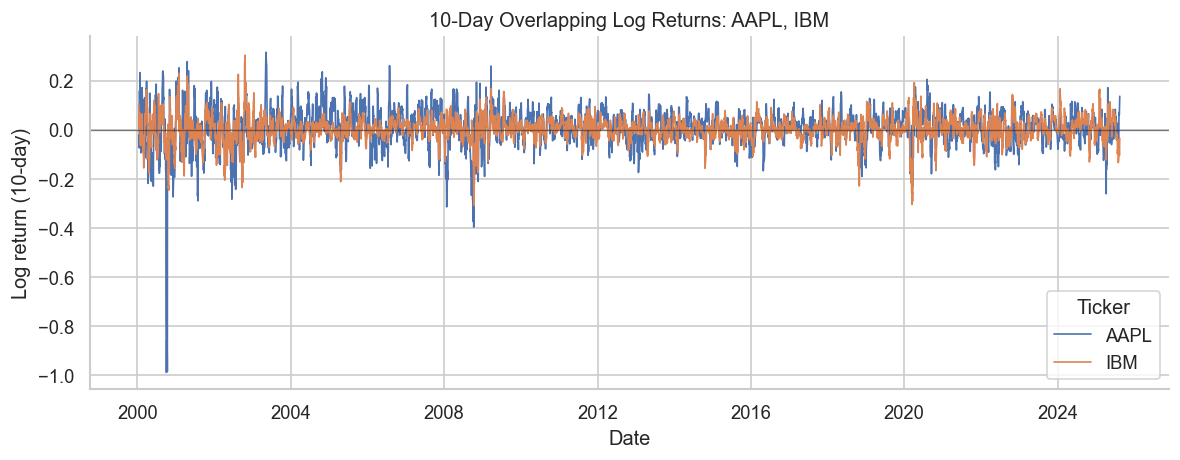

In [8]:
# Plot of log-returns
risk_measures.plot_log_returns()

> ### Mean log-return
> $$\hat{\boldsymbol{\mu}}_t = \dfrac{1}{n} \sum_{k=1}^n \mathbf{X}_{t-k+1}.$$
> **Reference**: University of Technology Sydney. (2025). Market Risk Analysis  [Workshop]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.

In [9]:
mean_log_returns = risk_measures.get_mean_log_returns(display_output=True)

### Mean 10-day log-returns:

#### &emsp; - AAPL: 0.0089

#### &emsp; - IBM: 0.0022

>#### EWMA Estimation of Covariance Matrix
>The following function implements the following explicit form of the recursion
>$$\hat{\boldsymbol{\Sigma}}_t = \theta (\mathbf{X}_t - \hat{\boldsymbol{\mu}}_t) (\mathbf{X}_t - \hat{\boldsymbol{\mu}}_t)^\top + (1 - \theta) \hat{\boldsymbol{\Sigma}}_{t-1}.$$
>Specifically, the function estimates the covariance matrix as
>\begin{align*}
>    \hat{\boldsymbol{\Sigma}}_t
>        & = \theta \sum_{k=1}^n (1 - \theta)^{k-1}\left(\mathbf{X}_{t-k+1} - \hat{\boldsymbol{\mu}}_t\right) \left(\mathbf{X}_{t-k+1} - \hat{\boldsymbol{\mu}}_t\right)^\top \\
>        & = \frac{1}{\sum_{k=1}^n w_k} \sum_{k=1}^n w_k \left(\mathbf{X}_{t-k+1} - \hat{\boldsymbol{\mu}}_t\right) \left(\mathbf{X}_{t-k+1} - \hat{\boldsymbol{\mu}}_t\right)^\top
>\end{align*}
> where $\hat{\boldsymbol{\mu}}_t$ is the sample mean of the time series $\{\mathbf{X}_{t-k+1}\}_{k=1}^n$ and the weights are given by $w_k = (1 - \theta)^{k-1}$, for $k=1,\dots,n$. 
> **Note:** Setting $w_k = \frac{1}{n}$ gives us the standard estimator for the covariance matrix of the returns.
>
> **Reference**: University of Technology Sydney. (2025). Market Risk Analysis  [Workshop]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.

In [10]:
ewma_log_ret_cov = risk_measures.get_covariance_matrix(
    COVARIANCE_METHOD.EWMA, 
    time_period=None,
    smoothing_constant=0.04,
    display_output=True)

### EWMA Covariance Matrix ($\theta=0.04$):

,AAPL,IBM
AAPL,0.0031,-0.0006
IBM,-0.0006,0.0052


### Task 4.1.2
- From the **EWMA covariance matrix** of the 10-day log-returns, extract the **standard deviations** for each stock.  
- Use these standard deviations to calculate the **estimated annualized volatility** for each stock:  
  $$
  \hat{\sigma}_i = \sqrt{\frac{250}{10}} 
  $$  
  where 250 is the assumed number of trading days in a year.  
- **Report** the annualized estimated volatilities $\hat{\sigma}_i$.  

In [11]:
annualised_volatility = risk_measures.get_annualised_volatility(COVARIANCE_METHOD.EWMA, display_output=True)
annualised_volatility_aapl = annualised_volatility[0]
annualised_volatility_ibm = annualised_volatility[1]

### Estimated EWMA annualised volatility of:

#### &emsp; - AAPL: 0.8858

#### &emsp; - IBM: 1.1407

### Task 4.1.3

- Using the given information on the call options, the current stock prices, and the estimated annualized volatilities
- Calculate the (Black-Scholes-Merton) option price, delta $\Delta$, gamma $\Gamma$, and theta $\Theta$. 
- Report $C_i, \Delta_i, \Gamma_i, \Theta_i$ for each option.

In [12]:
eta_aapl = 1
EXPIRY_MONTHS_AAPL = 3

call_aapl = EuropeanOption(
    ticker='AAPL',
    today_date=TODAY, 
    expiry_date=TODAY + relativedelta(months=EXPIRY_MONTHS_AAPL), 
    underlying_price=prices.loc[TODAY, 'AAPL'], 
    strike_price=prices.loc[TODAY, 'AAPL'], 
    volatility=annualised_volatility_aapl, 
    risk_free_rate=RISK_FREE_RATE, 
    dividend_yield=DIVIDENDS, 
    put_call=OptionType.CALL, 
    position_type=PositionType.LONG,
    num_units=eta_aapl,
    z_equity_index=0, 
    verbose=False)

option_price_aapl = call_aapl.get_price()
delta_aapl = call_aapl.get_delta()
gamma_aapl = call_aapl.get_gamma()
theta_aapl = call_aapl.get_theta()
S_aapl = prices.loc[TODAY, 'AAPL']

display(Markdown(f"### {call_aapl.ticker} {call_aapl.put_call.value} option:"))
display(Markdown(f"#### &emsp; - $C_{{AAPL}}$: \${option_price_aapl:.4f}<br /> &emsp; - $\Delta_{{AAPL}}$: {delta_aapl:.4f}<br /> &emsp; - $\\Gamma_{{AAPL}}$: {gamma_aapl:.4f}<br /> &emsp; - $\Theta_{{AAPL}}$: {theta_aapl:.4f}"))


### AAPL call option:

#### &emsp; - $C_{AAPL}$: \$41.5854<br /> &emsp; - $\Delta_{AAPL}$: 0.5957<br /> &emsp; - $\Gamma_{AAPL}$: 0.0038<br /> &emsp; - $\Theta_{AAPL}$: -82.5551

In [13]:
# Assuming purchase date of stock is today

stock_aapl = Stock(
    ticker='AAPL',
    purchase_date=TODAY,
    today_date=TODAY,
    purchase_price=prices.loc[TODAY, 'AAPL'],
    current_price=prices.loc[TODAY, 'AAPL'],
    volatility=annualised_volatility_aapl,
    dividend_yield=DIVIDENDS,
    position_type=PositionType.SHORT,
    num_units=eta_aapl,
    z_equity_index=1,
    verbose=False
)

# stock_aapl

In [14]:
eta_ibm = 1
EXPIRY_MONTHS_IBM = 6

call_ibm = EuropeanOption(
    ticker='IBM',
    today_date=TODAY, 
    expiry_date=TODAY + relativedelta(months=EXPIRY_MONTHS_IBM), 
    underlying_price=prices.loc[TODAY, 'IBM'], 
    strike_price=prices.loc[TODAY, 'IBM'], 
    volatility=annualised_volatility_ibm, 
    risk_free_rate=RISK_FREE_RATE, 
    dividend_yield=DIVIDENDS, 
    put_call=OptionType.CALL, 
    position_type=PositionType.LONG, 
    num_units=eta_ibm,
    z_equity_index=2, 
    verbose=False)

option_price_ibm = call_ibm.get_price()
theta_ibm = call_ibm.get_theta()
delta_ibm = call_ibm.get_delta()
gamma_ibm = call_ibm.get_gamma()
S_ibm = prices.loc[TODAY, 'IBM']

display(Markdown(f"### {call_ibm.ticker} {call_ibm.put_call.value} option:"))
display(Markdown(f"#### &emsp; - $C_{{IBM}}$: \${option_price_ibm:.4f}<br /> &emsp; - $\Delta_{{IBM}}$: {delta_ibm:.4f}<br /> &emsp; - $\\Gamma_{{IBM}}$: {gamma_ibm:.4f}<br /> &emsp; - $\Theta_{{IBM}}$: {theta_ibm:.4f}"))

### IBM call option:

#### &emsp; - $C_{IBM}$: \$76.8173<br /> &emsp; - $\Delta_{IBM}$: 0.6652<br /> &emsp; - $\Gamma_{IBM}$: 0.0019<br /> &emsp; - $\Theta_{IBM}$: -73.0579

In [15]:
# Assuming purchase date of stock is today
stock_ibm = Stock(
    ticker='IBM',
    purchase_date=TODAY,
    today_date=TODAY,
    purchase_price=prices.loc[TODAY, 'IBM'],
    current_price=prices.loc[TODAY, 'IBM'],
    volatility=annualised_volatility_ibm,
    dividend_yield=DIVIDENDS,
    position_type=PositionType.SHORT,
    num_units=eta_ibm,
    z_equity_index=3,
    verbose=False
)
# stock_ibm

In [16]:
portfolio = [
    call_aapl,
    stock_aapl,
    call_ibm,
    stock_ibm
]

portfolio = sorted(portfolio, key=lambda item: item.z_equity_index)
risk_measures.set_portfolio(portfolio)
# portfolio

### Task 4.1.4
- Model the portfolio value $V(t, z_1, z_2)$ as a function of time $t$ in terms of current the risk factors $z_i = Z_{i,t} = \ln S_i$.
- Let $L_{t+1}$ denote the loss on the portfolio over the risk management time horizon $[t,t + \Delta t]$
$$
  L_{t+1} := - \big( V_{t+1} - V_t \big)
  = -\Big[ V(t+\Delta t, Z_{1,t+1}, Z_{2,t+1}) - V(t, Z_{1,t}, Z_{2,t}) \Big].
$$

- Derive the **delta–gamma approximation** to the loss:
    - Include **first-order sensitivities** with respect to $t$:
        - $\frac{\partial V}{\partial t} \Delta t$
        - $\Delta t = \frac{10}{250}$ - 10-day horizon
    - In terms of:
        - $z_1 = Z_{1,t} = \ln S_1(t)$ - AAPL log price at time $t$
        - $z_2 = Z_{t,2} = \ln S_2(t)$ - IBM log price at time $t$
        - $X_{1,t+1} = Z_{1, t+1} - Z_{1,t}$ - AAPL log return at time $t$
        - $X_{2,t+1} = Z_{2, t+1} - Z_{2,t}$ - IBM log return at time $t$
        - $\eta_1$ - units of AAPL stock (short position)
        - $\eta_2$ - units of IBM stock (short position)
        - the option prices,
        - and the option greeks
- Express the loss approximation as  
$$
L^{\Delta,\Gamma}_{t+1} := -c_t - \mathbf{b}_t^\top \mathbf{X}_{t+1} - \frac{1}{2} \mathbf{X}_{t+1}^\top \mathbf{B}_t \mathbf{X}_{t+1},
$$

  where:
  - $c_t =$ constant term involving option prices and thetas  
  - $\mathbf{b}_t =$ vector of exposures involving deltas and stock holdings ($\eta_1, \eta_2$)  
  - $\mathbf{B}_t = H_z V = $ Hessian w.r.t $z = $  matrix of quadratic exposures involving gammas  
  - $\mathbf{X}_{t+1} = (X_{1,t+1}, X_{2,t+1})^\top =$ vector of log-returns



---
Portfolio value:
$$
V = \underbrace{C_1(S_1, t)}_{call_{AAPL}} - \underbrace{\eta_1 S_1}_{short_{AAPL}} + \underbrace{C_2(S_2,t)}_{call_{IBM}} - \underbrace{\eta_2 S_2}_{short_{IBM}}
\qquad S_i=e^{z_i}.
$$

---
Useful identities for $S_i=e^{z_i}$

$$
z_i = \ln S_i \quad \Longleftrightarrow \quad S_i = e^{z_i}.
$$
$$
\frac{\partial S_i}{\partial z_i}=e^{z_i}=S_i,
\qquad
\frac{\partial^2 S_i}{\partial z_i^2}=e^{z_i}=S_i.
$$

---
**First derivative** $\;\dfrac{\partial V}{\partial z_i}$

- **Time sensitivity (theta).**  
  - Stocks have zero theta under constant $r,q$. (no dividend and no discounting)
  - Options contribute $\Theta_i= \dfrac{\partial C_i}{\partial t}$:
$$
  \frac{\partial V}{\partial t} = \Theta_1 + \Theta_2.
$$

- **Split $V$ into components depending on $S_i$**  
    - Option on asset $i$: $C_i(S_i,t)$
        - By the chain rule
        $$
        \frac{\partial}{\partial z_i} C_i (S_i, t) = \frac{\partial C_i}{\partial S_i} \frac{\partial S_i}{\partial z_i} = \Delta_i S_i
        $$

    - Stock short position on asset $i$: $-\eta_i S_i$
        $$
        \frac{\partial}{\partial z_i} (-\eta_i S_i) = -\eta_i \frac{\partial S_i}{\partial z_i} = -\eta_i S_i
        $$
    
    - Sum
        - Since $C_1$ depends only on $S_1$ and $C_2$ only on $S_2$, cross-effects do not appear on $\dfrac{\partial}{\partial z_i}$. Therefore,
        $$
        \boxed{\;
        \frac{\partial V}{\partial z_i} = \Delta_i S_i = S_i(\Delta_i - \eta_i)
        \;}
        $$

---
**Second derivative** $\;\dfrac{\partial^2 V}{\partial z_i^2}$  
    
- Option terms. 

    - Starting from $\dfrac{\partial}{\partial z_{i}^{2}} C_i(S_i,t) = \Delta_i S_i$ and applying the product rule:
        $$
        \frac{\partial^2}{\partial_{z_i}^{2}} C_i(S_i,t) = \frac{\partial}{\partial z_i}(\Delta_i S_i) = \frac{\partial \Delta_i}{\partial z_i} S_i + \Delta_i \frac{\partial S_i}{\partial z_i}
        $$
        - By the chain rule:
        $$
        \frac{\partial \Delta_i}{\partial z_i} = \frac{\partial \Delta_i}{\partial S_i} \frac{\partial S_i}{\partial z_i} = \Gamma_i S_i
        $$
        - Where $\Gamma_i := \dfrac{\partial^2 C_i}{\partial S_{i}^{2}}$ is the option gamma
    - So,
    $$
    \frac{\partial^2}{\partial z_{i}^{2}} C_i(S_i,t) = (\Gamma_i S_i) S_i + \Delta_i S_i = \Gamma_i S_{i}^{2} + \Delta_i S_i
    $$

- Stock terms

    - Starting from $\dfrac{\partial}{\partial z_i} (-\eta_i S_i) = -\eta_i S_i$ and differentiating again:
    $$
    \frac{\partial^2}{\partial z_{z_i}^{2}} (-\eta_i S_i) = - \eta_i \dfrac{\partial S_i}{\partial z_i} = -\eta_i S_i
    $$

- Sum
$$
\boxed{\;
\frac{\partial^2 V}{\partial z_{i}^{2}} = (\Gamma_i S_{i}^{2} + \Delta_i S_i) - \eta_i S_i = \Gamma_i S_{i}^{2} + S_i (\Delta_i - \eta_i)
\;}
$$

---
- Cross partials
    - Because $C_1$ depends only on $S_1$ and $C_2$ only on $S_2$ and $S_1 = e^{z_1}$, $S_2 = e^{z_2}$ are independent functions of $z_1, z_2$:
    $$
    \frac{\partial^2 V}{\partial z_1 \partial z_2} = \dfrac{\partial^2}{\partial z_1 \partial z_2} (C_1 (S_1, t) - \eta_1 S_1 + C_2 (S_2, t) - \eta_2 S_2) = 0
    $$

---
Therefore:
$$
L_{t+1}^{\Delta \Gamma} = -(\Theta_1 + \Theta_2) \Delta t 
- \begin{bmatrix} \mathbf{X}_{1, t+1} & \mathbf{X}_{2, t+1} \end{bmatrix}
\begin{bmatrix} S_1(\Delta_1 - \eta_1) \\ S_2(\Delta_2 - \eta_2) \end{bmatrix}
- \frac{1}{2}
\begin{bmatrix} \mathbf{X}_{1, t+1} & \mathbf{X}_{2, t+1} \end{bmatrix}
\begin{bmatrix} \Gamma_1 S_1^2 + S_1(\Delta_1 - \eta_1) && 0 \\ 0 && \Gamma_2 S_2^2 + S_2(\Delta_2 - \eta_2) \end{bmatrix}
\begin{bmatrix} \mathbf{X}_{1, t+1} \\ \mathbf{X}_{2, t+1} \end{bmatrix}
$$

>Assistance from *ChatGPT (OpenAI, 2025)* was used to support explanation and presentation of the risk-minimization process.
>The tool was employed to:
>- Clarify theoretical concepts related to the delta–gamma loss approximation and analytical VaR/ES derivations.  
>- Summarize, format, and explain relevant mathematical expressions for inclusion in the notebook.  
>
>All outputs from ChatGPT were critically reviewed, verified, and edited by the author to ensure accuracy, correctness, and alignment with academic standards.

### Task 4.1.5
- Using the current risk factor values, calculate and report the value of $c_t$, $\mathbf{b}_t$ and $\mathbf{B}_t$.

In [17]:
c_t = (theta_aapl + theta_ibm) * DELTA_T
b_t = np.array([S_aapl * (delta_aapl - eta_aapl), S_ibm * (delta_ibm - eta_ibm)])
B_t = np.diag([gamma_aapl * S_aapl**2 + S_aapl * (delta_aapl - eta_aapl), gamma_ibm * S_ibm**2 + S_ibm * (delta_ibm - eta_ibm)])

display(Markdown(f"#### Assumung $\eta_1 = {call_aapl.eta}$ and $\eta_2 = {call_ibm.eta}$"))

display(Markdown(f"#### $c_t$ = {c_t:.4f}"))

b_t_display = spy.Matrix(np.round(np.array(b_t, dtype=float), 4)) 
display(Math(fr"\mathbf{{b}}_t = {spy.latex(b_t_display)}"))

B_t_display = spy.Matrix(np.round(np.array(B_t, dtype=float), 4)) 
display(Math(fr"\mathbf{{B}}_t = {spy.latex(B_t_display)}"))

#### Assumung $\eta_1 = 1$ and $\eta_2 = 1$

#### $c_t$ = -6.2245

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Task 4.2 Market Risk Modelling

### 4.2.1 Analytical Approach 

- Using the delta loss approximation

    $$
    L^{\Delta}_{t+1} = -c_t - \mathbf{b}_t^\top \mathbf{X}_{t+1},
    $$
    - and assume

    $$
    X_{t+1} \sim \mathcal{N}_2(\mathbf{\hat{\mu}}_t, \mathbf{\hat{\Sigma}}_t),
    $$

    - where $\mathbf{\hat{\mu}}_t$ is the mean vector and $\mathbf{\hat{\Sigma}}_t$ is the covariance matrix of the 10-day log-returns estimated in **Task 1, Section 4.1**.

> #### Analytical (Variance-Covariance) Method
> Suppose $L_{j,t+1}$ is modelled using the delta approximations constructed above. Given financial data up to time $t$, we assume that $\mathbf{X}_{t+1} \sim N_4(\boldsymbol{\mu}_{t+1}, \boldsymbol{\Sigma}_{t+1})$, where $\boldsymbol{\mu}_{t+1}$ and $\boldsymbol{\Sigma}_{t+1}$ can be estimated using information up to time $t$. We estimate $\boldsymbol{\mu}_{t+1}$ by the sample mean of the historical log-return time series $\{\mathbf{X}_{t-k+1}\}_{k=1}^n$,
> $$\hat{\boldsymbol{\mu}}_{t+1} = \hat{\boldsymbol{\mu}}_t = \frac{1}{n} \sum_{k=1}^n \mathbf{X}_{t-k+1}.$$
>
> **Reference**: University of Technology Sydney. (2025). Market Risk Analysis  [Workshop]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.

#### Task 4.2.1.1 
- Calculate and report the 10-day 99% $VaR$ and $ES$ of the portfolio using the analytical approach.

In [18]:
VaR_analytical = risk_measures.VaR_ES_variance_covariance(
    constant_loss=c_t, 
    first_order_risk_exposure=b_t, 
    mean_loss=None, 
    covariance_loss=ewma_log_ret_cov.to_numpy(), 
    confidence_level=ALPHA,
    display_output=True)



### Analytical 10-day 99.0% Risk Measures:

#### &emsp; - VaR: 24.0993<br /> &emsp; - ES: 26.5560

#### Task 4.2.1.2 
- State the interpretation of the figures you calculated in the previous task.


#### Interpretation of the 10-Day VaR and ES (Analytical Approach)

- **Value-at-Risk (VaR)** at the 99% confidence level tells us:  
  - Over the next 10 trading days, under the assumptions of the model, there is only a 1% probability that the portfolio loss will exceed the reported VaR value.* 
  - In other words, VaR is a **quantile of the loss distribution** — it marks the loss threshold that is exceeded only in the worst 1% of cases.

- **Expected Shortfall (ES)** (also called Conditional VaR) at 99% gives us:  
  - If we do end up in that worst 1% of scenarios, the ES represents the **average loss** we should expect to suffer. Thus, ES captures the **tail severity** beyond the VaR threshold.

- **Interpretation in context:**  
  - Both measures are based on the **delta approximation** of portfolio losses, assuming that 10-day log-returns follow a **bivariate normal distribution** with mean $\hat{\mu}_t$ and covariance $\hat{\Sigma}_t$ estimated from historical data.  
  - VaR provides a single cutoff level, but ignores the size of losses beyond that level.  
  - ES corrects this by quantifying the *expected magnitude* of extreme losses.  


### 4.2.2 Historical Simulation
- The time series data set of historical 10-day log-returns serve as the collection of possible scenarios for the random 10-day log-return over the risk management time horizon. 
- When the age-weighted historical simulation approach is to be used, assume an age decay parameter $\theta = 0.94$.

#### Task 4.2.2.1
- Using the standard historical simulation approach and the delta-gamma loss approximation 
- Calculate and report the 10-day $99$% $VaR$ and $ES$ of the portfolio.
- Compare your results to those obtained using the standard historical simulation and the full valuation approach. 
- Explain why the results may differ.

> #### Historical Simulation Approach
> The historical simulation approach involves estimating the distribution of $L_{t+1} $ under the empirical distribution of historical risk factor changes $\{ X_{t-j+1} \}_{j=1}^n.$
> 
> **Reference**: University of Technology Sydney. (2025). 4 Market Risk Modelling [Lecture Slides]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.


#### Delta-Gamma Loss Approximation

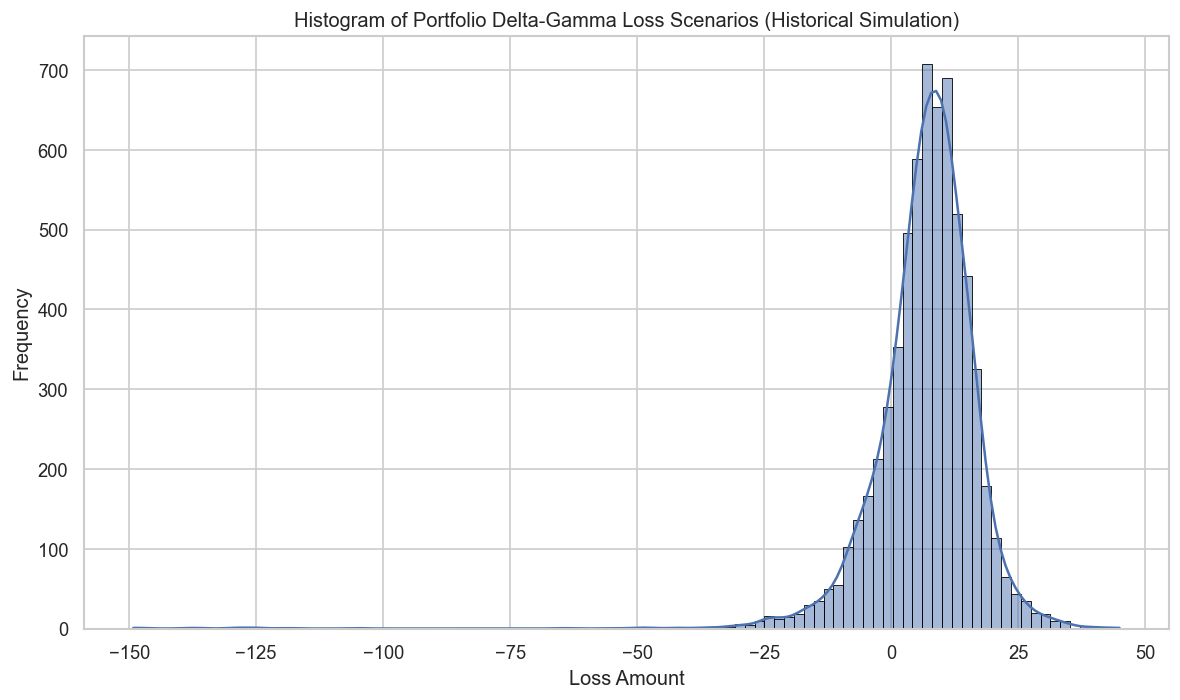

### Delta-Gamma (Standard Historical Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 27.2914<br /> &emsp; - ES: 31.7479

In [19]:
delta_gamma_loss_historical_simulation_risk_measures = risk_measures.delta_gamma_loss_historical_simulation(
    constant_loss=c_t,
    first_order_risk_exposure=b_t,
    second_order_risk_exposure=B_t,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True)


In [20]:
# delta_gamma_loss_historical_simulation_risk_measures.display_backtest_results()

#### Full Valuation Loss Approximation

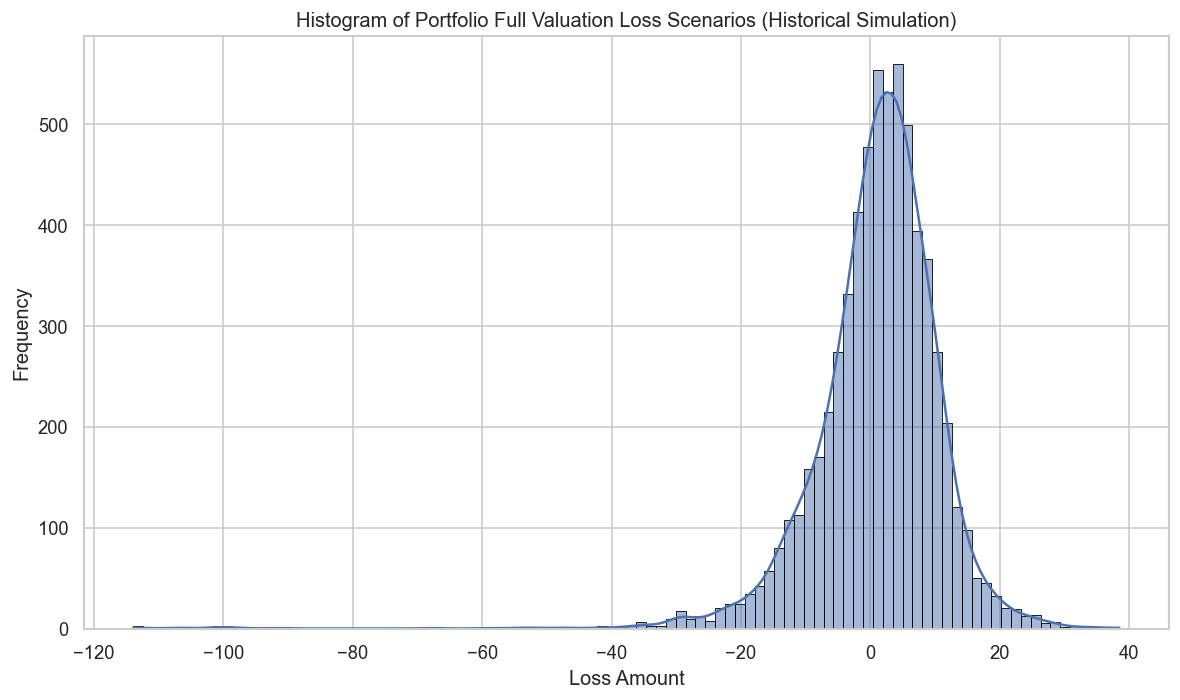

### Full Valuation (Standard Historical Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 21.3117<br /> &emsp; - ES: 25.6960

In [21]:
full_valuation_loss_historical_simulation_risk_measures = risk_measures.full_valuation_loss_historical_simulation(
    today_date=TODAY, 
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.01,
    plot=True,
    display_output=True)


In [22]:
# full_valuation_loss_historical_simulation_risk_measures.display_backtest_results()

#### Interpreting the Difference

Both methods hold the Greeks constant, but the delta–gamma method linearises and quadratises the loss function, while the full revaluation uses the exact Black–Scholes mapping.  

Because the quadratic term in the $\Delta \Gamma$ expansion exaggerates curvature for large empirical shocks, the $\Delta \Gamma$ method yields higher $VaR_{0.99}$ and $ES_{0.99}$.

The delta–gamma approximation is only locally accurate and may overstate risk when applied to large, nonlinear price moves. Hence, the full revaluation is considered **more reliable** for non-linear portfolios, while the delta–gamma method remains **computationally faster but conservative**.

**Note:** The historical simulation framework assumes that risk-factor changes are i.i.d. (slides 46–48, *Market Risk Modelling*).   Because the dataset uses **overlapping 10-day log-returns**, each observation introduces **serial correlation** into the risk-factor changes.

This dependence reduces the effective sample size and can bias the empirical loss distribution:

- Large shocks may be **counted multiple times**, amplifying tail estimates.  
- The resulting VaR and ES may therefore be **less stable and slightly overstated**.  
- This effect interacts with the $\Delta \Gamma$ approximation, which already magnifies large moves, further explaining why the $\Delta \Gamma$-based risk measures exceed the full-revaluation results.

Thus, overlapping 10-day returns increase sample efficiency but introduce serial correlation.

#### Task 4.2.2.2
- Conduct the same analysis in the previous task but using the age-weighted historical simulation approach. 
- Report the risk measures obtained and compare the results obtained using the loss approximation and the full valuation approach.


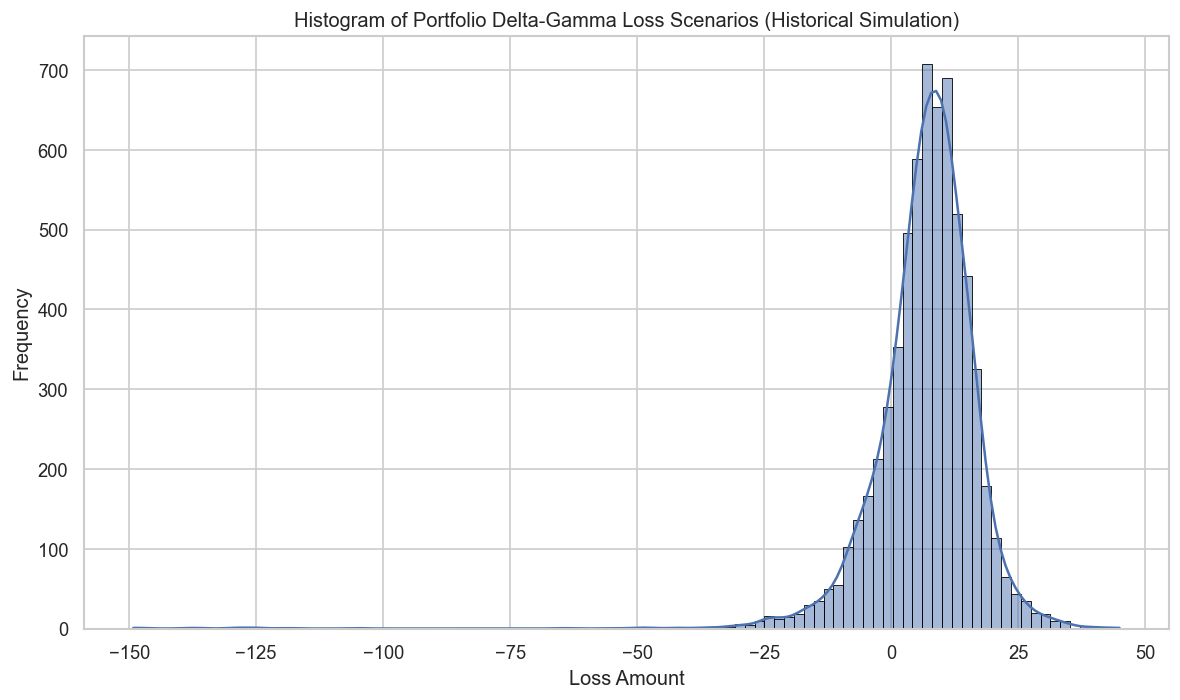

### Delta-Gamma (Age weighted $\theta=0.94$ Historical Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 16.0397<br /> &emsp; - ES: 16.9981

In [23]:
delta_gamma_loss_historical_simulation_risk_measures_ewma = risk_measures.delta_gamma_loss_historical_simulation(
    constant_loss=c_t,
    first_order_risk_exposure=b_t,
    second_order_risk_exposure=B_t,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.AGE_WEIGHT_DECAY,
    age_weight_decay=0.94,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True)


In [24]:
# delta_gamma_loss_historical_simulation_risk_measures_ewma.display_backtest_results()

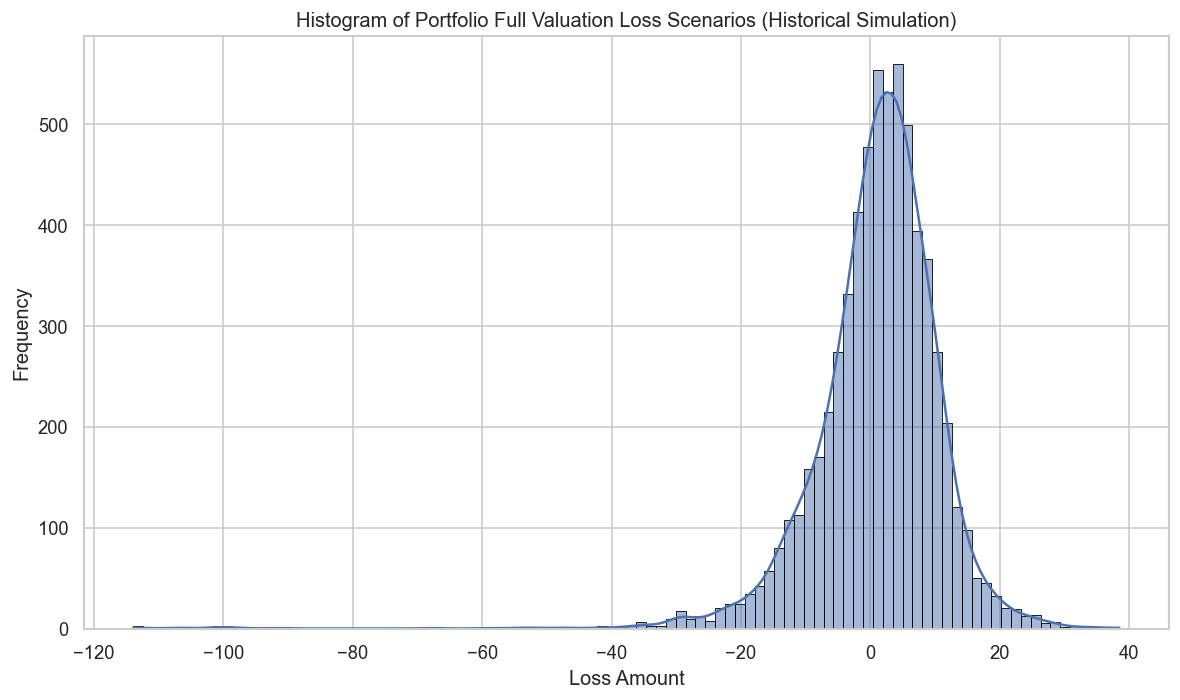

### Full Valuation (Age weighted $\lambda=0.94$ Historical Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 10.2335<br /> &emsp; - ES: 11.1885

In [25]:
full_valuation_loss_historical_simulation_risk_measures = risk_measures.full_valuation_loss_historical_simulation(
    today_date=TODAY,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.AGE_WEIGHT_DECAY,
    age_weight_decay=0.94,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True)


In [26]:
# full_valuation_loss_historical_simulation_risk_measures.display_backtest_results()

#### Interpretation — Age-Weighted Historical Simulation

According to the *Market Risk Modelling* lecture slides (pp. 54–56), the **Age-Weighted Historical Simulation (AWHS)** method modifies the standard Historical Simulation by assigning exponentially decaying weights to past observations:

$$
w_j = \frac{(1 - \lambda)\lambda^{j-1}}{1 - \lambda^n}, \quad 0 < \lambda < 1
$$

- Both **VaR** and **ES** have **decreased** substantially compared to the standard Historical Simulation results.
- This is expected, since **$\lambda = 0.94$** assigns greater weight to **recent market conditions**, which have been relatively **calmer** than past stress periods.  As a result, the tail of the weighted empirical loss distribution is thinner.

Even under age-weighting:
- The **$\Delta \Gamma$ (Delta–Gamma) approach** still produces **higher** tail risk measures than the **Full Revaluation** method.
- The **Full Revaluation** method re-prices each path using the exact Black–Scholes formula, preserving the nonlinear (but bounded) option payoff shape.

Hence:
- $\Delta \Gamma$ remains a **conservative approximation**, exaggerating losses for larger historical shocks.  
- Full revaluation provides a **more realistic risk estimate**, but at a higher computational cost.


#### Task 4.2.2.3 
- Compare and discuss the risk measures obtained through the standard and age-weighted historical simulation approaches.

---

| Method | VaR (99%) | ES (99%) |
|:-------------------------------------|-----------:|-----------:|
| HS + $\Delta \Gamma$ (Standard) | 27.2914 | 31.7479 |
| HS + Full Revaluation (Standard) | 21.3117 | 25.6960 |
| HS + $\Delta \Gamma$ (Age-weighted, $\lambda = 0.94$) | 16.0397 | 16.9981 |
| HS + Full Revaluation (Age-weighted, $\lambda = 0.94$) | 10.2335 | 11.1885 |


##### Overview of the two approaches

According to the *Market Risk Modelling* lecture slides (pp. 46–56):

- **Standard Historical Simulation (HS)** assigns **equal weight** to all historical observations:
  $$
  w_j = \frac{1}{n}.
  $$
  This assumes that all past market conditions are equally relevant to the present risk environment.

- **Age-Weighted Historical Simulation** uses an **exponential decay factor** $\lambda$ to give **greater weight to recent data**:
  $$
  w_j = \frac{(1 - \lambda)\lambda^{j-1}}{1 - \lambda^n}.
  $$
  This approach captures **time-varying volatility** and makes the risk estimate more **responsive** to current market conditions.

---

##### Observed differences in results

1. **Magnitude of risk measures:**
   - Both VaR and ES are **significantly lower** under Age-Weighted Historical Simulation compared to Standard Historical Simulation.  
   - This reflects that the **recent market period (higher weights)** likely exhibited **lower volatility** than earlier stress periods (e.g., GFC or COVID-19).

2. **Direction of change is consistent across methods:**
   - The reduction in both $\Delta \Gamma$ and Full Revaluation results indicates that the weighting procedure **systematically downweighted older high-volatility observations** when recent volatility is low.

3. **Relative ranking of $\Delta \Gamma$ vs Full Revaluation remains unchanged:**
   - In both Standard and Age-Weighted Historical Simulation, $\Delta \Gamma$ yields **larger** VaR and ES values than Full Revaluation.  
   - This is due to the **quadratic approximation** overestimating losses for large price moves.

---

##### Interpretation and implications

- **Standard Historical Simulation** provides a more stable long-term risk estimate but may **overstate current risk** if older stress periods dominate the tail of the historical distribution.
- **Age-Weighted Historical Simulation** adapts the model to **recent volatility conditions**, producing more **responsive but lower** risk measures when markets are calm.
- However, if market volatility rises suddenly, the age-weighted approach will **react faster**, increasing VaR and ES accordingly.
- Thus, Age-Weighted Historical Simulation improves **timeliness** at the cost of **stability**, while Standard Historical Simulation provides **consistency** but may lag in adapting to changing regimes.

---

##### Summary

- The Age-Weighted Historical Simulation approach produces smaller VaR and ES values compared to the standard Historical Simulation because it assigns more weight to recent, lower-volatility periods.  
- This results in a thinner empirical tail and more responsive, forward-looking risk estimates.  
- Despite the weighting, the Delta–Gamma approximation continues to yield higher tail losses than the Full Revaluation approach due to its inherent curvature bias.  


### 4.2.3 Monte Carlo Simulation Approach

In this approach, we consider two models for the distribution of the risk factor change $X_{t+1}$:

- **Bivariate Gaussian distribution**  
  $$
  X_{t+1} \sim \mathcal{N}_2(\hat{\mu}_t, \hat{\Sigma}_t)
  $$
  (same assumption as in the analytical approach).

- **Student’s t copula with Gaussian marginals**  
  - Each marginal $X_{i,t+1}$ follows a Gaussian distribution (as implied by the lognormality assumption of underlying asset prices in the Black–Scholes model).  
  - The marginal means and standard deviations of $X_{i,t+1}$ are given by the corresponding entries in $\hat{\mu}_t$ and $\hat{\Sigma}_t$ estimated in Task 1, Section 4.1.  
  - The joint dependence structure is modelled using a **bivariate Student’s t copula**.

In this section, we fit a Student’s t copula to the log-returns and then calculate the required risk measures using Monte Carlo simulation.

#### Task 4.2.3.1
- Construct pseudo-observations using the empirical cumulative distribution function of the log-returns (i.e. using ranks). 
- Using maximum likelihood estimation (MLE), estimate the parameters (the degrees of freedom $\nu > 0$ and the parameter $\rho \in (−1,1)$ of the scale matrix) of the bivariate Student’s t copula. 

> **You must write a code defining the (negative) log-likelihood function manually and perform the minimization step using scipy.optimize.minimize.** 

- Report your parameter estimates.

> #### Proposition 1.8
> Suppose that the joint df F is absolutely continuous and has strictly increasing, continuous marginal dfs $F_1,...,> F_d$. 
> The copula given by the equation:
> $$\mathbb{C}(u_1,...,u_d) = F^{-1}_1(u_1),...,F^{-1}_{d}(u_d)$$
> has a density function
> $$ \mathbb{c}(u_1,...,u_d) = \dfrac{\mathbb{f}( F^{-1}_1(u_1),...,F^{-1}_{d}(u_d) )}{\mathbb{f}_1(F^{-1}_1(u_1))... {\mathbb{f}_{d}}(F^{-1}_{d}(u_d))} 
> $$
>
> **Reference**: University of Technology Sydney. (2025). 3B Copulas and Dependence [Lecture Slides]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.

In [27]:
risk_measures.fit_student_t_copula(
    pseudo_observations_method=PSEUDO_OBSERVATIONS_METHOD.EMPIRICAL,
    display_output=True
)

### Student's t Copula Parameters:

#### &emsp; - Using Empirical Cumulative Distribution Function of Log Returns

#### &emsp; - $\nu$: 7.8918<br /> &emsp; - $\rho$: 0.3477

#### Task 4.2.3.2

- Using the `pycop` library, calculate the coefficients of **upper** and **lower tail dependence** of the log-returns. Use cutoffs at $0.99$ (upper) and $0.01$ (lower).
- Estimate $(\nu,\rho)$ of the $t$ copula via MLE.
- Use Proposition 4.17 to calculate the implied $\lambda_U$ and $\lambda_L$.
- Construct a scatter plot of pseudo-observations $\{(U_{1,t},U_{2,t})\}$.
- Compare empirical vs theoretical coefficients and discuss whether the dependence structure in the extremes of the historical data is consistent with the $t$ copula.

---

> ##### Proposition 4.17 (Tail Dependence of the Student's $t$ Copula)
> 
> Suppose $X_1$ and $X_2$ have continuous marginal dfs which admit a unique copula $\mathbb{C}$.
> - If $\mathbb{C}$ is the bivariate Gaussian copula $\mathbb{C}^{Ga}_{\rho}$ for some $\rho \in [−1,1)$, then $\lambda = 0$. That is, $X_1$ and $X_2$ are asymptotically independent in both the upper and lower tails.
> - If $\mathbb{C}$ is the bivariate Student’s t copula $\mathbb{C}^{t}_{\nu, \rho}$ for some $\rho \in (−1,1]$, 
> then 
> $$ \lambda_U = \lambda_L =  2t_{ν+1} \Big( - \sqrt{\frac{(\nu + 1)(1 - \rho)}{1 + \rho} } \Big)$$
>   - where $t_{\nu}$ is the density of a univariate t distribution with $\nu$ degrees of freedom. 
>   - Thus, if $\rho > −1$, $X_1$ and $X_2$ are asymptotically dependent in both the upper and lower tails.
>
> **Reference** University of Technology Sydney (UTS). (2025). 4 Market Risk Modelling [Lecture slides]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.


In [28]:
# Empirical copula 
em_cop = pycop.empirical(risk_measures.log_returns.T.values)

display(Markdown(f"### Non-parametric tail dependence coefficient estimates:"))
display(Markdown(f"#### &emsp; - Coefficient of lower tail dependence: {em_cop.LTDC(0.01):.4f}"))
display(Markdown(f"#### &emsp; - Coefficient of upper tail dependence: {em_cop.UTDC(0.99):.4f}"))


### Non-parametric tail dependence coefficient estimates:

#### &emsp; - Coefficient of lower tail dependence: 0.1399

#### &emsp; - Coefficient of upper tail dependence: 0.1663

In [29]:
nu = risk_measures.student_t_copula_nu
rho = risk_measures.student_t_copula_rho

lm = 2 * stats.t.cdf(-np.sqrt((nu + 1) * (1 - rho) / (1 + rho)), df = nu + 1)

display(Markdown(f"### Coefficient of upper and lower tail dependence implied by the bivariate t copula:"))
display(Markdown(f"#### &emsp; - $\\lambda_{{U}} = \\lambda_{{U}} = {lm:.4f} $"))


### Coefficient of upper and lower tail dependence implied by the bivariate t copula:

#### &emsp; - $\lambda_{U} = \lambda_{U} = 0.0683 $

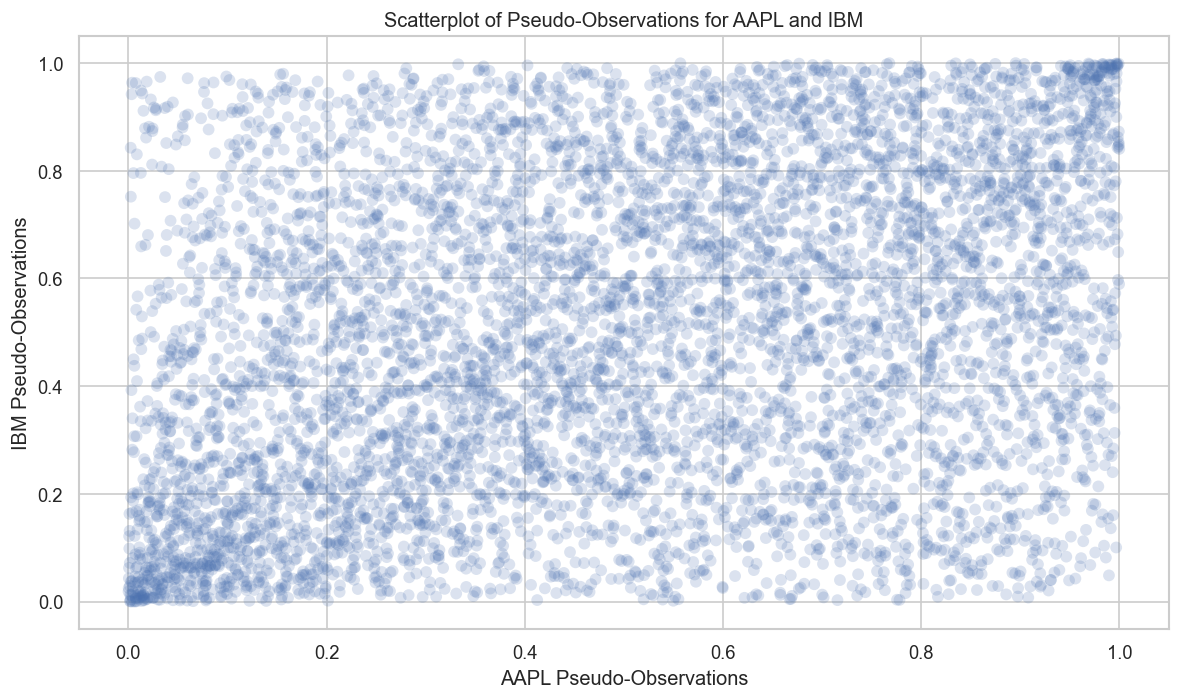

In [30]:
# Plot pseudo observations
plt.figure(figsize=(10, 6))
sns.scatterplot(x=risk_measures.pseudo_observations_df.columns[0], 
                y=risk_measures.pseudo_observations_df.columns[1], 
                data=risk_measures.pseudo_observations_df, 
                alpha=0.2, 
                edgecolor='none', 
                s=50)

plt.title(f'Scatterplot of Pseudo-Observations for {risk_measures.pseudo_observations_df.columns[0]} and {risk_measures.pseudo_observations_df.columns[1]}')
plt.xlabel(f'{risk_measures.pseudo_observations_df.columns[0]} Pseudo-Observations')
plt.ylabel(f'{risk_measures.pseudo_observations_df.columns[1]} Pseudo-Observations')
plt.tight_layout()
plt.show()


#### Tail Dependence Analysis for AAPL and IBM Log-Returns

#####  Empirical tail dependence vs Student's t copula

| Source | Lower-Tail $\lambda_{L}$ | Upper-Tail $\lambda_{U}$ | Comments |
|:--------|:------------------:|:------------------:|:-----------|
| Empirical (from data) | 0.1399 | 0.1663 | Moderate and roughly symmetric; slightly stronger in upper tail. |
| Student's t copula (Proposition 4.17) | 0.0683 | 0.0683 | Weaker and symmetric by construction. |


##### Comparison

| Aspect | Empirical Data | t-Copula Model | Discussion |
|:-------|:---------------|:---------------|:------------|
| **Tail intensity** | 0.14–0.17 | 0.068 | The Student's t copula **underestimates** empirical joint extremes — real data show roughly **double** the tail co-movement. |
| **Symmetry** | Slight asymmetry (upper > lower) | Perfect symmetry | Real returns display **mild asymmetry**, common in equity data however the Student's t copula model assumes symmetry. |
| **Visual evidence** | Weak diagonal clustering with corner thickening | Expected under small $\lambda$ | Qualitatively consistent but **quantitatively weaker** in the fitted model. |

##### Summary

- The empirical tail dependence coefficients ($\lambda_L=0.14$, $\lambda_U=0.17$) indicate moderate symmetric dependence between AAPL and IBM in both tails, consistent with weak clustering of joint extremes seen in the pseudo-observation scatter.  
- The Student’s t-copula implied dependence ($\lambda=0.0683$) captures the qualitative presence of tail dependence but **underestimates its magnitude**, suggesting that the fitted copula’s degrees of freedom or correlation parameter may be too small to match the observed joint tail behaviour.




#### Task 4.2.3.3 

##### Monte Carlo VaR/ES with the Student’s t Copula

- **Steps:**
    1. Simulate 10,000 draws from the **bivariate Student’s t copula**.  
    2. Transform the simulated copula draws into **log-returns** using the marginal Gaussian distributions of the risk factors.  
    3. Apply the **delta–gamma loss approximation** to the simulated log-returns to generate simulated portfolio losses.  
    4. From the empirical distribution of simulated losses, calculate and report the **10-day 99% VaR and ES**.  
    5. Revalue the portfolio under each simulated scenario using a **full valuation approach**.  
    6. Report the corresponding 10-day 99% VaR and ES from these full revaluations.  

In [31]:
risk_measures.set_student_t_copula_simulation_log_returns(N_simulations=N_SIMULATIONS, plot=False)

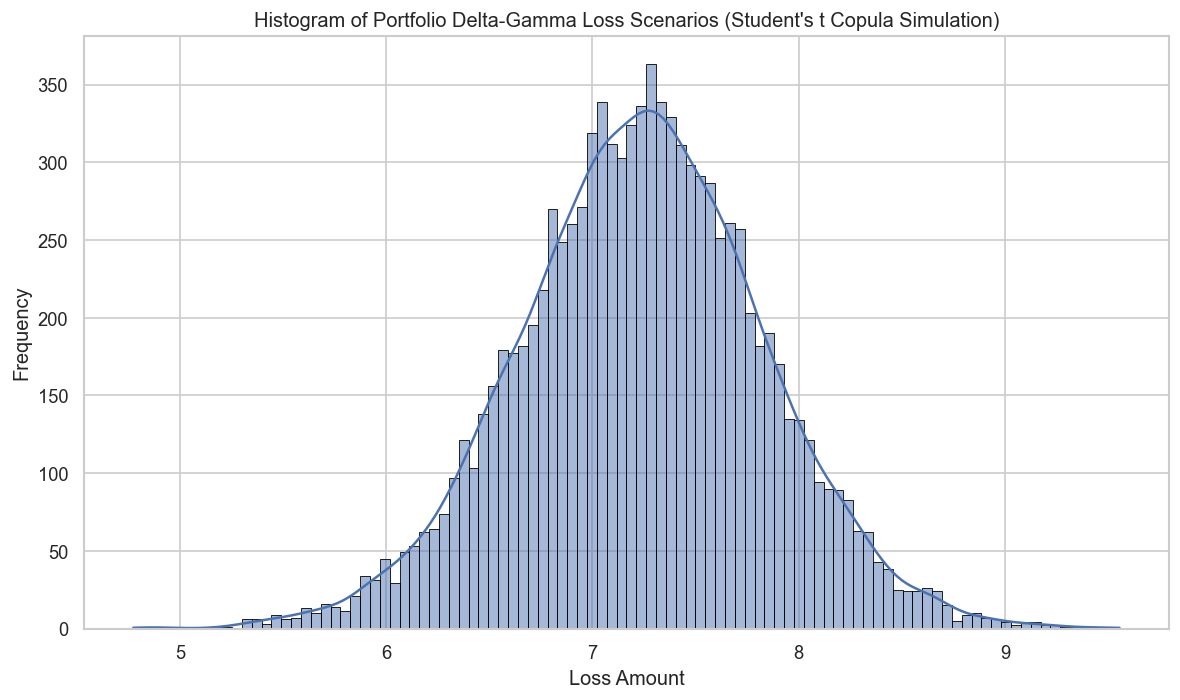

### Delta-Gamma (Standard Student's t Copula Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 8.6435<br /> &emsp; - ES: 8.8623

In [32]:
delta_gamma_loss_student_t_copula_risk_measures = risk_measures.delta_gamma_loss_student_t_copula_simulation(
    constant_loss=c_t,
    first_order_risk_exposure=b_t,
    second_order_risk_exposure=B_t,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    age_weight_decay=0.94,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True)


In [33]:
# delta_gamma_loss_student_t_copula_risk_measures.display_backtest_results()

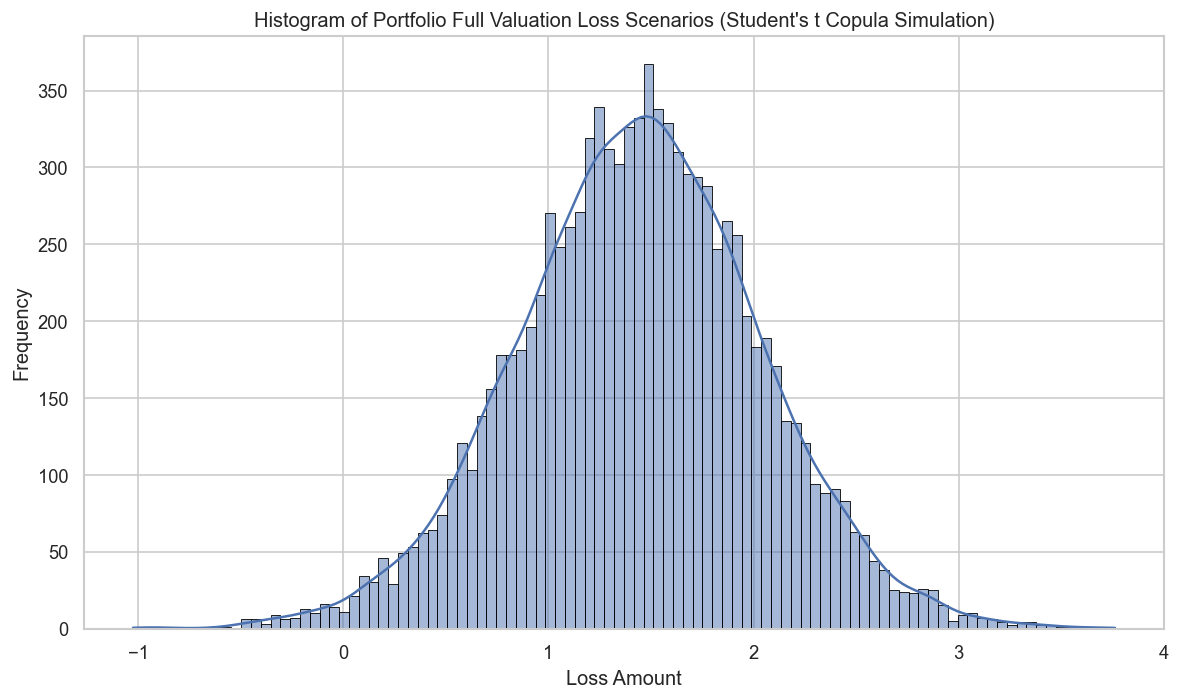

### Full Valuation (Standard Student's t Copula Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 2.8488<br /> &emsp; - ES: 3.0678

In [34]:
full_valuation_loss_student_t_copula_simulation_risk_measures = risk_measures.full_valuation_loss_student_t_copula_simulation(
    today_date=TODAY,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    age_weight_decay=None,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True
)


In [35]:
# full_valuation_loss_student_t_copula_simulation_risk_measures.display_backtest_results()

##### Interpretation

- The **$\Delta \Gamma$ approximation** produces substantially higher tail risk measures than the **Full Revaluation** approach.
- Both results are lower than those obtained under Historical Simulation (Section 4.2.2), consistent with the **t-copula’s thinner empirical tails** and the smoother Monte Carlo sampling of simulated returns.
- The difference between $\Delta \Gamma$ and Full Revaluation again arises from the **quadratic approximation**:  
  - $\Delta \Gamma$ assumes a constant curvature ($\Gamma$) and thus **overstates non-linear losses** for large simulated shocks.  
  - Full Revaluation recomputes option values via the Black–Scholes formula, which yields a **bounded nonlinear payoff**—reducing extreme simulated losses.


#### Task 4.2.3.4. 

##### Monte Carlo VaR/ES with the Bivariate Gaussian Distribution

- **Repeat the previous task**, but now assume the 10-day log-returns  
  $$
  X_{t+1} \sim \mathcal{N}_2(\hat{\mu}_t, \hat{\Sigma}_t),
  $$  
  where $\hat{\mu}_t$ and $\hat{\Sigma}_t$ are the estimated mean vector and covariance matrix from **Task 1 (Section 4.1)**.

- **Steps:**
  1. Simulate 10,000 draws from the **bivariate Gaussian distribution** of the log-returns.  
  2. Apply the **delta–gamma loss approximation** to the simulated log-returns to generate simulated portfolio losses.  
  3. From the empirical distribution of simulated losses, calculate and report the **10-day 99% VaR and ES**.  
  4. Perform the same calculation using a **full valuation approach** to reprice the portfolio under each simulated scenario.  
  5. **Compare** the VaR/ES obtained from the delta–gamma approximation and the full valuation.

In [36]:
risk_measures.set_bivariate_gaussian_distribution_simulation_log_returns(N_simulations=N_SIMULATIONS, plot=False)

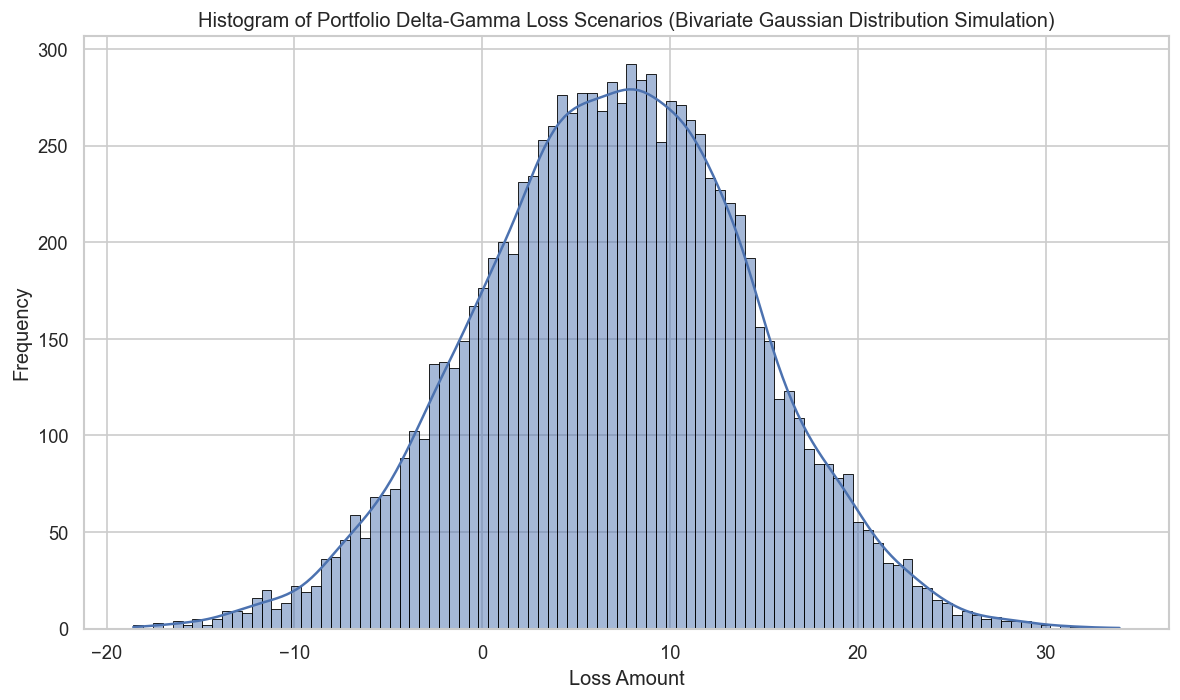

### Delta-Gamma (Standard Bivariate Gaussian Distribution Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 23.5372<br /> &emsp; - ES: 26.0279

In [37]:
delta_gamma_loss_bivariate_gaussian_distribution_simulation_risk_measures= risk_measures.delta_gamma_loss_bivariate_gaussian_distribution_simulation(
    constant_loss=c_t,
    first_order_risk_exposure=b_t,
    second_order_risk_exposure=B_t,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    age_weight_decay=None,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True)


In [38]:
# delta_gamma_loss_bivariate_gaussian_distribution_simulation_risk_measures.display_backtest_results()

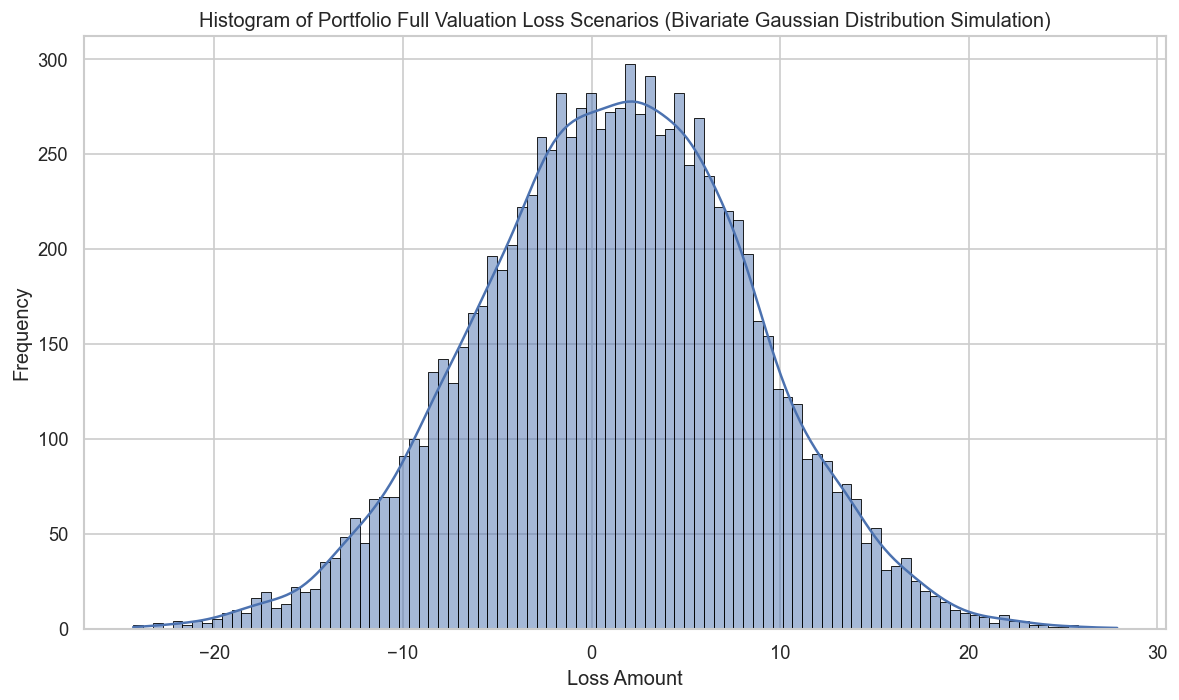

### Full Valuation (Standard Bivariate Gaussian Distribution Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 17.6917<br /> &emsp; - ES: 20.1503

In [39]:
full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures = risk_measures.full_valuation_loss_bivariate_gaussian_distribution_simulation(
    today_date=TODAY,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    age_weight_decay=None,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True)

In [40]:
# full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures.display_backtest_results()

#### Interpretation
- **Directionally consistent:** The **$\Delta \Gamma$** approach produces **higher** tails than **Full revaluation**.  
  This is expected: the quadratic expansion keeps curvature ($\Gamma$) fixed and can **overstate losses** for large simulated moves, whereas full BSM repricing yields a **bounded nonlinear payoff**.
- **Magnitude:** The gap is material ($\Delta \Gamma$ vs Full):
  - Indicating meaningful sensitivity to curvature in the simulated 10-day shocks.
- **Gaussian features:** With a Gaussian joint model there is **no tail dependence** $\lambda_L=\lambda_U=0$ joint extremes arise only via **linear correlation** in $\hat\Sigma_t$. Thus the tails here are driven by the combination of correlation and portfolio nonlinearity rather than copula tail effects.
- The $\Delta \Gamma$ method is **conservative**, reflecting fixed curvature in large moves
- Full repricing provides a **more accurate** assessment of nonlinear payoffs for the Gaussian joint-return setting.

#### Task 4.2.3.5
- Compare the risk measures obtained under the t-copula and joint Gaussian distribution assumptions. 
- Discuss why the results may be different and which joint model may be more appropriate.


##### Comparison
- The **Gaussian** dependence generates **much larger** losses than the **Student's t copula** fit.  
  This can only happen if the **fitted Student's t copula** implies **weaker effective dependence** in the loss-relevant region than the Gaussian correlation used.

##### Why the t copula risk measures are smaller:
1. **Student's t fit (moderately large $\nu$).**
   The fitted Student's t copula ($\nu = 7.89$, $\rho = 0.35$) exhibits relatively high degrees of freedom and moderate positive correlation, implying weak tail dependence.
2. **Tail dependence too weak in the fit.**  
   The computed Student's t copula tail dependence **$\lambda \approx 0.0683$** (vs empirical ≈ **$0.14–0.17$**).  
   This means the Student's t fit **understates joint tails**. the Gaussian has no tail dependence, but if its **linear correlation is higher**, it can still produce **bigger 99% losses** than a weak-tail Student's t fit.
3. **Portfolio loss geometry.**  
   With options, losses may be driven by **moderate, positively correlated** moves (where Gaussian mass is concentrated) rather than ultra-extremes. A Student's t copula with weak $\rho$ and modest $\nu$ will yield **fewer** of those joint moderates hitting the portfolio’s “worst region”, lowering $VaR$/$ES$.

##### Which joint model is more appropriate?
- **Conceptually:** For equities, a **Student's t copula** is usually preferable because it **can** match **non-zero tail dependence** seen in data.  
- The **fitted** Student's t copula currently **underestimates** empirical tail dependence and likely has **lower effective concordance** than the Gaussian. As fitted, it **understates joint tail risk** relative to both the data and the Gaussian run.

##### Recommendations to improve the model
- **Refit/retune the Student's t copula:**  
  - Fit by IFM but validate with **tail-dependence diagnostics** (Proposition 4.17) to target empirical $\lambda$.
- **Re-run with same seed / more paths ($\geq 50k$)** to reduce Monte Carlo noise in the 1% tail.

##### Summary
- Because the marginals are identical, the gap comes from the **dependence fit**. 
- The **Gaussian** run is more conservative here because the **Student's t copula fit is too light in the tails and/or too weakly correlated**. 
- Conceptually the **Student's t copula** is the right choice for equity pairs **if** it’s calibrated to match the observed tail dependence. 
- Otherwise, the Gaussian dependence may produce more conservative risk numbers but at the cost of **missing true tail co-movement** evidenced in the data.



### 4.3 Stressed VaR and ES Calculations

**Objective:**  
Calculate stressed 10-day 99% VaR and ES using historical log-returns from two stress periods:

- **Stress Period 1:** 3 Dec 2007 – 30 Jun 2009 (Global Financial Crisis)  
- **Stress Period 2:** 30 Jan 2020 – 1 Feb 2021 (COVID-19 pandemic)

**Risk models to be applied:**
- Analytical approach  
- Standard Historical Simulation (full valuation)  
- Monte Carlo (full valuation, Student’s t copula)  
- Monte Carlo (full valuation, bivariate Gaussian distribution)  

**Key assumptions:**
- Exposure coefficients (from Task 4.1.5) remain fixed.  
- Option features (including volatility inputs) are held at **current market values**, since stressed VaR/ES should reflect present exposures under stress scenarios.  

In [41]:
# Global Financial Crisis
stress_period_1_start = pd.Timestamp('2007-12-03')
stress_period_1_end = pd.Timestamp('2009-06-30')

stress_period_1_risk_measures = RiskMeasures(
    close_prices=prices, 
    time_horizon=TIME_HORIZON, 
    trading_days=TRADING_DAYS, 
    confidence_level=ALPHA,
    stress_period_start=stress_period_1_start,
    stress_period_end=stress_period_1_end)

# stress_period_1_risk_measures.plot_close_prices()
# stress_period_1_risk_measures.plot_log_returns()

In [42]:
# COVID-19 pandemic
stress_period_2_start = pd.Timestamp('2020-01-30')
stress_period_2_end = pd.Timestamp('2021-02-01')

stress_period_2_risk_measures = RiskMeasures(
    close_prices=prices, 
    time_horizon=TIME_HORIZON, 
    trading_days=TRADING_DAYS, confidence_level=ALPHA,
    stress_period_start=stress_period_2_start,
    stress_period_end=stress_period_2_end)

# stress_period_2_risk_measures.plot_close_prices()
# stress_period_2_risk_measures.plot_log_returns()

### Task 4.3.1

- Compute the 10-day 99% VaR and ES using the **analytical (variance–covariance) method**.  
- Assumptions:  
  - The mean vector and covariance matrix of the log-returns are taken as the **sample mean** and **sample covariance matrix** of the log-returns **within each stress period**.  
  - Do **not** use the EWMA covariance from Section 4.1.  
- Exposure coefficients and option features remain fixed at their current values.  

In [43]:
display(Markdown("### Stress Period 1 (Global Financial Crisis)"))

stress_period_1_mean_log_returns = stress_period_1_risk_measures.get_mean_log_returns(display_output=True)

stress_period_1_covariance_matrix = stress_period_1_risk_measures.get_covariance_matrix(
    covariance_method=COVARIANCE_METHOD.SAMPLE,
    display_output=True)


### Stress Period 1 (Global Financial Crisis)

### Mean 10-day log-returns:

#### &emsp; - AAPL: -0.0079

#### &emsp; - IBM: 0.0002

### Sample Covariance Matrix:

,AAPL,IBM
AAPL,0.0116,0.0035
IBM,0.0035,0.0038


In [44]:
display(Markdown("### Stress Period 2 (COVID-19 pandemic)"))

stress_period_2_mean_log_returns = stress_period_2_risk_measures.get_mean_log_returns(display_output=True)

stress_period_2_covariance_matrix = stress_period_2_risk_measures.get_covariance_matrix(
    covariance_method=COVARIANCE_METHOD.SAMPLE,
    display_output=True)

### Stress Period 2 (COVID-19 pandemic)

### Mean 10-day log-returns:

#### &emsp; - AAPL: 0.0223

#### &emsp; - IBM: -0.0063

### Sample Covariance Matrix:

,AAPL,IBM
AAPL,0.0060,0.0033
IBM,0.0033,0.0061


In [45]:
display(Markdown("### Stress Period 1 (Global Financial Crisis)"))

stress_period_1_analytical_risk_measures = stress_period_1_risk_measures.VaR_ES_variance_covariance(
    constant_loss=c_t,
    first_order_risk_exposure=b_t,
    mean_loss=None,
    covariance_loss=stress_period_1_covariance_matrix,
    confidence_level=ALPHA,
    display_output=True
)


### Stress Period 1 (Global Financial Crisis)

### Analytical 10-day 99.0% Risk Measures:

#### &emsp; - VaR: 36.5770<br /> &emsp; - ES: 41.1049

In [46]:
display(Markdown("### Stress Period 2 (COVID-19 pandemic)"))

stress_period_2_analytical_risk_measures = stress_period_2_risk_measures.VaR_ES_variance_covariance(
    constant_loss=c_t,
    first_order_risk_exposure=b_t,
    mean_loss=None,
    covariance_loss=stress_period_2_covariance_matrix,
    confidence_level=ALPHA,
    display_output=True
)


### Stress Period 2 (COVID-19 pandemic)

### Analytical 10-day 99.0% Risk Measures:

#### &emsp; - VaR: 35.5273<br /> &emsp; - ES: 39.5654

### Task 4.3.2

- Apply the **standard historical simulation (HS) approach** with **full valuation**.  
- Use the log-returns observed during each **stress period** as the set of potential future log-return scenarios.  
- For each scenario:  
  - Revalue the portfolio under the stressed log-returns.  
  - Compute the corresponding portfolio loss.  
- From the empirical distribution of stressed losses, calculate the **10-day 99% VaR and ES**.  

### Stress Period 1 (Global Financial Crisis)

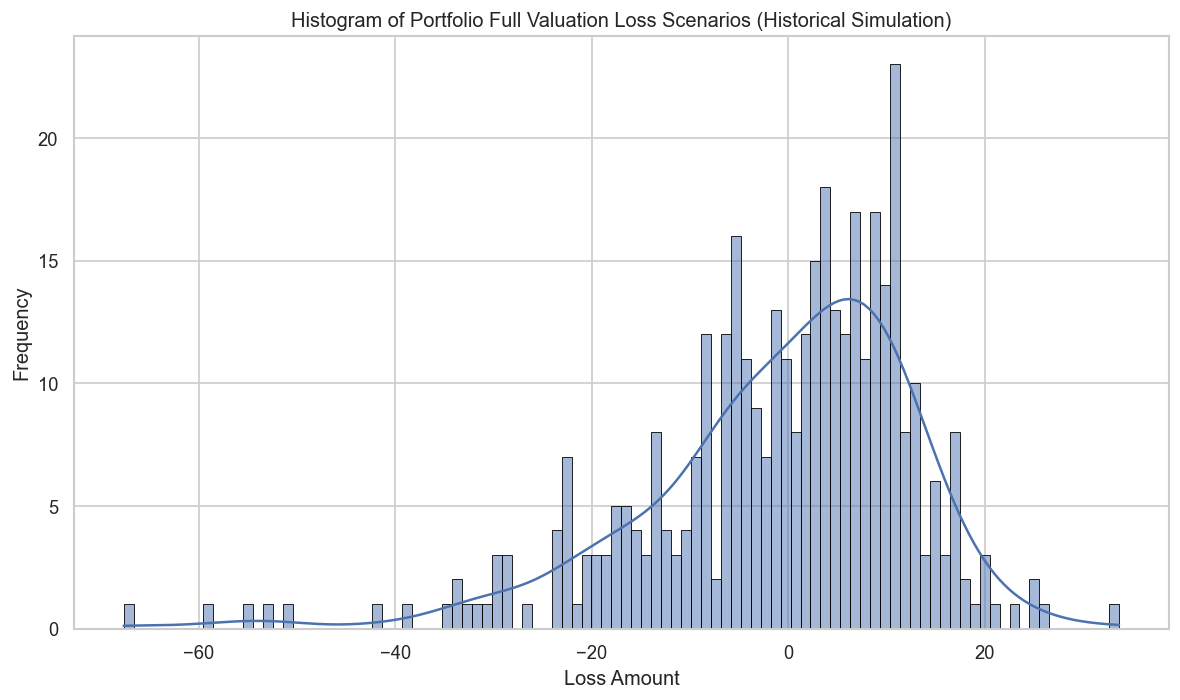

### Full Valuation (Standard Historical Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 23.0183<br /> &emsp; - ES: 27.5448

In [47]:
display(Markdown("### Stress Period 1 (Global Financial Crisis)"))

stress_period_1_risk_measures.set_portfolio(portfolio)

stress_period_1_full_valuation_loss_historical_simulation_risk_measures = stress_period_1_risk_measures.full_valuation_loss_historical_simulation(
    today_date=TODAY, 
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True)

In [48]:
# stress_period_1_full_valuation_loss_historical_simulation_risk_measures.display_backtest_results()

### Stress Period 2 (COVID-19 pandemic)

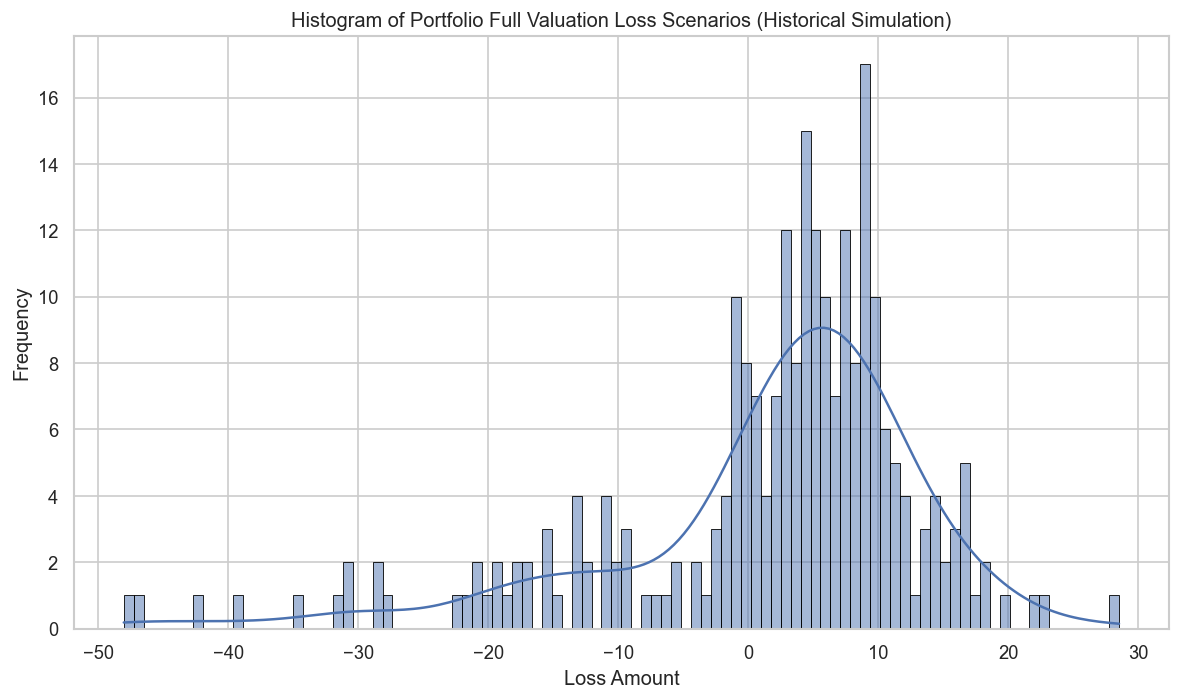

### Full Valuation (Standard Historical Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 20.9560<br /> &emsp; - ES: 25.0920

In [49]:
display(Markdown("### Stress Period 2 (COVID-19 pandemic)"))

stress_period_2_risk_measures.set_portfolio(portfolio)

stress_period_2_full_valuation_loss_historical_simulation_risk_measures = stress_period_2_risk_measures.full_valuation_loss_historical_simulation(
    today_date=TODAY, 
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True)


In [50]:
# stress_period_2_full_valuation_loss_historical_simulation_risk_measures.display_backtest_results()

### Task 4.3.3

- Estimate the **marginal distributions** of the log-returns and the parameters of the **t copula** using the log-returns observed during each stress period.  
- Use the **MLE procedure** (as in Task 1 of Section 4.2.3) to fit:  
  - Degrees of freedom ($\nu$)  
  - Correlation parameter ($\rho$)  
- Simulate **10,000 draws** of log-returns from this fitted model.  
- Apply the **full valuation approach** to reprice the portfolio under each simulated scenario.  
- From the empirical loss distribution, calculate the **10-day 99% VaR and ES**.  

### Stress Period 1 (Global Financial Crisis)

### Student's t Copula Parameters:

#### &emsp; - Using Empirical Cumulative Distribution Function of Log Returns

#### &emsp; - $\nu$: 2.9675<br /> &emsp; - $\rho$: 0.5000

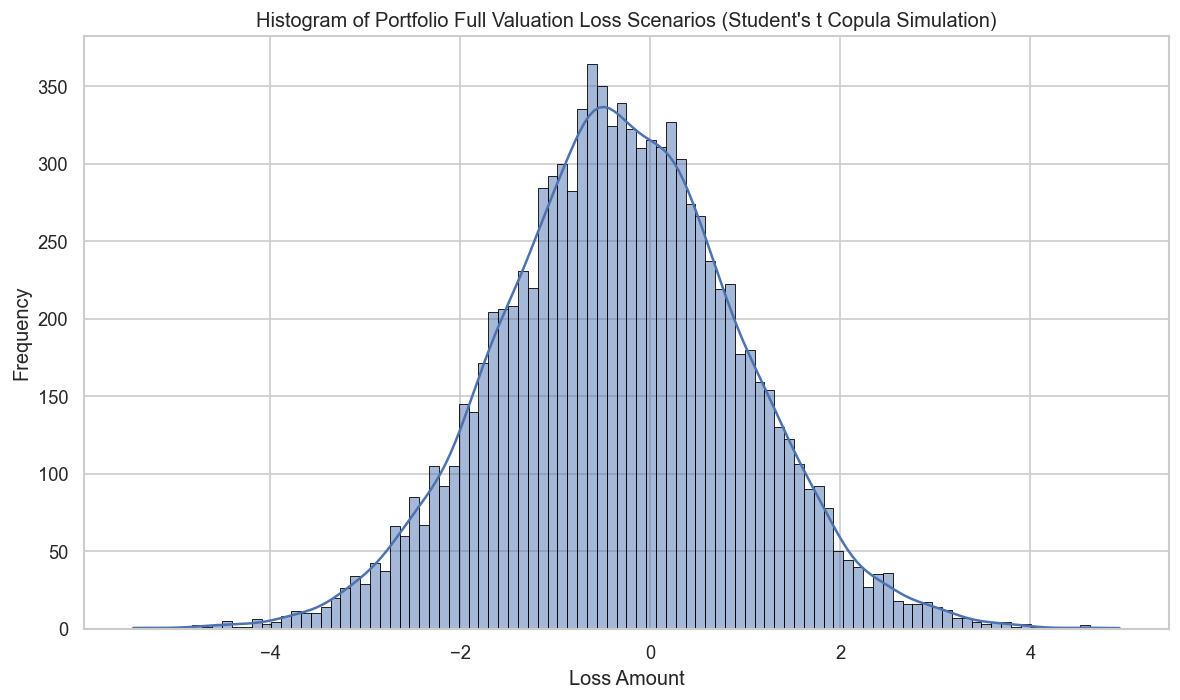

### Full Valuation (Standard Student's t Copula Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 2.7314<br /> &emsp; - ES: 3.1812

In [51]:
display(Markdown("### Stress Period 1 (Global Financial Crisis)"))

stress_period_1_risk_measures.fit_student_t_copula(
    pseudo_observations_method=PSEUDO_OBSERVATIONS_METHOD.EMPIRICAL,
    display_output=True
)

stress_period_1_risk_measures.set_student_t_copula_simulation_log_returns(N_simulations=N_SIMULATIONS, plot=False)

stress_period_1_full_valuation_loss_student_t_copula_simulation_risk_measures = stress_period_1_risk_measures.full_valuation_loss_student_t_copula_simulation(
    today_date=TODAY,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    age_weight_decay=None,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True
)

In [52]:
# stress_period_1_full_valuation_loss_student_t_copula_simulation_risk_measures.display_backtest_results()

### Stress Period 2 (COVID-19 pandemic)

### Student's t Copula Parameters:

#### &emsp; - Using Empirical Cumulative Distribution Function of Log Returns

#### &emsp; - $\nu$: 49.7594<br /> &emsp; - $\rho$: 0.3904

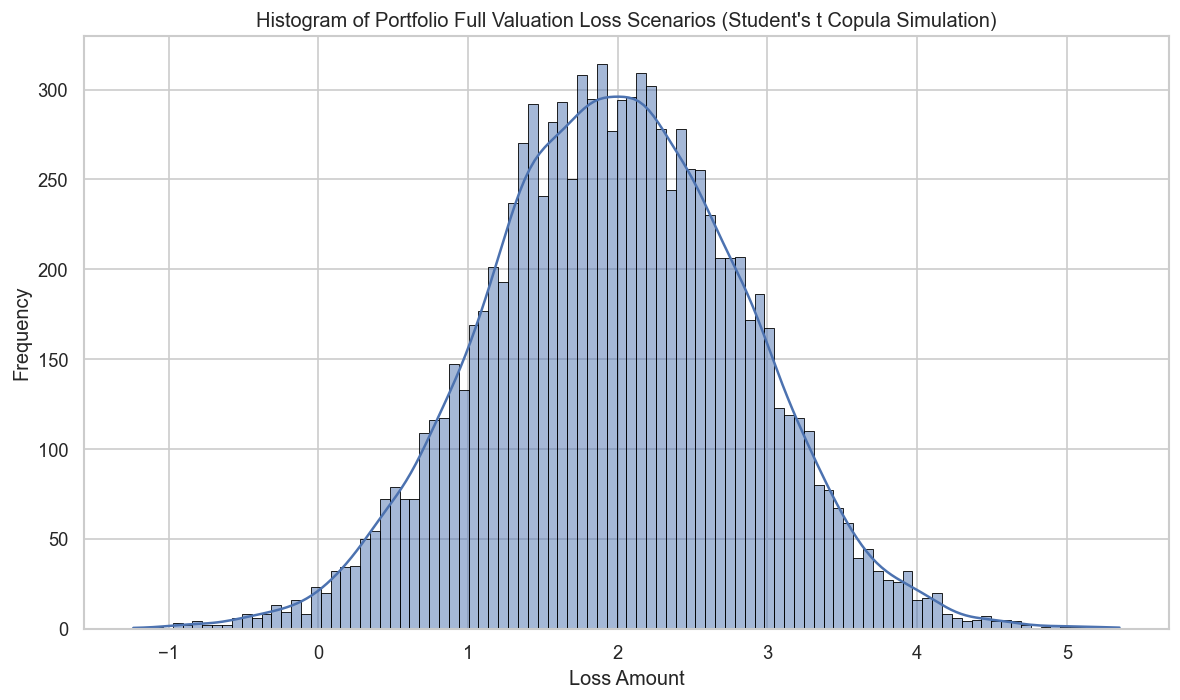

### Full Valuation (Standard Student's t Copula Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 4.0125<br /> &emsp; - ES: 4.3228

In [53]:
display(Markdown("### Stress Period 2 (COVID-19 pandemic)"))

stress_period_2_risk_measures.fit_student_t_copula(
    pseudo_observations_method=PSEUDO_OBSERVATIONS_METHOD.EMPIRICAL,
    display_output=True
)

stress_period_2_risk_measures.set_student_t_copula_simulation_log_returns(N_simulations=N_SIMULATIONS, plot=False)

stress_period_2_full_valuation_loss_student_t_copula_simulation_risk_measures = stress_period_2_risk_measures.full_valuation_loss_student_t_copula_simulation(
    today_date=TODAY,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    age_weight_decay=None,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True
)


In [54]:
# stress_period_2_full_valuation_loss_student_t_copula_simulation_risk_measures.display_backtest_results()

### Task 4.3.4

Carry out the same task as above but with a bivariate Gaussian distribution to model the distribution of the log-returns (see also Task 4 of Section 4.2.3 for reference).

### Stress Period 1 (Global Financial Crisis)

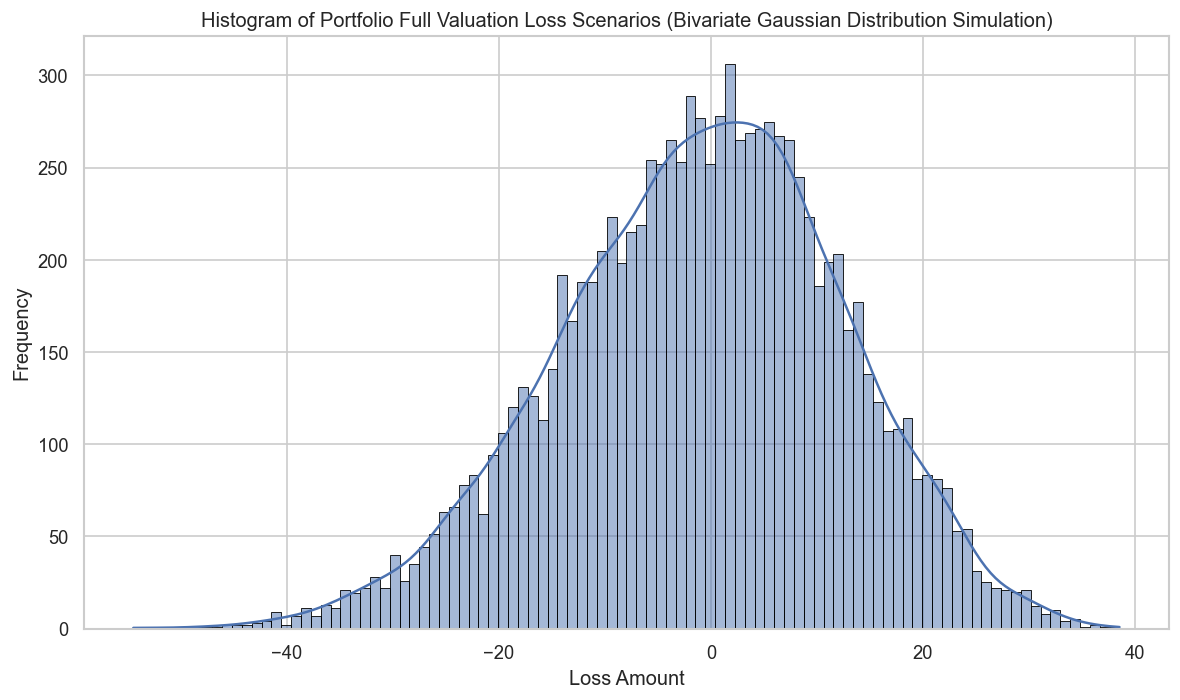

### Full Valuation (Standard Bivariate Gaussian Distribution Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 27.6783<br /> &emsp; - ES: 30.5285

In [55]:
display(Markdown("### Stress Period 1 (Global Financial Crisis)"))

stress_period_1_risk_measures.set_bivariate_gaussian_distribution_simulation_log_returns(N_simulations=N_SIMULATIONS, plot=False)

stress_period_1_full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures = stress_period_1_risk_measures.full_valuation_loss_bivariate_gaussian_distribution_simulation(
    today_date=TODAY,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    age_weight_decay=None,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True)


In [56]:
# stress_period_1_full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures.display_backtest_results()

### Stress Period 2 (COVID-19 pandemic)

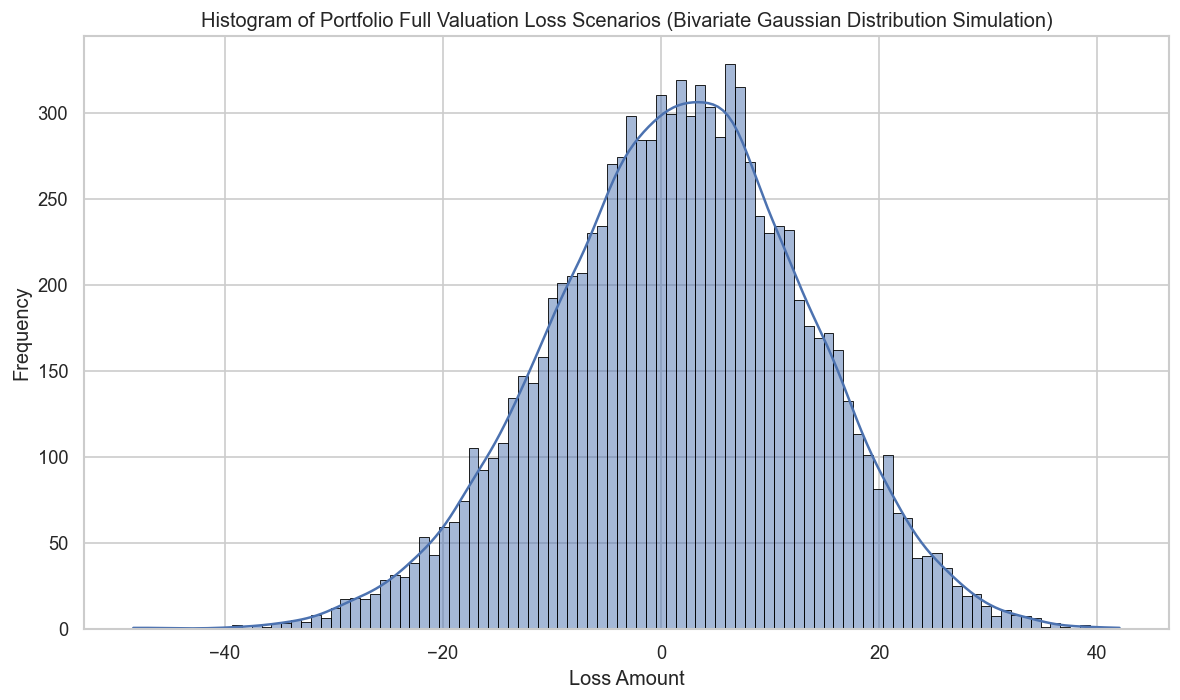

### Full Valuation (Standard Bivariate Gaussian Distribution Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 27.4889<br /> &emsp; - ES: 30.9819

In [57]:
display(Markdown("### Stress Period 2 (COVID-19 pandemic)"))

stress_period_2_risk_measures.set_bivariate_gaussian_distribution_simulation_log_returns(N_simulations=N_SIMULATIONS, plot=False)

stress_period_2_full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures = stress_period_2_risk_measures.full_valuation_loss_bivariate_gaussian_distribution_simulation(
    today_date=TODAY,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    age_weight_decay=None,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=True,
    display_output=True)

In [58]:
# stress_period_2_full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures.display_backtest_results()

### Task 4.3.5

- Summarise the results from the analytical, historical simulation, and Monte Carlo approaches (t copula and Gaussian) in **tabular format**.  
  - This can be presented either as a **data frame** object or as a **Markdown table**.  
- Compare the stressed 10-day 99% VaR and ES estimates with the corresponding risk measures obtained earlier in **Section 4.2**.  
- Discuss:  
  - Whether the values in the summary table can be interpreted as **stressed risk measure estimates**.  
  - Why or why not these stressed estimates appropriately capture the effect of financial crises on portfolio risk.  

In [59]:
data = {
    'Analytical': {
        'Stress Period 1': stress_period_1_analytical_risk_measures.get_risk_measures(),
        'Stress Period 2': stress_period_2_analytical_risk_measures.get_risk_measures()
    },
    'Standard Historical Simulation': {
        'Stress Period 1': stress_period_1_full_valuation_loss_historical_simulation_risk_measures.get_risk_measures(),
        'Stress Period 2': stress_period_2_full_valuation_loss_historical_simulation_risk_measures.get_risk_measures()
    },
    'Monte Carlo Simulation (t Copula)': {
        'Stress Period 1': stress_period_1_full_valuation_loss_student_t_copula_simulation_risk_measures.get_risk_measures(),
        'Stress Period 2': stress_period_2_full_valuation_loss_student_t_copula_simulation_risk_measures.get_risk_measures()
    },
    'Monte Carlo Simulation (Gaussian)': {
        'Stress Period 1': stress_period_1_full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures.get_risk_measures(),
        'Stress Period 2': stress_period_2_full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures.get_risk_measures()
    }
}

rows = []
for method, periods in data.items():
    row = [method]
    for period in ['Stress Period 1', 'Stress Period 2']:
        row.extend([periods[period][0], periods[period][1]])
    rows.append(row)

columns = pd.MultiIndex.from_tuples([
    ('Method', ''),
    ('Stress Period 1', 'VaR'),
    ('Stress Period 1', 'ES'),
    ('Stress Period 2', 'VaR'),
    ('Stress Period 2', 'ES')
])

df = pd.DataFrame(rows, columns=columns)
display(Markdown("Table 1: Stressed 10-day 99% VaR and ES using log-returns during Stress Periods 1 and 2."))
display(df)

Table 1: Stressed 10-day 99% VaR and ES using log-returns during Stress Periods 1 and 2.

Method Stress Period 1         Stress Period 2  \
                                                 VaR      ES             VaR   
0                         Analytical         36.5770 41.1049         35.5273   
1     Standard Historical Simulation         23.0183 27.5448         20.9560   
2  Monte Carlo Simulation (t Copula)          2.7314  3.1812          4.0125   
3  Monte Carlo Simulation (Gaussian)         27.6783 30.5285         27.4889   

           
       ES  
0 39.5654  
1 25.0920  
2  4.3228  
3 30.9819

Table 2: Sample Period, Stress Period 1, and Stress Period 2; 10-day 99% VaR and ES using log-returns during Sample Period, Stress Periods 1 and 2.

Method Sample Period         Stress Period 1  \
                                               VaR      ES             VaR   
0                         Analytical       24.0993 26.5560         36.5770   
1     Standard Historical Simulation       10.2335 11.1885         23.0183   
2  Monte Carlo Simulation (t Copula)        2.8488  3.0678          2.7314   
3  Monte Carlo Simulation (Gaussian)       17.6917 20.1503         27.6783   

          Stress Period 2          
       ES             VaR      ES  
0 41.1049         35.5273 39.5654  
1 27.5448         20.9560 25.0920  
2  3.1812          4.0125  4.3228  
3 30.5285         27.4889 30.9819

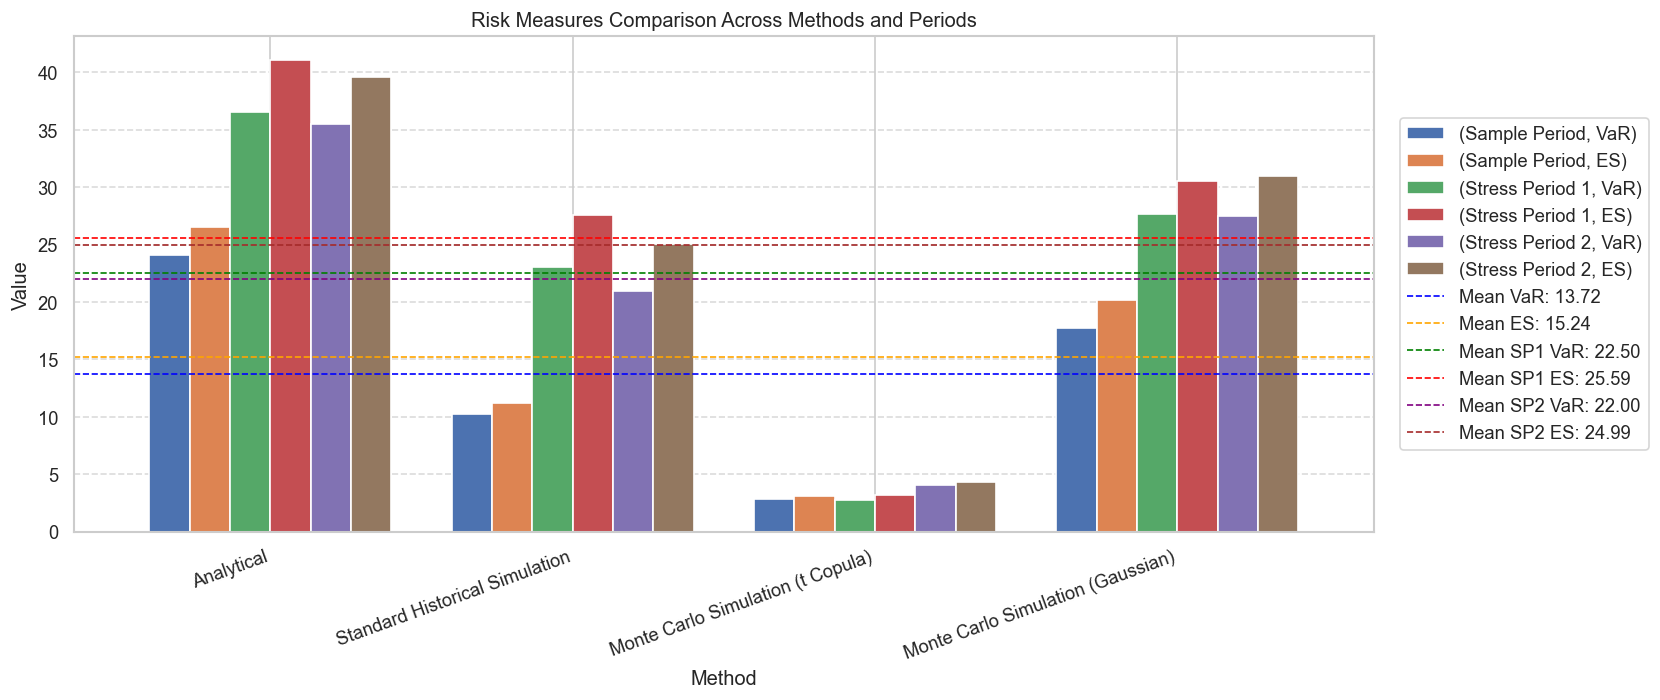

Chart 1: Sample Period, Stress Period 1, and Stress Period 2; 10-day 99% VaR and ES using log-returns during Sample Period, Stress Periods 1 and 2.

In [60]:
data = {
    'Analytical': {
        'Sample Period': VaR_analytical.get_risk_measures(),
        'Stress Period 1': stress_period_1_analytical_risk_measures.get_risk_measures(),
        'Stress Period 2': stress_period_2_analytical_risk_measures.get_risk_measures()
    },
    'Standard Historical Simulation': {
        'Sample Period': full_valuation_loss_historical_simulation_risk_measures.get_risk_measures(),
        'Stress Period 1': stress_period_1_full_valuation_loss_historical_simulation_risk_measures.get_risk_measures(),
        'Stress Period 2': stress_period_2_full_valuation_loss_historical_simulation_risk_measures.get_risk_measures()
    },
    'Monte Carlo Simulation (t Copula)': {
        'Sample Period': full_valuation_loss_student_t_copula_simulation_risk_measures.get_risk_measures(),
        'Stress Period 1': stress_period_1_full_valuation_loss_student_t_copula_simulation_risk_measures.get_risk_measures(),
        'Stress Period 2': stress_period_2_full_valuation_loss_student_t_copula_simulation_risk_measures.get_risk_measures()
    },
    'Monte Carlo Simulation (Gaussian)': {
        'Sample Period': full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures.get_risk_measures(),
        'Stress Period 1': stress_period_1_full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures.get_risk_measures(),
        'Stress Period 2': stress_period_2_full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures.get_risk_measures()
    }
}

rows = []
for method, periods in data.items():
    row = [method]
    for period in ['Sample Period', 'Stress Period 1', 'Stress Period 2']:
        row.extend([periods[period][0], periods[period][1]])
    rows.append(row)

columns = pd.MultiIndex.from_tuples([
    ('Method', ''),
    ('Sample Period', 'VaR'),
    ('Sample Period', 'ES'),
    ('Stress Period 1', 'VaR'),
    ('Stress Period 1', 'ES'),
    ('Stress Period 2', 'VaR'),
    ('Stress Period 2', 'ES')
])

df = pd.DataFrame(rows, columns=columns)
display(Markdown("Table 2: Sample Period, Stress Period 1, and Stress Period 2; 10-day 99% VaR and ES using log-returns during Sample Period, Stress Periods 1 and 2."))
display(df)

df.set_index(('Method', ''), inplace=True)  # Set Method as index for easier plotting

# Calculate averages for each metric
avg_var = df[('Sample Period', 'VaR')].mean()
avg_es = df[('Sample Period', 'ES')].mean()
avg_sp1_var = df[('Stress Period 1', 'VaR')].mean()
avg_sp1_es = df[('Stress Period 1', 'ES')].mean()
avg_sp2_var = df[('Stress Period 2', 'VaR')].mean()
avg_sp2_es = df[('Stress Period 2', 'ES')].mean()

# Plot as grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
df.plot(kind='bar', ax=ax, width=0.8, rot=20)
# Adjust horizontal alignment for rotated labels to prevent overlap
ax.set_xticklabels(ax.get_xticklabels(), ha='right')  # Align to the right for better spacing
ax.set_title('Risk Measures Comparison Across Methods and Periods')
ax.set_ylabel('Value')
ax.set_xlabel('Method')
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add horizontal lines for averages (dashed, colored to match bar groups)
ax.axhline(avg_var, color='blue', linestyle='--', linewidth=1)
ax.axhline(avg_es, color='orange', linestyle='--', linewidth=1)
ax.axhline(avg_sp1_var, color='green', linestyle='--', linewidth=1)
ax.axhline(avg_sp1_es, color='red', linestyle='--', linewidth=1)
ax.axhline(avg_sp2_var, color='purple', linestyle='--', linewidth=1)
ax.axhline(avg_sp2_es, color='brown', linestyle='--', linewidth=1)

# Get existing legend handles and labels from the bars
handles, labels = ax.get_legend_handles_labels()

# Create custom dashed line handles for the averages and append to legend
avg_handles = [
    Line2D([0], [0], color='blue', linestyle='--', linewidth=1),
    Line2D([0], [0], color='orange', linestyle='--', linewidth=1),
    Line2D([0], [0], color='green', linestyle='--', linewidth=1),
    Line2D([0], [0], color='red', linestyle='--', linewidth=1),
    Line2D([0], [0], color='purple', linestyle='--', linewidth=1),
    Line2D([0], [0], color='brown', linestyle='--', linewidth=1)
]
avg_labels = [
    f'Mean VaR: {avg_var:.2f}',
    f'Mean ES: {avg_es:.2f}',
    f'Mean SP1 VaR: {avg_sp1_var:.2f}',
    f'Mean SP1 ES: {avg_sp1_es:.2f}',
    f'Mean SP2 VaR: {avg_sp2_var:.2f}',
    f'Mean SP2 ES: {avg_sp2_es:.2f}'
]
ax.legend(handles + avg_handles, labels + avg_labels, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
plt.tight_layout()
plt.show()

display(Markdown("Chart 1: Sample Period, Stress Period 1, and Stress Period 2; 10-day 99% VaR and ES using log-returns during Sample Period, Stress Periods 1 and 2."))

#### Task 4.3.5
- Comparison and Discussion — Stressed VaR and ES Estimates

---

**Table 2** and **Chart 1** display and visualise the results across methods and periods, highlighting how both VaR and ES respond to changes in the underlying stress data.  
The coloured bars show each model’s performance across the three time windows, while the dashed lines mark the **mean VaR and ES** for each period.

---

##### Key observations
1. **Analytical and Gaussian Monte Carlo methods** show the **highest stressed VaR and ES**, with both increasing sharply during the 2007–09 (Stress 1) and 2020–21 (Stress 2) periods.  
   - These models are **volatility-driven**: when the covariance matrix is estimated using stress-period data, higher variance and correlation lead to stronger tail losses.  
   - Chart 1 shows these as the tallest bars across all periods.
2. **Standard Historical Simulation (HS)** produces **moderate increases** in risk measures under stress.  
   - HS captures actual loss realisations from each stress period but does **not extrapolate** beyond them.  
   - Consequently, its VaR/ES rises in Chart 1 but remains well below the analytical and Gaussian results.
3. **Student’s t Copula Monte Carlo** gives **consistently lower VaR and ES** across all periods.  
   - Despite its theoretical ability to model tail dependence, the fitted parameters imply **weak tail dependence**.  
   - In Chart 1, these results appear as the smallest bars, confirming that the current Student's t copula fit understates joint tail risk.

---

##### Comparison with Section 4.2 (sample-period results)
Relative to the **sample-period estimates**, Chart 1 shows that:
- **All methods produce higher VaR/ES under stress**, confirming that both crisis periods exhibited elevated volatility and correlation.  
- The **Analytical** and **Gaussian** models are the most sensitive to stress, displaying increases of roughly 40–50% increase to risk measures relative to the sample period.  
- The **Student’s t Copula** is notably *insensitive*—its stressed VaR and ES are only slightly above, or even below, the sample-period values, signalling that its not well suited to capture crisis-period co-movements.

---

##### Appropriateness of using as stressed period estimates
**Yes — with caveats.**

The risk measures in Table 1 effectively illustrate how each model behaves when calibrated to **stress-period data**:
- They satisfy the Basel-style definition of **Stressed VaR**, since risk measures are re-estimated using historical crisis windows while keeping **current portfolio exposures** ($\Delta$, $\Gamma$, $\Theta$) fixed.
- The **Analytical** and **Gaussian Monte Carlo** results provide **credible stressed VaR/ES estimates**, as they clearly reflect amplified variance–covariance structures.
- However, the **Student's t Copula** results are **not appropriate stressed estimates** in their current form, because the fitted model produces tails that are too light. Its bars in Chart 1 remain far below the other methods even during stress, contradicting empirical evidence of stronger co-movements.

---

##### Summary
- Chart 1 visually confirms that risk measures rise substantially when stress-period data are used, particularly under the Analytical and Gaussian Monte Carlo frameworks.  
- These models effectively capture the increased volatility and correlation characteristic of financial crises and thus provide plausible **stressed risk estimates**.  
- The Standard HS model gives a realistic but milder response, while the Student’s t Copula fails to reproduce stressed joint extremes.  
- Therefore, Table 1 and Chart 1 appropriately summarise the **stressed VaR and ES results**, but only the Analytical and Gaussian methods should be considered **reliable stressed risk measures** in line with the lecture framework on *Market Risk Modelling* (pp. 78–83).

### 4.4 A Simple Risk Minimization Strategy

- Let $\eta_1 > 0$ and $\eta_2 > 0$ denote the numbers of shares held short in AAPL and IBM, respectively.  
- Unlike in earlier sections where $\eta_1 = \eta_2 = 1$ was fixed, here they are **unspecified**.  
- Objective: **determine the optimal values of $\eta_1$ and $\eta_2$ that minimize the portfolio’s risk** (measured by 10-day 99% VaR/ES) over the risk management horizon.  

#### Task 4.4.1 
- Analytical Minimization under the Delta Model

With log-return vector $X_{t+1}\in\mathbb{R}^2$ and current Greeks,
$$
L^\Delta_{t+1} = -c_t - b_t^\top X_{t+1}, \qquad
b_t = 
\begin{bmatrix}
(\Delta_1 - \eta_1) S_1 \\
(\Delta_2 - \eta_2) S_2
\end{bmatrix}.
$$

Under the Gaussian assumption $X_{t+1} \sim \mathcal{N}_2(\hat{\mu}_t,\hat{\Sigma}_t)$,
$$
\mathbb{E}[L^\Delta] = -c_t - b_t^\top \hat{\mu}_t, \qquad
\mathrm{Var}(L^\Delta) = b_t^\top \hat{\Sigma}_t b_t.
$$

- **VaR/ES (Gaussian)** are monotone in the **standard deviation** $\sqrt{b_t^\top \hat{\Sigma}_t b_t}$ (the mean term is typically tiny over 10 days).  
- Therefore, minimizing 10-day VaR/ES is **equivalent** to minimizing the **variance** $b_t^\top \hat{\Sigma}_t b_t$.

Define **dollar exposures**
$$
d := 
\begin{bmatrix}
\Delta_1 S_1 \\
\Delta_2 S_2
\end{bmatrix}, \qquad
h := 
\begin{bmatrix}
\eta_1 S_1 \\
\eta_2 S_2
\end{bmatrix}.
$$

Then $b_t = d - h$, and the problem becomes
$$
\min_{\,\eta_1,\eta_2 > 0} \; (d - h)^\top \hat{\Sigma}_t (d - h).
$$

This is a convex quadratic with unique minimizer at
$$
\frac{\partial}{\partial h} \,(d - h)^\top \hat{\Sigma}_t (d - h) 
= -2 \hat{\Sigma}_t (d - h) = 0
\;\;\Longrightarrow\;\; h^\star = d.
$$

Back-substitute $h_i^\star = \eta_i^\star S_i = d_i = \Delta_i S_i$ to get the **closed form**
$$
\boxed{ \; \eta_i^\star = \Delta_i, \quad i=1,2. \; }
$$

---

##### Summary

Under the delta (linear) loss with $X_{t+1}\sim\mathcal N_2(\hat{\mu}_t,\hat{\Sigma}_t)$, minimizing 10-day VaR/ES is equivalent to minimizing $\mathrm{Var}(L^\Delta)=b_t^\top \hat{\Sigma}_t b_t$. Setting the gradient to zero yields $h^\star=d$, i.e. $\eta_i^\star=\Delta_i$. Thus, the risk-minimizing short shares equal the options’ deltas, making the portfolio approximately delta-neutral today.

This makes the portfolio delta-neutral, eliminating first-order sensitivity to stock price changes. Residual risk then arises only from higher-order terms such as gamma and theta.

>*ChatGPT (OpenAI, 2025)* was used to assist with the explanation, structuring, and presentation of the analytical and simulation-based optimization steps.  
>Specifically, the model was used to:
>- Explain the theoretical setup and derivation of the delta–gamma loss approximation and its application to portfolio hedging (Part 1).  
>- Provide LaTeX and markdown formatting for mathematical expressions (Parts 1–5).  
>- Summarize and clarify the interpretation of optimization results across analytical, historical simulation, and Monte Carlo methods (Parts 2–5).  
>- Draft markdown sections and example code blocks illustrating the implementation of each approach.
>
>All mathematical derivations, code, and final interpretations were reviewed, verified, and revised by the author to ensure correctness and alignment with course expectations.

In [61]:
hedged_eta_aapl = call_aapl.get_delta()
hedged_eta_ibm = call_ibm.get_delta()

hedged_c_t = (theta_aapl + theta_ibm) * DELTA_T
hedged_b_t = np.array([S_aapl * (delta_aapl - hedged_eta_aapl), S_ibm * (delta_ibm - hedged_eta_ibm)])
hedged_B_t = np.diag([gamma_aapl * S_aapl**2 + S_aapl * (delta_aapl - hedged_eta_aapl), gamma_ibm * S_ibm**2 + S_ibm * (delta_ibm - hedged_eta_ibm)])

display(Markdown(f"#### If $\eta_1 = {hedged_eta_aapl:.4f}$ and $\eta_2 = {hedged_eta_ibm:.4f}$"))
hedged_b_t_display = spy.Matrix(np.round(np.array(hedged_b_t, dtype=float), 4)) 
display(Math(fr"\mathbf{{b}}_t = {spy.latex(hedged_b_t_display)}"))

#### If $\eta_1 = 0.5957$ and $\eta_2 = 0.6652$

<IPython.core.display.Math object>

In [62]:
hedged_VaR_analytical = risk_measures.VaR_ES_variance_covariance(
    constant_loss=hedged_c_t, 
    first_order_risk_exposure=hedged_b_t, 
    mean_loss=None, 
    covariance_loss=ewma_log_ret_cov.to_numpy(), 
    confidence_level=ALPHA,
    display_output=False)

display(Markdown(f"#### By choosing $\eta_1 = {hedged_eta_aapl:.4f}$ and $\eta_2 = {hedged_eta_ibm:.4f}$"))
display(Markdown(f"#### &emsp; -  $VaR_{{{ALPHA}}}$ is reduced from {VaR_analytical.get_VaR():.4f} to {hedged_VaR_analytical.get_VaR():.4f}"))
display(Markdown(f"#### &emsp; - $ES_{{{ALPHA}}}$ is reduced from {VaR_analytical.get_ES():.4f} to {hedged_VaR_analytical.get_ES():.4f}"))
display(Markdown("Note: it is (unrealistically) assumed that the options are for 1 share and it is possible to short fractional shares."))

#### By choosing $\eta_1 = 0.5957$ and $\eta_2 = 0.6652$

#### &emsp; -  $VaR_{0.99}$ is reduced from 24.0993 to 6.2245

#### &emsp; - $ES_{0.99}$ is reduced from 26.5560 to 6.2245

Note: it is (unrealistically) assumed that the options are for 1 share and it is possible to short fractional shares.

#### Task 4.4.2
- Numerical Optimization (Analytical Model)

**Goal:** Find $\eta_1>0,\ \eta_2>0$ that minimize a **10-day risk** metric under the **analytical (Gaussian) model**.

In [63]:
def b_vec(eta1, eta2):
    return np.array([
        call_aapl.get_delta() - eta1,
        call_ibm.get_delta() - eta2
    ])

def J_VaR(etas):
    eta1, eta2 = etas
    b = b_vec(eta1, eta2)
    result = risk_measures.VaR_ES_variance_covariance(
        constant_loss=c_t,
        first_order_risk_exposure=b,
        mean_loss=None,
        covariance_loss=ewma_log_ret_cov.to_numpy(),
        confidence_level=ALPHA,
        display_output=False
    )
    return result.get_VaR()

x_0 = np.array([call_aapl.get_delta(), call_ibm.get_delta()])
bounds = [(0.0, None), (0.0, None)]

res = optimize.minimize(J_VaR, x_0, method="SLSQP", bounds=bounds, options={"ftol":1e-12, "maxiter":1000})
eta1_star, eta2_star = res.x
risk_star = res.fun

assert res.success == True

_b = b_vec(eta1_star, eta2_star)

display(Markdown(f"#### By choosing $\eta_1 = {eta1_star:.4f}$ and $\eta_2 = {eta2_star:.4f}$"))

minimised_VaR_analytical = risk_measures.VaR_ES_variance_covariance(
    constant_loss=c_t, 
    first_order_risk_exposure=_b, 
    mean_loss=None, 
    covariance_loss=ewma_log_ret_cov.to_numpy(), 
    confidence_level=ALPHA,
    display_output=True)

display(Markdown(f"##### When compared to the analytically-derived minimum VaR/ES, the numerical solution results in a change of {minimised_VaR_analytical.get_VaR() - hedged_VaR_analytical.get_VaR():.4f} in VaR and {minimised_VaR_analytical.get_ES() - hedged_VaR_analytical.get_ES():.4f} in ES."))

#### By choosing $\eta_1 = 0.5957$ and $\eta_2 = 0.6652$

### Analytical 10-day 99.0% Risk Measures:

#### &emsp; - VaR: 6.2245<br /> &emsp; - ES: 6.2245

##### When compared to the analytically-derived minimum VaR/ES, the numerical solution results in a change of 0.0000 in VaR and 0.0000 in ES.

### 4.4.3
- Historical Simulation (Full Valuation) Risk Minimization

**Goal:** Choose $\eta_1>0,\ \eta_2>0$ to **minimize 10-day risk** (VaR/ES) when portfolio losses are computed by **full revaluation** under **historical 10-day log-return scenarios**.

In [64]:
aapl_stock_index = 1
ibm_stock_index = 3

# Reset portfolio short positions
risk_measures.portfolio[aapl_stock_index].eta = 1
risk_measures.portfolio[ibm_stock_index].eta = 1

x_0 = np.array([call_aapl.get_delta(), call_ibm.get_delta()])
bounds = [(0.0, None), (0.0, None)]

def J_VaR(etas):
    eta1, eta2 = etas
    risk_measures.portfolio[aapl_stock_index].eta = eta1
    risk_measures.portfolio[ibm_stock_index].eta = eta2
    result = risk_measures.full_valuation_loss_historical_simulation(
    today_date=TODAY, 
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    confidence_level=ALPHA,
    plot=False,
    display_output=False)
    return result.get_VaR()

res = optimize.minimize(J_VaR, x_0, method="SLSQP", bounds=bounds, options={"ftol":1e-12, "maxiter":1000})
eta1_star, eta2_star = res.x

assert res.success == True


In [65]:
risk_measures.portfolio[aapl_stock_index].eta = eta1_star
risk_measures.portfolio[ibm_stock_index].eta = eta2_star

display(Markdown(f"#### By choosing $\eta_1 = {eta1_star:.4f}$ and $\eta_2 = {eta2_star:.4f}$"))

minimised_VaR_HS = risk_measures.full_valuation_loss_historical_simulation(
    today_date=TODAY, 
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=False,
    display_output=True)


#### By choosing $\eta_1 = 0.5955$ and $\eta_2 = 0.6647$

### Full Valuation (Standard Historical Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 0.4241<br /> &emsp; - ES: 0.4257

##### Interpretation of the Full Valuation (HS) vs Analytical

The optimal share amounts are essentially the same (differences $< 0.0005$), so the **hedge choice isn’t the driver**. The gap comes from how the **loss is mapped** and the **distributional assumption**.

---

**Analytical**
With a delta-neutral/variance-minimising hedge the one-period loss is:

$$
L_{t+1}^{\Delta,\Gamma} \approx 
-c_t\;-\;\mathbf{b}_t^\top \mathbf{X}_{t+1}\;-\;\mathbf{X}_{t+1}^\top B_t\,\mathbf{X}_{t+1}.
$$

(i) **$\eta$ is chosen to cancel the first–order term** (so $\mathbf{b}_t \approx \mathbf{0}$),  
(ii) **Second–order exposure** is ignored/assume tiny for the chosen horizon (so $B_t \approx 0$ and its contribution is neglected in the closed form), so the **only remaining term is the constant** $-c_t$

- In the analytical case, loss is **deterministic**, so
  $$
  \text{VaR}_{0.99} = \text{ES}_{0.99} = |c_t| \approx 6.2245,
  $$

The analytical result is essentially **the constant time-decay/carry over 10 days** after delta-neutralizing the stochastic component.

---

**Full Valuation (HS)**

Full revaluation allows the option’s **curvature and time decay to interact with the realized path**:
- **Convexity (gamma) gains on larger moves** can partially offset theta.  
- **Greeks change with price** (the analytical constant-theta assumption doesn’t capture this).  
- Using **empirical 10-day returns** (with overlap) further dampens tail estimates for a well delta-hedged book.

---

**The reason why the two approaches disagree**
- **Mapping difference:**  
  - Analytical ≈ **constant + (cancelled) linear + (neglected) quadratic** → dominated by **constant theta**.  
  - Full HS = **exact reprice** each scenario → residual risk is **small and path-dependent**.
- **Nonlinearity captured:**  
  - Analytical **doesn’t** capture dynamic changes in $\Delta,\Gamma,\Theta$ across scenarios;  
  - Full revaluation **does**, which can **mitigate** losses when the book is well hedged.

---

##### Summary
- The analytical hedge loss model collapses to a **constant time-decay/carry** over the 10-day horizon. 
- In contrast, the standard historical simulation with full revaluation reprices the options under each empirical return path; with the portfolio nearly delta-neutral, residual **gamma/vega** effects are small and often **offset** theta, yielding **much smaller tail losses**
- The difference arises from the **approximation vs exact re-pricing** of nonlinear payoffs and the **empirical vs parametric** treatment of risk-factor changes. 
- In practice, the full-revaluation HS numbers better reflect the realized path-dependent behaviour of a well-hedged book over 10 days, whereas the analytical figure is a conservative **theta-only** benchmark.

#### Task 4.4.4 
- Monte Carlo (t Copula, Full Valuation) Risk Minimization

**Goal:** Choose $\eta_1>0,\ \eta_2>0$ to **minimize 10-day risk** (VaR/ES) when losses are computed by **full revaluation** under **Monte Carlo scenarios** drawn from a **Student’s $t$ copula with Gaussian marginals**.

In [66]:
aapl_stock_index = 1
ibm_stock_index = 3

# Reset portfolio short positions
risk_measures.portfolio[aapl_stock_index].eta = 1
risk_measures.portfolio[ibm_stock_index].eta = 1

x_0 = np.array([call_aapl.get_delta(), call_ibm.get_delta()])
bounds = [(0.01, None), (0.01, None)]

def J_VaR(etas):
    eta1, eta2 = etas
    risk_measures.portfolio[aapl_stock_index].eta = eta1
    risk_measures.portfolio[ibm_stock_index].eta = eta2
    result = risk_measures.full_valuation_loss_student_t_copula_simulation(
        today_date=TODAY,
        historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
        age_weight_decay=None,
        confidence_level=ALPHA,
        plot=False,
        display_output=False
    )
    
    return result.get_VaR()

res = optimize.minimize(J_VaR, x_0, method="SLSQP", bounds=bounds, options={"ftol":1e-12, "maxiter":1000})
eta1_star, eta2_star = res.x


assert res.success == True


In [67]:
risk_measures.portfolio[aapl_stock_index].eta = eta1_star
risk_measures.portfolio[ibm_stock_index].eta = eta2_star

display(Markdown(f"#### By choosing $\eta_1 = {eta1_star:.4f}$ and $\eta_2 = {eta2_star:.4f}$"))

result = risk_measures.full_valuation_loss_student_t_copula_simulation(
    today_date=TODAY,
    historical_simulation_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    age_weight_decay=None,
    confidence_level=ALPHA,
    backtest=True,
    backtest_significance_level=0.05,
    plot=False,
    display_output=True
)

# result.display_backtest_results()

#### By choosing $\eta_1 = 0.0100$ and $\eta_2 = 0.7347$

### Full Valuation (Standard Student's t Copula Simulation) Risk Measures for 10-day 99.0% confidence level:

#### &emsp; - VaR: 0.1901<br /> &emsp; - ES: 0.3111

#### Monte Carlo (t-copula) — Full Valuation: Interpretation & Comparison

##### **Analytical Comparison**
- The **Analytical** result (VaR = ES) is effectively a **$\Theta$-only** constant after delta-neutralisation, hence it is **much larger** and does not reflect path-wise gamma/vega offsets over the 10-day horizon.
- Full revaluation along scenarios lets **convexity gains** and **Greek re-centering** partially offset $\Theta$, which the analytical shortcut cannot capture. Hence **much smaller** VaR/ES under both HS and MC.

---

##### **HS (full revaluation) Comparison**
With the **marginals held fixed** (empirical ranks) the only difference is the **dependence**:

- **Fitted t-copula parameters** have **weak tail dependence**. This copula **under-links extremes** relative to the historical co-movements embedded in HS, so simulated joint adverse moves are **less severe** resulting is **smaller VaR/ES**.
- **Hedge re-optimisation under the new dependence:** the simulation reveals that putting the hedge weight primarily on **asset 2 (IBM)** reduces tail loss more effectively (under the t-copula’s correlation structure) than the near-delta weights from HS/Analytical.

---

##### Interpretation of the hedge shift $(\eta_1 \downarrow,\ \eta_2 \uparrow)$

- Under the t-copula dependence, **asset 2 (IBM)** co-moves with the option risk factors in the **loss-relevant region** more than asset 1 (AAPL) does, so loading the hedge into asset 2 minimises the simulated tail risk.

---

##### Summary

- Using Monte Carlo with a **t-copula** and **full revaluation** yields **smaller** tail losses than the **standard HS** full-revaluation result, and far below the **Analytical** result. 

- Since marginals are identical, the gap to HS is explained by the **fitted t-copula’s weak tail dependence**, which produces fewer severe joint shocks than seen in historical co-movements. 

- The optimal hedge consequently shifts toward **asset 2**, reflecting that, under this dependence, asset 2 better offsets the portfolio’s residual nonlinear risk.

#### Task 4.4.5
- Residual Portfolio Risk Under the Optimal Hedge

When the **optimal number of shares (*$\eta_{1}$, $\eta_{1}$*)** is held short, the portfolio is **delta-neutral**. This eliminates the **first-order sensitivity** of portfolio value to small movements in the underlying stocks.  

---

##### Sources of residual risk

1. **Gamma (curvature) risk**  
   - The hedge is constructed using a *local* linear (delta) or quadratic (delta–gamma) approximation.  
   - For large underlying price moves, higher-order terms become important and cause the portfolio’s value to deviate from the linear hedge.  
   - This curvature creates **non-linear P&L** and is the main driver of risk after delta-neutralisation.

2. **Theta (time-decay) risk**  
   - Even if prices remain unchanged, option values fall over time because of the passage of time (negative $\Theta$).  
   - The **expected loss from theta** accumulates deterministically across the 10-day horizon and directly contributes to the mean loss of the portfolio.

3. **Vega and volatility-of-volatility risk**  
   - The hedge ignores changes in **implied volatility**.  
   - If volatilities rise or fall relative to those assumed in the BSM valuation, option values will move accordingly, introducing **vega risk**.

4. **Model and parameter risk**  
   - Both analytical and simulation-based methods rely on assumptions (log-normal returns, constant $\Sigma$, fixed Greeks, copula parameters $\nu$, $\rho$).  
   - Misspecification of these parameters leaves **residual unhedged variance**.

5. **Estimation and discretisation error**  
   - The hedge is computed using estimated $\Delta$ and $\Gamma$ at time $t$. These change continuously as prices evolve.  
   - Re-hedging is discrete (not continuous), so the portfolio remains exposed between hedge adjustments.

---

##### Summary

- After setting the optimal hedge ratios, the portfolio is protected against small price movements but remains exposed to **second-order (gamma)** effects, **time-decay (theta)**, **volatility**, and **model uncertainty**.  
- These factors account for the remaining risk over the 10-day horizon and explain why the portfolio’s VaR and ES remain positive even under the optimal number of shares.

### 4.5 Summary and Conclusions

#### Task 4.5.1
- Display all the risk measure estimates obtained in Section 4.2 in tabular format

In [68]:
data = {
    'Analytical': {
        'Sample Period': VaR_analytical.get_risk_measures(),
    },
    'Standard Historical Simulation': {
        'Sample Period': full_valuation_loss_historical_simulation_risk_measures.get_risk_measures(),
    },
    'Monte Carlo Simulation (t Copula)': {
        'Sample Period': full_valuation_loss_student_t_copula_simulation_risk_measures.get_risk_measures(),
    },
    'Monte Carlo Simulation (Gaussian)': {
        'Sample Period': full_valuation_loss_bivariate_gaussian_distribution_simulation_risk_measures.get_risk_measures(),
    }
}

rows = []
for method, periods in data.items():
    row = [method]
    for period in ['Sample Period']:
        row.extend([periods[period][0], periods[period][1]])
    rows.append(row)

columns = pd.MultiIndex.from_tuples([
    ('Method', ''),
    ('Sample Period', 'VaR'),
    ('Sample Period', 'ES')
])

df = pd.DataFrame(rows, columns=columns)
display(df)

Method Sample Period        
                                               VaR      ES
0                         Analytical       24.0993 26.5560
1     Standard Historical Simulation       10.2335 11.1885
2  Monte Carlo Simulation (t Copula)        2.8488  3.0678
3  Monte Carlo Simulation (Gaussian)       17.6917 20.1503

#### Task 4.5.2
- Choosing the Most Appropriate Market Risk Model

##### Observations
- The **Analytical** and **Bivariate Gaussian Monte Carlo** models yield the largest risk estimates, reflecting their strong parametric assumptions and sensitivity to the estimated covariance structure.  
- The **Standard Historical Simulation (HS)** approach gives more moderate risk measures, consistent with empirical returns over the sample period.  
- The **Student's t copula Monte Carlo** results are **much smaller**, producing $VaR$ and $ES$ values that are *unrealistically low* relative to the other models and the empirical data.

Given that the portfolio includes **non-linear option positions**, these differences reveal how well (or poorly) each method captures **dependence**, **tail behaviour**, and **non-linear revaluation**.

---

##### Interpreting the Student's t copula results

The t-copula parameters estimated earlier were:
$$
\nu = 7.89, \quad \rho = 0.35,
$$
which imply a **tail-dependence coefficient** of only **$\lambda \approx 0.068$** — essentially near-Gaussian behaviour.

Although the t-copula is designed to model heavy tails, a high $\nu$ means the fitted model behaves **almost like a Gaussian copula**, with *weak* tail dependence.  

Consequently, the simulated losses under this dependence structure are too mild, resulting in **$VaR ≈ 2.8$** and **$ES ≈ 3.0$**, far below any reasonable benchmark.

This suggests the current t-copula calibration is **underfitted** — the model form is correct, but the fitted parameters are not sufficiently heavy-tailed to capture empirical dependence.

---

##### Which model is most appropriate for this portfolio?

Given the portfolio’s characteristics — **non-linear options**, **delta hedges**, and **empirical 10-day overlapping returns** — the most appropriate model **for this sample period** is the:

> **Full Valuation – Standard Historical Simulation (HS)**

**Justification:**
- Uses **empirical joint dependence** of AAPL and IBM returns directly, avoiding parametric misspecification (such as an overly light-tailed t-copula).
- **Fully revalues** the option positions using Black–Scholes for each historical scenario, thus capturing all **non-linear (gamma/theta)** effects.
- Produces **realistic and stable VaR/ES values** ($\approx 10–11$), consistent with the hedged portfolio’s small but non-zero residual risk.
- Aligns with the *Market Risk Modelling* lecture slides (pp. 46–56), which highlight HS as the most transparent and empirically grounded method for option portfolios.

---

##### Strengths and limitations of the Historical Simulation approach

| **Strengths** | **Explanation** |
|:--|:--|
| **Empirically grounded** | Uses observed historical co-movements and volatilities. No assumptions about distributional form. |
| **Captures full non-linearity** | Each historical scenario re-prices the portfolio exactly, so $\Delta$, $\Gamma$, and $\Theta$ effects are fully reflected. |
| **Transparent and intuitive** | Results can be traced directly to real market events and stress periods. |
| **Model-free** | Avoids calibration bias and parametric errors (e.g., high $\nu$ in t-copula). |

<br />

| **Limitations** | **Explanation** |
|:--|:--|
| **Backward-looking** | Assumes historical dependence will persist; may understate future stress if market regimes change. |
| **Limited tail data** | Finite sample size restricts the accuracy of 99% tail estimates. |
| **Overlapping returns** | Induce serial correlation that can slightly bias tail estimates. |
| **No tail extrapolation** | Cannot simulate events outside historical experience without external stress testing. |


##### Recommendations

A refined Student's t copula model, **if recalibrated properly**, could become the *preferred* model.  
Specifically, reducing $\nu$ to the 3–5 range would strengthen tail dependence ($\lambda$ closer to the empirical 0.14–0.17), aligning the simulation with real-world joint extremes.

To achieve this:
- Apply **Inference Functions for Margins (IFM)** estimation to stabilise the marginal–copula separation.  
- Constrain $\nu$ during optimisation or apply a **penalty on large ν** values to prevent the fit from reverting to Gaussian behaviour.  
- Re-validate using empirical $\lambda$ and Kendall’s $\tau$ to ensure dependence realism.

A refined t-copula with lower $\nu$ and full revaluation would combine:
- The **flexibility** of simulation-based modelling,
- The **empirical realism** of heavy tails, and
- The **accuracy** of full option repricing.

---

##### Summary

- Based on the sample-period results (Table above), the **Full-Valuation Historical Simulation** method currently provides the most reliable estimate of the portfolio’s market risk.  
- It balances empirical realism and accurate revaluation of non-linear payoffs without introducing parametric bias.  
- However, if the **t-copula** were **refined to achieve stronger tail dependence** (e.g., $\nu \approx 3–5$) and fitted using a robust method such as **IFM**, it could become the preferred model for this type of portfolio — offering a flexible, tail-aware, simulation-based framework for $VaR$ and $ES$ estimation.

#### Task 4.5.3
- Strengths, Limitations, and Insights — Stress Testing Methodology (Section 4.3)


##### Strengths of the stress-testing approach

| **Strength** | **Explanation** |
|:--|:--|
| **Captures real crisis dynamics** | Uses actual historical stress periods, embedding the volatility spikes and correlation breakdowns typical of crises. |
| **Model-agnostic** | Can be applied to analytical, historical, or simulation frameworks with the same exposures. |
| **Highlights model sensitivity** | The comparison across methods shows how VaR / ES react to the same stressed data—revealing each model’s responsiveness to tail risk. |
| **Scenario transparency** | Each stress window can be linked to identifiable macro events, aiding qualitative validation. |


#####  Limitations of the methodology

| **Limitation** | **Discussion** |
|:--|:--|
| **Dependence on chosen periods** | Results hinge on which stress windows are selected; other crises could produce different tail structures. |
| **Backward-looking** | Assumes past stress behaviour will recur; may miss novel contagion or structural shifts. |
| **Parameter inconsistency** | Using historical returns but current Greeks may break internal consistency—volatility and correlation regimes differ. |
| **Finite-sample tails** | Limited data within each stress window can make 99 % VaR / ES unstable. |
| **Model misspecification under stress** | Parametric and copula models may not remain valid in crisis regimes; e.g., correlation and tail dependence change. |
| **Computational burden** | Re-estimating and re-valuing under multiple methods and periods is resource-intensive. |


##### Insights

1. **Magnitude of stress amplification**  
   - Across all methods, VaR / ES increase markedly relative to the sample-period results (Section 4.2). 
   - This confirms that crisis-period volatilities and correlations materially magnify tail losses.

2. **Method sensitivity differences**  
   - **Analytical** and **Gaussian MC** show the largest increases—consistent with their reliance on parametric covariance estimates that explode under stress.  
   - **Historical Simulation** rises more moderately, because it uses the empirical distribution directly and already embeds heavy tails.  
   - **t-Copula MC** risk measures remain unrealistically small because the fitted parameters have **weak tail dependence**

3. **Comparative credibility**  
   - The **Gaussian MC** and **Analytical** models provide plausible upper-bound stressed measures, but may overstate risk through parametric extrapolation.  
   - The **Historical Simulation** gives empirically grounded and interpretable figures that reflect true crisis behaviour.  
   - The **t-Copula MC**, while conceptually attractive, requires re-estimation with lower $\nu$ to become credible under stress.

---

##### Summary

- The stress-testing exercise demonstrates how different modelling assumptions translate into very different tail-risk estimates when calibrated on crisis data.  
- It highlights that **volatility clustering and correlation amplification** are the dominant drivers of stress-period risk.  
- The **Historical Simulation** and **Gaussian Monte Carlo** approaches capture this effectively, while the current **t-copula** fit underestimates risk due to its high $\nu$ and weak tails.  
- Overall, the methodology provides valuable insight into **model robustness and sensitivity** showing that even with the same portfolio, estimated risk can vary dramatically depending on the assumed dependence structure and period of calibration.

#### Task 4.5.4
- Strengths and Limitations — Simple Risk Minimization Strategy (Section 4.4)

##### Strengths of the approach

| **Strength** | **Explanation** |
|:--|:--|
| **Simple and intuitive** | The method has a closed-form solution ($\eta^\star = \Delta$) that is easy to compute from current option Greeks. |
| **Variance-minimizing** | Minimizes exposure to small, first-order changes in the risk factors over the chosen horizon. |
| **Low data requirements** | Needs only current Greeks and the estimated covariance matrix of risk-factor changes. |
| **Effective for small moves** | Works well in stable or low-volatility regimes where non-linear effects are minor. |


##### Limitations

| **Limitation** | **Explanation** |
|:--|:--|
| **Local linear approximation** | The hedge is optimal only for small price changes. Large moves make curvature ($\Gamma$) and vega effects important. |
| **Static hedge assumption** | Assumes positions are fixed over the horizon; continuous or discrete re-hedging in practice changes exposures. |
| **Ignores other Greeks** | Delta hedging does not control for vega, rho, or cross-gamma risk. Option values still fluctuate with volatility and interest-rate changes. |
| **Model dependence** | Relies on Black–Scholes deltas and constant volatility assumptions; these can be inaccurate in stressed markets. |
| **No transaction costs or constraints** | The optimization assumes frictionless trading and unlimited shorting, which are unrealistic in practice. |


##### Insights from Section 4.4 results
- After applying $eta_1^\star$ and $eta_2^\star$, the portfolio became **delta-neutral**, and VaR/ES dropped sharply—showing the hedge effectively removed first-order exposure.  
- However, **residual risk** remained due to **gamma curvature** and **theta time-decay**, confirming that delta hedging cannot eliminate all risk.

---

##### Generalising the approach to complex portfolios
The same principle—minimizing portfolio variance or sensitivity to risk-factor shocks—can be extended to more complex portfolios by:

1. **Including multiple risk factors and Greeks**
   $$
   \min_{\boldsymbol{\eta}} 
   \mathrm{Var}\!\left[\mathbf{b}^\top\mathbf{X} + \tfrac{1}{2}\mathbf{X}^\top B \mathbf{X}\right]
   \quad\Rightarrow\quad
   \text{solve for multi-asset } \boldsymbol{\eta}^\star.
   $$
   - Incorporate delta, gamma, vega, rho, etc.  
   - Allows joint optimization across equities, rates, FX, and vol factors.

2. **Using dynamic (time-varying) hedging**
   - Update hedge ratios as prices and Greeks evolve; e.g., discrete re-hedging or stochastic-control frameworks.

3. **Integrating with scenario or copula models**
   - Replace the simple covariance matrix with a copula-based or factor-model simulation of joint returns to capture tail dependence in multi-asset hedges.

4. **Portfolio-wide risk budgeting**
   - Extend from two assets to a large book by computing marginal contributions to VaR/ES and optimising hedge weights at the portfolio level.

---

##### Summary
- The simple risk-minimization strategy in Section 4.4 provides an analytically clear and computationally efficient way to neutralize first-order price risk.  
- Its main strength is simplicity—using only deltas and covariances—but it is limited by its **local, static, and model-dependent** nature.  
- To generalize the approach for real trading portfolios, one would extend the optimization to **multiple Greeks and risk factors**, allow for **dynamic re-hedging**, and employ **simulation-based or copula-based dependence models** to capture nonlinear and tail-driven risk more realistically.

> Parts of the analysis and discussion (Sections 4.5) were drafted with assistance from ChatGPT (OpenAI, 2025), a large language model developed by OpenAI.
>All content was reviewed and reviewed, verified, and revised by the author to ensure correctness and alignment with course expectations.

> **References**
>
>Christoffersen, P. F. (2012). *Elements of Financial Risk Management* (2nd ed.). San Diego, CA: Academic Press.  
>
>Dowd, K. (2005). *Measuring Market Risk* (2nd ed.). Chichester, UK: John Wiley & Sons.  
>
>Hull, J. C. (2018). *Options, Futures, and Other Derivatives* (10th ed.). Boston, MA: Pearson Education.  
>
>Jorion, P. (2007). *Value at Risk: The New Benchmark for Managing Financial Risk* (3rd ed.). New York, NY: McGraw–Hill.  
>
>McNeil, A. J., Frey, R., & Embrechts, P. (2015). *Quantitative Risk Management: Concepts, Techniques, and Tools* (Rev. ed.). Princeton, NJ: Princeton University Press.  
